In [1]:
import pandas as pd
import warnings
# Ignoring FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
import numpy as np
import os
import time
import pickle
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,f1_score,mean_squared_error,roc_auc_score
from sklearn.model_selection import GridSearchCV,KFold,train_test_split

from itertools import chain
import math

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader,Dataset
from torch.nn.utils.rnn import pad_sequence,pack_padded_sequence,pad_packed_sequence
from torch.optim.lr_scheduler import CosineAnnealingLR, CyclicLR
from torch.optim.swa_utils import AveragedModel
#from pytorch_model_summary import summary

# 1. DEFINE FUNCTIONS FOR LSTM

## Define LSTM

In [2]:
'''
DEPR: too slow
# Define a custom Dataset for handling grouped training data
class Grouped_Train_Dataset(Dataset):
    def __init__(self, X,y,model_complex,columns_to_drop):
        self.X = X
        self.y = y
        self.training_days = training_days
        self.patients=X['USUBJID'].unique()
        self.model_complex=model_complex
        #print('Training data shape',self.X.shape)

    def __len__(self):
        return len(self.X['COMBNUM'].unique())

    def __getitem__(self, idx):
        combnum_dict=dict(zip(np.arange(len(self.X['COMBNUM'].unique())),self.X['COMBNUM'].unique()))
        combnum=combnum_dict[idx]
        X_patient_data=self.X[self.X['COMBNUM']==combnum]
        pat_id=X_patient_data['USUBJID'].unique()
        y_patient_data=self.y[self.y.index.get_level_values('USUBJID').isin(pat_id)]

        if self.model_complex=='day_only':
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID will be dropped later in the script
            X_patient_data=X_patient_data.loc[:,X_patient_data.columns.str.contains('DAY|COMBNUM|STUDY|ARM|USUBJID',regex=True)] 

        if self.model_complex=='regimen_only':       
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID|DAY will be dropped later in the script
            X_patient_data=X_patient_data.loc[:,X_patient_data.columns.str.contains('dr_reg|COMBNUM|STUDY|ARM|USUBJID',regex=True)]      
        
        X_patient_data=X_patient_data.loc[:,~X_patient_data.columns.str.contains('|'.join(columns_to_drop +['COMBNUM','USUBJID']),regex=True)]      
        #print('X_patient_data.columns',X_patient_data.columns)
        
        X_patient_data=torch.tensor(X_patient_data.values, dtype=torch.float32)
        y_patient_data=torch.tensor(y_patient_data.values, dtype=torch.float32)


        #print('X_patient_data',X_patient_data.shape)
        #print('y_patient_data',y_patient_data.shape)

        return X_patient_data, y_patient_data    


    def collate_fn(self, batch):
        inputs, targets= zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        seq_lens=torch.tensor([len(seq) for seq in inputs],dtype=torch.float32)
        return inputs_padded, targets, seq_lens

'''




##========
## More speed efficient
class Grouped_Train_Dataset(Dataset):
    def __init__(self, X, y, model_complex, columns_to_drop):
        self.model_complex = model_complex

        # Precompute unique COMBNUMs and a mapping for fast access
        self.combnums = X['COMBNUM'].unique()
        self.combn_to_data = {}  # cache to avoid recomputation

        # Pre-filter relevant columns ONCE depending on model complexity
        if model_complex == 'day_only':
            include_cols = X.columns[X.columns.str.contains('DAY|COMBNUM|STUDY|ARM|USUBJID')]
        elif model_complex == 'regimen_only':
            include_cols = X.columns[X.columns.str.contains('dr_reg|COMBNUM|STUDY|ARM|USUBJID')]
        elif model_complex == 'wo_regimen':
            include_cols = X.columns[~X.columns.str.contains('dr_reg')]
        else:
            include_cols = X.columns

        # Drop columns
        exclude_cols = columns_to_drop + ['COMBNUM', 'USUBJID']
        final_cols = [col for col in include_cols if not any(ex in col for ex in exclude_cols)]

        self.X = X
        self.y = y
        self.final_cols = final_cols

        # Group data by COMBNUM in advance for fast retrieval
        grouped = X.groupby('COMBNUM')
        for comb in self.combnums:
            df = grouped.get_group(comb)
            df_selected = df[final_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
            self.combn_to_data[comb] = torch.tensor(df_selected.values, dtype=torch.float32)

        # Index y data by patient ID for faster slicing
        self.y_by_patient = {
            pat: torch.tensor(val.values, dtype=torch.float32)
            for pat, val in y.groupby(level='USUBJID')
        }

        self.combn_to_pat = {}
        for comb in self.combnums:
            usubjids = X[X['COMBNUM'] == comb]['USUBJID'].unique()
            if len(usubjids) != 1:
                raise ValueError(f"COMBNUM {comb} maps to multiple USUBJIDs: {usubjids}")
            self.combn_to_pat[comb] = usubjids[0]

        del X
        del y
        self.X = None
        self.y = None

    def __len__(self):
        return len(self.combnums)

    def __getitem__(self, idx):
        comb = self.combnums[idx]
        X_tensor = self.combn_to_data[comb]
        pat_id = self.combn_to_pat[comb]
        y_tensor = self.y_by_patient[pat_id]
        return X_tensor, y_tensor

    def collate_fn(self, batch):
        inputs, targets = zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        seq_lens = torch.tensor([len(seq) for seq in inputs], dtype=torch.float32)
        return inputs_padded, targets, seq_lens


'''
##### =======================================
# Define a custom Dataset for handling grouped test data for the training method training_on_first_x_days
class Grouped_Test_Dataset_first_x_days(Dataset):
    def __init__(self, X,y,training_days,std_training_days,model_complex,dataset_type):
        self.X_all_std=X
        self.y=y
        self.training_days = training_days
        self.std_training_days=std_training_days.flatten()[0]
        self.dataset_type=dataset_type
        
        if dataset_type=='training':
            self.X_test=X[X['DAY']<=self.std_training_days]
            self.y_test=y[y.index.get_level_values('STD_DAY')<=self.std_training_days]

        if dataset_type=='testing':
            self.X_test=X[X['DAY']>self.std_training_days]
            self.y_test=y[y.index.get_level_values('STD_DAY')>self.std_training_days]            
        
        self.X_test=self.X_test.reset_index(drop=True)     

    def __len__(self):
        return len(self.X_test)

    def __getitem__(self, idx):
        patient_id = self.X_test.loc[idx,'USUBJID']
        
        ## Get day of study for which the prediction should be made
        day_to_pred=self.X_test.loc[idx,'DAY']
        
        ## If testing data ,add all prior study days, so they can bus used for prediction 
        #  i.e. Training was made on first 10 days, prediction should be made for day 12 
        #  then used Inputs from day1-day12 and predict y for day 12
        if self.dataset_type=='testing':
            
            days_for_prediction=self.X_all_std.loc[(self.X_all_std['USUBJID']==patient_id)&\
                                                (self.X_all_std['DAY']<=self.std_training_days),'DAY'].tolist() + [day_to_pred]
        
        ## If training, then just take all the days prior to the prediction day
        if self.dataset_type=='training':
            days_for_prediction=self.X_all_std.loc[(self.X_all_std['USUBJID']==patient_id)&\
                                                (self.X_all_std['DAY']<=day_to_pred),'DAY'].tolist()

        X_testing_data=self.X_all_std[(self.X_all_std['USUBJID']==patient_id)&\
                                        (self.X_all_std['DAY'].isin(days_for_prediction))].drop(columns=['USUBJID'])

        # Subset the y data for the specific patient and day 
        y_testing_data=self.y_test[(self.y_test.index.get_level_values('USUBJID')==patient_id) &\
                                   (self.y_test.index.get_level_values('STD_DAY')==day_to_pred)]#.drop(columns=['COMBNUM'])    
                                   
        X_testing_data=torch.tensor(X_testing_data.values, dtype=torch.float32)
        y_testing_data=torch.tensor(y_testing_data.values, dtype=torch.float32)

        return X_testing_data, y_testing_data    

'''
##### =======================================
# Define a custom Dataset for handling grouped test data for the training method training_on__whole_data
class Grouped_Test_Dataset_whole_data(Dataset):
    def __init__(self, X_test,y_test,model_complex,columns_to_drop,dataset_type):
        self.X_test=X_test
        self.y_test=y_test
        self.model_complex=model_complex
        self.training_days = training_days
        #self.std_training_days=std_training_days.flatten()[0]      
        
        self.X_test=self.X_test.reset_index(drop=True)     

    def __len__(self):
        return len(self.X_test['COMBNUM'].unique())

    def __getitem__(self, idx):
        #patient_id=self.X_test.loc[idx,'USUBJID']
        combnum_dict=dict(zip(np.arange(len(self.X_test['COMBNUM'].unique())),self.X_test['COMBNUM'].unique()))
        combnum=combnum_dict[idx]
        
        X_testing_data=self.X_test[self.X_test['COMBNUM']==combnum]
        pat_id=X_testing_data['USUBJID'].unique()
        
    
        if self.model_complex=='day_only':
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID will be dropped later in the script
            X_testing_data=X_testing_data.loc[:,X_testing_data.columns.str.contains('DAY|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT',regex=True)] 

        if self.model_complex=='regimen_only':       
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID|DAY will be dropped later in the script
            X_testing_data=X_testing_data.loc[:,X_testing_data.columns.str.contains('dr_reg|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT',regex=True)]                                        

        ## Drop predefined categoircal columns
        X_testing_data=X_testing_data.loc[:,~X_testing_data.columns.str.contains('|'.join(columns_to_drop +['COMBNUM','USUBJID']),regex=True)]  
        
        # Subset the y data for the specific patient
        #y_testing_data=self.y_test[(self.y_test.index.get_level_values('USUBJID')==patient_id)]#.drop(columns=['COMBNUM']) 
        y_testing_data=self.y_test[self.y_test.index.get_level_values('USUBJID').isin(pat_id)]
                                  
        X_testing_data=torch.tensor(X_testing_data.values, dtype=torch.float32)
        y_testing_data=torch.tensor(y_testing_data.values, dtype=torch.float32)

        return X_testing_data, y_testing_data  
        
    def collate_fn(self, batch):
        inputs, targets= zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        seq_lens=torch.tensor([len(seq) for seq in inputs],dtype=torch.float32)
        return inputs_padded, targets

##### =======================================
class Grouped_Test_Dataset_whole_data(Dataset):
    def __init__(self, X_test, y_test, model_complex, columns_to_drop, dataset_type):
        self.model_complex = model_complex
        self.dataset_type = dataset_type
        #self.training_days = training_days

        self.combn_list = X_test['COMBNUM'].unique()

        # Column filtering based on model complexity
        if model_complex == 'day_only':
            include_cols = X_test.columns[X_test.columns.str.contains(
                'DAY|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT')]
        elif model_complex == 'regimen_only':
            include_cols = X_test.columns[X_test.columns.str.contains(
                'dr_reg|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT')]

        elif model_complex == 'wo_regimen':
            include_cols = X.columns[~X.columns.str.contains('dr_reg')]
            
        else:
            include_cols = X_test.columns

        # Drop unwanted columns
        exclude_cols = columns_to_drop + ['COMBNUM', 'USUBJID']
        final_cols = [col for col in include_cols if not any(ex in col for ex in exclude_cols)]
        self.final_cols = final_cols

        # Group and precompute tensors
        self.data = []
        grouped_X = X_test.groupby('COMBNUM')
        grouped_y = y_test.groupby(level='USUBJID')

        for comb in self.combn_list:
            x_df = grouped_X.get_group(comb)
            usubjids = x_df['USUBJID'].unique()

            if len(usubjids) != 1:
                raise ValueError(f"❌ COMBNUM {comb} maps to multiple USUBJIDs: {usubjids}")

            pat_id = usubjids[0]

            # Clean X
            x_tensor = torch.tensor(
                x_df[final_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values,
                dtype=torch.float32
            )

            # Clean y
            if pat_id in grouped_y.groups:
                y_tensor = torch.tensor(grouped_y.get_group(pat_id).values, dtype=torch.float32)
            else:
                raise ValueError(f"❌ No matching label found for USUBJID: {pat_id}")

            self.data.append((x_tensor, y_tensor))

        # Clean up memory
        del X_test
        del y_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def collate_fn(self, batch):
        inputs, targets = zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        return inputs_padded, targets




##### =======================================
### LSTM for forecasting 
class LSTM_forecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,fc_hidden_dims,device,dropout_prob,bidirectional):
        super().__init__()
        ## Init LSTM model
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout_prob,batch_first=True,
                            bidirectional=bidirectional)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)

        ## Init fully connected (FC) layers
        dims=[hidden_size] + fc_hidden_dims + [output_size]
        layers=[]
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d(num_features=dims[i+1]))
            layers.append(nn.ReLU())            
            #layers.append(nn.Dropout(dropout_prob))
        
        # Drop the BatchNorm + Dropout layer before th Softmax
        layers=layers[:-1]
        # Replace the last activation function
        layers[-1]=nn.Softmax(dim=1)

        self.fc=nn.Sequential(*layers)
        '''
        self.fc = nn.Sequential(nn.Linear(hidden_size, int(hidden_size/2)),
                                nn.ReLU(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(int(hidden_size/2),int(hidden_size/4)),
                                nn.ReLU(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(int(hidden_size/4),output_size),
                                nn.Softmax(dim=2))
        '''                                
                                   
        self.device=device
        
    def forward(self, x, seq_lens,mode):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        if mode=='training':
            lstm_input=pack_padded_sequence(x,seq_lens,enforce_sorted=False,batch_first=True)
        if mode=='testing':
            lstm_input=x #x.view(1,1,x.shape[0])

        output,(ht,ct) = self.lstm(lstm_input)
        ## Extract the last output of the LSTM layers (as there can be multiple)
        fc_input=ht[-1].unsqueeze(0)
        
        ## Permutate, to get the batch size as first dimension so reshape from (1,batch_size,hidden_size)
        #  into (batch_size,1,hidden_size)
        #fc_input=torch.permute(fc_input,(1,0,2))
        fc_input=(fc_input.squeeze(dim=0))  
        
        ## Reshape from (batch_size,1,1) to (batch_size,1)
        out=self.fc(fc_input).squeeze(dim=1)      
        return out



##### =======================================
### LSTM for forecasting 

import torch.nn.functional as F

class LSTM_with_Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,
                 fc_hidden_dims, device, dropout_prob, bidirectional):
        super().__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout_prob, batch_first=True,
                            bidirectional=bidirectional)

        self.dropout = nn.Dropout(dropout_prob)

        # Attention layer: project hidden outputs to attention scores
        self.attn = nn.Linear(hidden_size * self.num_directions, 1)

        # Fully connected layers
        dims = [hidden_size * self.num_directions] + fc_hidden_dims + [output_size]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
                #layers.append(nn.LayerNorm(dims[i + 1])) 
                layers.append(nn.ReLU())
        layers.append(nn.Softmax(dim=1))
        self.fc = nn.Sequential(*layers)

    def forward(self, x, seq_lens, mode):
        h0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size).to(self.device)

        if mode == 'training':
            x_packed = pack_padded_sequence(x, seq_lens.cpu(), enforce_sorted=False, batch_first=True)
            output_packed, _ = self.lstm(x_packed, (h0, c0))
            output, _ = pad_packed_sequence(output_packed, batch_first=True)
        else:
            output, _ = self.lstm(x, (h0, c0))  # (batch, seq_len, hidden*dir)

        # Attention: score each time step
        attn_scores = self.attn(output).squeeze(-1)  # (batch, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)  # (batch, seq_len, 1)

        # Weighted sum of outputs (context vector)
        context = torch.sum(attn_weights * output, dim=1)  # (batch, hidden*dir)

        # Feed context vector into fully connected layers
        out = self.fc(context)
        return out


##### =======================================
class LSTM_with_AttnWeightedPooling(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,
                 fc_hidden_dims, device, dropout_prob, bidirectional,
                 n_heads):
        super().__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.lstm_output_dim = hidden_size * self.num_directions

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout_prob if num_layers > 1 else 0,
                            batch_first=True, bidirectional=bidirectional)

        self.attn_layer = nn.MultiheadAttention(embed_dim=self.lstm_output_dim,
                                                num_heads=n_heads,
                                                dropout=dropout_prob,
                                                batch_first=True)

        self.dropout = nn.Dropout(dropout_prob)

        # Attention-weighted pooling layer (per timestep score)
        self.attn_pool_proj = nn.Linear(self.lstm_output_dim, 1)

        # Fully connected layers
        dims = [self.lstm_output_dim] + fc_hidden_dims + [output_size]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
                #layers.append(nn.LayerNorm(dims[i + 1]))
                layers.append(nn.ReLU())
        layers.append(nn.Softmax(dim=1))  # Use sigmoid if binary classification
        self.fc = nn.Sequential(*layers)

    def forward(self, x, seq_lens, mode='training'):
        batch_size = x.size(0)

        h0 = torch.zeros(self.num_layers * self.num_directions, batch_size, self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers * self.num_directions, batch_size, self.hidden_size).to(self.device)

        if mode == 'training':
            packed_input = pack_padded_sequence(x, seq_lens.cpu(), batch_first=True, enforce_sorted=False)
            packed_output, _ = self.lstm(packed_input, (h0, c0))
            lstm_out, _ = pad_packed_sequence(packed_output, batch_first=True)
        else:
            lstm_out, _ = self.lstm(x, (h0, c0))

        # Apply multi-head attention
        attn_out, _ = self.attn_layer(lstm_out, lstm_out, lstm_out)

        # Attention-weighted pooling
        attn_scores = self.attn_pool_proj(attn_out).squeeze(-1)  # (batch_size, seq_len)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)  # (batch_size, seq_len, 1)
        context = torch.sum(attn_out * attn_weights, dim=1)  # (batch_size, hidden_dim)

        out = self.fc(context)
        return out


##### =======================================
## Define CustomLoss -> combine CrossEntropy loss with MSEloss
#  This helps prediction of TTP week -> predicted week:2, actual week:6, then MSEloss helps additionally to add more loss
class CrossEntropy_MSELoss(nn.Module):
    def __init__(self, weight_celoss,weight_mse_loss,ce_weight=None):
        super(CrossEntropy_MSELoss,self).__init__()
        self.ce_weight=ce_weight
        self.weight_celoss=weight_celoss
        self.weight_mse_loss=weight_mse_loss

    def forward(self, input, target):
        CEloss_funct=torch.nn.CrossEntropyLoss(weight=self.ce_weight)

        celoss=CEloss_funct(input,target)
        
        mse_input=torch.argmax(input.detach(),dim=1).to(torch.float)
        mse_target=target.to(torch.float)
        
        mseloss_funct=torch.nn.MSELoss()
        mseloss=mseloss_funct(mse_input,mse_target)
        
        celoss_weight=self.weight_celoss/(self.weight_celoss+self.weight_mse_loss)
        mseloss_weight=self.weight_mse_loss/(self.weight_celoss+self.weight_mse_loss)

        loss=celoss_weight*celoss + mseloss_weight*mseloss

        return loss

##### =======================================

### Create training dataset by creating sliding windowed-data of patients' dataframe and concatenate them
def calculate_sliding_windows(X): 
    X_id_comb_list=[]
    
    ## For each patient get the days in the study as a list and create a rolling-window style list of them
    #  i.e. Pat1 has DAY:[1,2,4,6,8,10] ->windows_size=2 ->[[1,2],[2,4],[4,6]...[8,10]]
    #  Window size is from 1 -> number of days for patient
    for pat_id in X['USUBJID'].unique()[:]:
        pat_df_X=X[X['USUBJID']==pat_id].sort_values(by=['DAY'],ascending=True)


        # Set the range of the window from 1 to the number of days
        #for window_size in range(1,len(pat_df_X['DAY']) + 1):
        for window_size in [len(pat_df_X['DAY'])]:
            # Extract the indices of combinations for the current window size 
            X_id_combination=[list(pat_df_X['DAY'].iloc[i:i+window_size].index) for i in range(len(pat_df_X['DAY']) - window_size + 1)]
             
            # Append the indices to list
            X_id_comb_list.extend(X_id_combination)

    
    ## Based on the previously created indices subset the X and y (which should be==X_train,y_train_with_index) data
    #  save them in a respective list and concatenate them in the end.
    ## Add a unique combination number to each of the sliding-window combination, so DataLoader can load the data
    #  based on this column

    X_train_list=[]

    for comb_n,X_id in zip(range(len(X_id_comb_list)),X_id_comb_list):
        X['COMBNUM']=comb_n
        X_train_list.append(X.loc[X_id,:])

    X_train_slid_wind=pd.concat(X_train_list,axis=0)    

    return X_train_slid_wind

##### =======================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds=stop-start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    return(f"{elapsed_hours} hours: {elapsed_minutes} minutes: {elapsed_seconds} seconds")

##### =======================================
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created successfully.")


##### =======================================
# Return averaged model from saved state_dict
def return_averaged_model(model_state_dict,lstm_parameters):
    
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model=LSTM_forecast(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                                    lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                                    lstm_parameters['fc_hidden_dims'],device,
                                    lstm_parameters['dropout_prob'],
                                    bidirectional=lstm_parameters['bidirectional'])
    
    model=AveragedModel(model,device=device,use_buffers=True)

    model.load_state_dict(model_state_dict)

    return model


## Function for data splitting and ML model training
1. __Preprocess data for ML and split into X and y matrices__
*  Drop columns with strings that are unnecessary and create one-hot encoded columns of categorical variables
*  Split data into training variables (X) and variable to predict (y== MGIT TTP values)
*  Split data into training variables (X) and variable to predict (log(y): log MGIT TTP values))

 2. __Function to split data into train and test data and fit models__

-  1. Method: train on data containing MGIT measurements from whole study range -> predict MGIT measurements at any timepoint
-  2. Method: train on the data of first X days of therapy -> predict MGIT measurements of therapy days > X


 3. __Train different predicitive models ans save the result of prediction__
*  Split data into train and test data
*  Train multiple predictive methods (RandomForest, linear regression, Ridge regression, Lasso regression, Elastic net)
*  Predict MGIT TTP using test data and save the results
*  Cross-validation of the training of the multiple models

In [3]:
## Function for splitting a list of patient IDs into training and testing sublists of patient IDs-> 
#  - This function splits up the sliding-window dataset into patients who are used for training and patients 
#    whose used for testing + it also splits up the training patients IDs into K-fold training-validation sets
def stratified_train_test_split_with_CV_split(y,test_data_ratio,final_pat_ids_for_analysis,cv_repeat_num,period_end_day,
                                              k_folds,rand_state):
    import random     
    import itertools 
    from sklearn.model_selection import train_test_split, StratifiedKFold
    
    ## Set seed
    #if seed is None:
    #    random.seed()
    #if seed is not None:
    #    random.seed(seed)


    #id_list=X_slid_wind['USUBJID'].unique().tolist()
    #print(y)
    #id_list=y.index.get_level_values('USUBJID').tolist()

    ## Split patients into 
    #training_ids, testing_ids, _, _ = train_test_split(id_list, y, test_size=test_data_ratio, stratify=y,random_state=rand_state)
    
    #pat_ids_ = y.index.get_level_values('USUBJID').tolist()
    #df_=y.loc[pat_ids_].reset_index()#
    #df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    #y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)

    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ## IF STRATIFIED PATIENT IDS WERE ALREADY CALCULATED, LOAD THEM 
    if final_pat_ids_for_analysis is not None and cv_repeat_num is not None:

        training_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
        testing_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
    
    else:
        ## Split patients into 
        training_ids, testing_ids, _, _ = train_test_split(pat_ids_, y, test_size=test_data_ratio, 
                                                           stratify=y,random_state=rand_state)


    ## If NO CV (==k_folds is None), return only training/testing IDs as nested listds (to keep same format as with k_folds== not None)
    #  Return training,validation, testing IDs -> testing_ids is split up in half: validation_ids (half) + testing_ids (half)
    #print('k_folds in CV-splitting function',k_folds)
    if k_folds is None:
        val_data_split_index=int(len(testing_ids)/2)
        validation_ids=testing_ids[:val_data_split_index]
        half_testing_ids=testing_ids[val_data_split_index:]
        return training_ids,testing_ids,[training_ids], [validation_ids]
        
    '''
    if k_folds==1:
        val_data_split_index=int(len(testing_ids)/2)
        validation_ids=testing_ids[:val_data_split_index]
        half_testing_ids=testing_ids[val_data_split_index:]
        return training_ids,half_testing_ids,[training_ids], [validation_ids]
    '''
    if k_folds is not None:
        if k_folds<1:
            raise ValueError(f'K-folds has to be >0!')

        if len(training_ids)<k_folds:
            raise ValueError(f'Number of K-folds higher than length ({len(training_ids)}) of training data! Lower K-fold or check length of training data.')
        
  
        if k_folds>1:
            
            # Create array for StratifiedKFold
            y_train_array = np.array(y.loc[y.index.get_level_values('USUBJID').isin(training_ids)].values)
            #print('within kfolds y_train_array\n',y_train_array,'\n')
            #y_train_array = y.loc[training_ids].values
            training_ids_array = np.array(training_ids)

            print('y_train_array.shape',y_train_array.shape)
            print('training_ids_array.shape',training_ids_array.shape)
    
            skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=rand_state)
    
            cv_training_id_array = []
            cv_validation_id_array = []
    
            #for train_index, val_index in skf.split(training_ids_array, y_train_array):
            for train_index, val_index in skf.split(training_ids_array, y_train_array):
                #y_for_strat
                train_ids = training_ids_array[train_index].tolist()
                val_ids = training_ids_array[val_index].tolist()
                cv_training_id_array.append(train_ids)
                cv_validation_id_array.append(val_ids)


            return training_ids,testing_ids,cv_training_id_array, cv_validation_id_array
    
# --------------------------------------------------------------------------------------------------------------------------
### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def create_X_y_dataframe_from_raw_data(df_for_analysis,target_df):
    
    ## Drop unnecessary columns and create one-hot encoding of categorical vars
    data=df_for_analysis.drop(columns=['STUDYID','ARM'])
    
    ## Select nominal columns with categorical variables >3 unique values and convert them to one-hot encoded variables
    data_hot_encoded=pd.get_dummies(data.drop(columns=['USUBJID']))
    data_hot_encoded=pd.concat([data_hot_encoded,data['USUBJID']],axis=1)


    ## Drop target variable from predictor variables' dataframe
    #cols_to_drop=['mb_Time to Detection_STD_NUM_RESULT']
    X=data_hot_encoded.drop(columns=cols_to_drop)


    ## Create y data to predict + keep some data  (study id, arm) for plotting later 
    y=target_df.loc[target_df.index.isin(df_for_analysis['USUBJID'].unique())].copy()
    
    y_=df_for_analysis.drop_duplicates(subset=['USUBJID','STUDYID','ARM']).set_index('USUBJID')
    y[['STUDYID','ARM']]=y_.loc[y.index,['STUDYID','ARM']].values

    y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'],drop=True)                                     

    return X,y


# --------------------------------------------------------------------------------------------------------------------------
### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def one_hot_encode_cat_vars(df_for_analysis,cat_vars_not_to_hot_encode):

    data=df_for_analysis.drop(columns=cat_vars_not_to_hot_encode)
    hot_encoded_df=pd.get_dummies(data,dtype=int)
    X=pd.concat([df_for_analysis[cat_vars_not_to_hot_encode],hot_encoded_df],axis=1)                                   

    return X

# --------------------------------------------------------------------------------------------------------------------------

### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def create_y_to_pats_considered(data,target_df):

    if isinstance(target_df,pd.Series):
        target_df=target_df.to_frame()
    
    ## Create y data to predict + keep some data  (study id, arm) for plotting later 
    y=target_df.loc[target_df.index.isin(data['USUBJID'].unique())].copy()

    y_=data.drop_duplicates(subset=['USUBJID','STUDYID','ARM']).set_index('USUBJID')
    y[['STUDYID','ARM']]=y_.loc[y.index,['STUDYID','ARM']].values

    y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'],drop=True)                                     

    return y


# --------------------------------------------------------------------------------------------------------------------------
## Extract a std_scaler fitted to the non-binary numerical columns of the training data 
#  => will be used to standardise X_train and X_test data later on
def extract_non_binary_num_std_scaler(X):

    ## Select non-binary numerical columns
    numerical_cols=X.select_dtypes(exclude=['object'])
    non_binary_num_cols=[]

    for col in numerical_cols.columns:
        unique_values=np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)

    if 'COMBNUM' in non_binary_num_cols:
        non_binary_num_cols=[x for x in non_binary_num_cols if x!='COMBNUM']

    std_scaler=StandardScaler()
    std_scaler.fit(X.loc[:,non_binary_num_cols])
    
    return std_scaler,non_binary_num_cols

# --------------------------------------------------------------------------------------------------------------------------
## Create standardised X data: 
#  - only non-binary numerical columns are getting standardised)
#  - std_scaler=StandardScaler() fitted to the training_data
def standardise_non_binary_num_vars(X,non_binary_num_cols,std_scaler):
    ## If previously fitted std_scaler is provided, transform your dataframe with it an return only transformed data
    X.loc[:,non_binary_num_cols]=std_scaler.transform(X.loc[:,non_binary_num_cols])
    return X


# --------------------------------------------------------------------------------------------------------------------------
## Extract a std_scaler fitted to the 'DAY' column of the training data => will be used to standardise 'y' data's 'DAY' column
def extract_day_std_scaler(X):
    day_std_scaler=StandardScaler()
    day_std_scaler.fit(X.loc[:, 'DAY'].values.reshape(-1,1))
    return day_std_scaler



# --------------------------------------------------------------------------------------------------------------------------
##  As lot of temporal columns are very sparse -> keep only those that have information X>=threshold number of patients
def drop_temporal_cols_with_insuff_data(data,temp_cols,threshold):
    data_temp_cols=data.columns[data.columns.str.startswith(tuple(temp_cols))].tolist()

    data_temp_cols_non_zero_mask=data[data_temp_cols].apply(lambda x : x!=0)
    data_temp_cols_non_zero_mask['USUBJID']=data['USUBJID'].values
    data_temp_cols_non_zero_mask=data_temp_cols_non_zero_mask.set_index('USUBJID',drop=True)

    data_temp_cols_non_zero_df=data_temp_cols_non_zero_mask.groupby('USUBJID').apply(lambda x: (x.apply(lambda y: any(y==True))))
    temp_vars_avail_for_pats=data_temp_cols_non_zero_df.apply(lambda x: sum(x))
    temporal_cols_to_drop=temp_vars_avail_for_pats[temp_vars_avail_for_pats<threshold].index.tolist()

    return data.drop(columns=temporal_cols_to_drop)

# --------------------------------------------------------------------------------------------------------------------------
##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data

# --------------------------------------------------------------------------------------------------------------------------
def load_sliding_window_train_data(data_param_key,period_end_day):    
    ## Check if the sliding windows training datasets for X_train and y_train are already created ->
    #  If not raise error to create them    

    #fn_x='_'.join([data_param_key,'LSTM_slid_window_X_train_data'])+'.csv.gz'
    fn_x='_'.join([data_param_key,str(period_end_day),'LSTM_slid_window_X_train_data'])+'.csv.gz'
    data_dir='../data'
    fname_x=os.path.join(data_dir,fn_x)

    if os.path.exists(fname_x):
        print('Loading previously saved training datasets')
        X_train_slid_wind=pd.read_csv(fname_x,index_col=0,low_memory=False)

        #if period_end_day not in ['all','baseline']:
            #print('period_end_day',period_end_day)
            #print(X_train_slid_wind['DAY'])
            #X_train_slid_wind=X_train_slid_wind[X_train_slid_wind['DAY']<period_end_day]
        
        return X_train_slid_wind

    if os.path.exists(fname_x)==False:
        raise ValueError ('Sliding-window train data is missing, run s8_2_LSTM_regression.ipynb!')



### ==========================================================
def train_LSTM_model(X_slid_wind,train_ids,valid_ids,y,num_of_classes,
                     model_complex,columns_to_drop,grid_search_df,param_comb_num,lstm_parameters,
                    DataLoader_num_workers,pin_memory,ds_name,verbose):
    
    from tqdm import trange
    from tqdm.auto import tqdm

    mode='training'
    train_loss_list=[]
    lr_list=[]  


    
    # ---------------------------
    # Early stopping config
    # ---------------------------
    es_enabled = bool(lstm_parameters.get("early_stopping", True))
    es_patience = int(lstm_parameters.get("early_stopping_patience", 10))
    es_min_delta = float(lstm_parameters.get("early_stopping_min_delta", 0.0))
    es_warmup_epochs = int(lstm_parameters.get("early_stopping_warmup_epochs", 0))
    es_restore_best = bool(lstm_parameters.get("early_stopping_restore_best", True))
    es_best_epoch = int(np.ceil(lstm_parameters.get('early_stopping_best_epoch',-1)))

    if es_best_epoch ==-1:
        es_enabled=False


    best_metric = float("inf")          # monitoring val_loss 
    best_epoch = -1
    best_state = None                  # best model state_dict
    best_swa_state = None              # best swa_model state_dict (if used)
    bad_epochs = 0

    def _avg_loss_on_loader(model_to_eval, loader, criterion_, device_):
        """Compute average loss on a DataLoader."""
        model_to_eval.eval()
        running = 0.0
        n_batches = 0
        with torch.no_grad():
            #for inputs, targets, seq_lens in loader:
           
            for inputs, targets in loader:
                if inputs.size(0) == 1:
                    continue

                inputs = inputs.to(device_)
                targets = targets.to(device_)
                
                batch_size = inputs.size(0)
                seq_len = inputs.size(1)                
                seq_lens = torch.full((batch_size,),seq_len,dtype=torch.long,device='cpu')
                
                outputs = model_to_eval(inputs, seq_lens, mode)  # keep your signature
                loss = criterion_(outputs, targets.squeeze().long())
                running += float(loss.item())
                n_batches += 1
        model_to_eval.train()
        return (running / n_batches) if n_batches > 0 else float("inf")
    
    
    ### STANDARDISE INPUT DATA
    ## Fit StandardScaler to training data: 
    #  - subset whole data to the training patients 
    #  - fit standardScaler to training data and return scaler for the
    #    standardisation of validation and tesing datasets later
    
    ## If there is a best epoch ==> final model is being trained ==> train ids contain all train patients, there are no validation patients initialised
    #if es_best_epoch !=-1:
    #    final_ids = np.concatenate([train_ids, valid_ids])
    #    X_train_slid_wind=X_slid_wind[X_slid_wind['USUBJID'].isin(final_ids)]

    ## If there is no best epoch ==> paramer serach model is being trained ==> use only the training patients ==> in this case it means the internal training patients,
    #. as validation patients are initialised here
    #if es_best_epoch == -1:
    X_train_slid_wind=X_slid_wind[X_slid_wind['USUBJID'].isin(train_ids)]
    std_scaler_train_data,non_binary_num_cols=extract_non_binary_num_std_scaler(X_train_slid_wind)
    
    
    ## Subset training data, standardise non-binary numerical columns 
    X_train_slid_wind=standardise_non_binary_num_vars(X_train_slid_wind,non_binary_num_cols,std_scaler=std_scaler_train_data)

    #print('X_train_slid_wind.columns',X_train_slid_wind.columns)
    #print('X_slid_wind max',X_slid_wind['DAY'].max())
    #print('Training data max',X_train_slid_wind['DAY'].max())
    #print('Training data shape',X_train_slid_wind.shape)
    
    ## Subset prediction labels to patients considered
    y_train=y[y.index.get_level_values('USUBJID').isin(X_slid_wind['USUBJID'].unique())]

    #print('---y_train labels---\n',y_train[outcome_label].value_counts(dropna=False),'\n')
    
    train_dataset=Grouped_Train_Dataset(X_train_slid_wind,y_train,model_complex,columns_to_drop)

    ## Set the weights of the predicted labels based on the frequency-distribution of each label
    if lstm_parameters['weight_Cross_Entropy_by_label_freq']==True:
        target_label_freq=y[outcome_label].value_counts(normalize=True)
        
        if len(target_label_freq)==2:
            target_label_freq=target_label_freq.sort_index(ascending=False)
        if len(target_label_freq)>2:
            target_label_freq=target_label_freq.sort_index(ascending=True)

        cross_entropy_weights_dict=dict(zip(target_label_freq.index.tolist(),[1/x for x in target_label_freq.values.tolist()]))
    
    if lstm_parameters['weight_Cross_Entropy_by_label_freq']==False:
        target_label_freq=y[outcome_label].value_counts(normalize=True)
        cross_entropy_weights_dict=dict(zip(target_label_freq.index.tolist(),[1 for x in target_label_freq.values.tolist()]))
        
    #print(cross_entropy_weights_dict)


    # Create data loaders
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    # Define batch size
    batch_size=lstm_parameters['batch_size']
    train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                            collate_fn=train_dataset.collate_fn,num_workers=DataLoader_num_workers,
                            pin_memory=pin_memory,persistent_workers=False)


    # ---------------------------
    ## Loading validation data

    x_for_val=X_slid_wind[X_slid_wind['USUBJID'].isin(valid_ids)]
    x_for_val=standardise_non_binary_num_vars(x_for_val,non_binary_num_cols,std_scaler_train_data)
    y_data_with_index=y[y.index.get_level_values('USUBJID').isin(valid_ids)]

    
    #print(x_for_test)
    #print('---y_test labels---\n',y_data_with_index[outcome_label].value_counts(dropna=False),'\n')
    
    ## IF param search, load validation dataset
    if es_best_epoch ==-1:
        val_dataset=Grouped_Test_Dataset_whole_data(x_for_val,y_data_with_index,model_complex,columns_to_drop,
                                                     dataset_type='validation')
        
        val_loader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                num_workers=DataLoader_num_workers,
                                pin_memory=pin_memory,
                              collate_fn=val_dataset.collate_fn)
    if es_best_epoch != -1:
        val_loader =None
   

    # Initialize the model and optimizer           
    lstm_parameters['input_size']=X_train_slid_wind.drop(columns=['USUBJID','COMBNUM']).shape[1]
    lstm_parameters['input_size']=train_dataset[0][0].shape[1]
    #print('X_Training data shape',train_dataset[0][0].shape)

    # Initialize the model and optimizer
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    '''
    model=LSTM_forecast(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                        lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                        lstm_parameters['fc_hidden_dims'],device,
                        lstm_parameters['dropout_prob'],
                        bidirectional=lstm_parameters['bidirectional']).to(device)
    '''
    
    model=LSTM_with_Attention(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                        lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                        lstm_parameters['fc_hidden_dims'],device,
                        lstm_parameters['dropout_prob'],
                        bidirectional=lstm_parameters['bidirectional']).to(device)
    
    
    '''
    model=LSTM_with_AttnWeightedPooling(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                                        lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                                        lstm_parameters['fc_hidden_dims'],device,
                                        lstm_parameters['dropout_prob'],
                                        bidirectional=lstm_parameters['bidirectional'],
                                        n_heads=4).to(device)
    '''  

    ## Remove big data variables as they are not necessary for evaluation         
    del X_train_slid_wind,train_dataset                                            

    ## Set loss function + optimizer
    '''
    if lstm_parameters['criterion']=='CrossEntropyLoss':
        criterion=nn.CrossEntropyLoss(weight=torch.FloatTensor(list(cross_entropy_weights_dict.values())))
        
    if lstm_parameters['criterion']=='CrossEntropy_MSELoss':
        criterion=CrossEntropy_MSELoss(weight_celoss=lstm_parameters['weight_celoss'],
                                    weight_mse_loss=lstm_parameters['weight_mse_loss'],
                                    ce_weight=torch.FloatTensor(list(cross_entropy_weights_dict.values())))
    '''

    ce_w = None
    if lstm_parameters.get('weight_Cross_Entropy_by_label_freq', False) and cross_entropy_weights_dict is not None:
        ce_w = torch.tensor(list(cross_entropy_weights_dict.values()),
                            dtype=torch.float32, device=device)
    
    if lstm_parameters['criterion'] == 'CrossEntropyLoss':
        criterion = nn.CrossEntropyLoss(weight=ce_w)
    
    elif lstm_parameters['criterion'] == 'CrossEntropy_MSELoss':
        criterion = CrossEntropy_MSELoss(
            weight_celoss=lstm_parameters['weight_celoss'],
            weight_mse_loss=lstm_parameters['weight_mse_loss'],
            ce_weight=ce_w
        )



    if verbose==True:
        print('Number of batches/epoch:',len(train_loader))

    ## Set the swa lr_cycle_length to sync with number of batches /epoch
    lstm_parameters['swa_lr_cycle_length']=len(train_loader)
    
    ## Calculate the umber of swa updates / epoch 
    # - (swa update happening in the last 'num_swa_updates_per_epoch' number of steps per epoch)
    # - if swa_update_in_cycle_ratio is too low ==> num_swa_updates_per_epoch would be ==0  
    #   ==>set it to 1 to have at least one update / epoch
    num_swa_updates_per_epoch=int((1-lstm_parameters['swa_update_in_cycle_ratio']) *lstm_parameters['swa_lr_cycle_length'])
    num_swa_updates_per_epoch=num_swa_updates_per_epoch if num_swa_updates_per_epoch==0 else 1


    
    # CyclicLR function used in SWA only works with SGD, not wth ADAM. Therefore if there are SWA steps after pretraining, select
    # SGD as optimizer. If no SWA steps, select ADAM.
    if lstm_parameters['swa_epochs']==0:                        
        optimizer=torch.optim.Adam(model.parameters(), lr=lstm_parameters['pretrain_max_lr'],
                                    weight_decay=lstm_parameters['pretrain_weight_decay'])
        pretrain_scheduler=CosineAnnealingLR(optimizer,
                                            T_max=lstm_parameters['pretrain_epochs']*len(train_loader),
                                            eta_min=lstm_parameters['pretrain_min_lr'])   

    if lstm_parameters['swa_epochs']>0:                                                 
        optimizer=torch.optim.SGD(model.parameters(), lr=lstm_parameters['pretrain_max_lr'],
                                weight_decay=lstm_parameters['pretrain_weight_decay']) 
        
        pretrain_scheduler=CosineAnnealingLR(optimizer,
                                        T_max=lstm_parameters['pretrain_epochs']*len(train_loader),
                                        eta_min=lstm_parameters['pretrain_min_lr'])   

        swa_scheduler=CyclicLR(optimizer,cycle_momentum=True,
                                base_lr=lstm_parameters['swa_min_lr'],
                                max_lr=lstm_parameters['swa_max_lr'],
                                step_size_up=1,
                                step_size_down=lstm_parameters['swa_lr_cycle_length'])                                                                                                 

    if es_best_epoch !=-1:
        num_of_epochs = int(np.ceil(es_best_epoch))
        print(f'Early stopping at {es_best_epoch}')

    if es_best_epoch ==-1:
        num_of_epochs=lstm_parameters['pretrain_epochs'] + lstm_parameters['swa_epochs'] 


    
    # Train the model   
    model.train()    

    #epoch_bar = trange(num_of_epochs, desc="Training", leave=True)
    #epoch_bar = tqdm(num_of_epochs, desc="Training")
    epoch_bar = tqdm(range(num_of_epochs), desc="Training", leave=True)
    
    for epoch in epoch_bar:
    #for epoch in range(num_of_epochs):


        epoch_start=time.time()
        running_loss=0 

        for n,(inputs, targets,seq_lens) in enumerate(train_loader,0):
            if inputs.size(0) == 1:
                continue  # Skip batch size of 1 to avoid BatchNorm error


            #print('inputs.shape',inputs.shape,'targets.shape',targets.shape,'seq_lens',seq_lens)
            #print('inputs',inputs)
            #print('targets',targets)
            inputs=inputs.to(device)
            targets=targets.to(device)
        
            outputs=model(inputs,seq_lens,mode)
    
            #print('inputs',inputs)
            #print('output, target','output_argmax',outputs, targets.squeeze(1).long(),torch.argmax(outputs.detach(),dim=1).numpy().flatten())
            loss=criterion(outputs, targets.squeeze().long())

            if epoch==0 and n==0 and verbose==True:
                print(f'Initial loss: {loss.item():.3f}')

            train_loss_list.append(loss.item())
            running_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()    

            ## Epochs after pretraining    
            if epoch+1 > lstm_parameters['pretrain_epochs']:   
                ## Initiate averaged model from the pretrained model                         
                if epoch+1==lstm_parameters['pretrain_epochs']+1:
                    swa_model=AveragedModel(model,device=device,use_buffers=True)

                ## Update the AveragedModel only with the last 'swa_update_in_cycle_ratio' percent of
                #  elements in the cycle
                #len(train_loader):
                if divmod(n,lstm_parameters['swa_lr_cycle_length'])[1] > int((1-lstm_parameters['swa_update_in_cycle_ratio']) *lstm_parameters['swa_lr_cycle_length']):
                    swa_model.update_parameters(model)
                    #print('Model updated')
                
                ## Update lr 
                swa_scheduler.step()
            else:
                ## Update lr
                pretrain_scheduler.step()
                swa_model=None

            ## Add lr to lr list for saving 
            lr_list.append(optimizer.param_groups[0]['lr'])


        epoch_end=time.time()
        t=print_elapsed_time(epoch_start,epoch_end)
        avg_loss = running_loss / len(train_loader)
        elapsed_time = epoch_end - epoch_start

        
        # Update tqdm epoch bar with loss and time info
        #epoch_bar.set_postfix({"Loss": f"{avg_loss:.4f}",
        #    "Epoch train. time": f"{elapsed_time:.1f}s"})
        
        
        ## Save weights of the model for plotting later
        # If folder doesn't exist, create it
        folder_path='../data/saved_lstm_class_models'
        create_folder_if_not_exists(folder_path)

        #fn=f'../data/saved_lstm_class_models/{ds_name}_{num_of_classes}_classes_epoch_{epoch+1}.pt'
        #pickle.dump(model.state_dict(),open(fn,"wb"))

        # ---------------------------
        # Validation + early stopping
        # ---------------------------
        if val_loader is not None:
            # If SWA is active, you usually care about swa_model once it exists.
            eval_model = swa_model if swa_model is not None else model
            val_loss = _avg_loss_on_loader(eval_model, val_loader, criterion, device)

            if verbose:
                elapsed = time.time() - epoch_start
                print(f"Epoch [{epoch+1}/{num_of_epochs}]  train_loss={running_loss/len(train_loader):.4f} "
                      f"val_loss={val_loss:.4f}  time={elapsed:.1f}s")

            # Early stopping decision
            if es_enabled and (epoch + 1) >= es_warmup_epochs:
                improved = (best_metric - val_loss) > es_min_delta
                if improved:
                    best_metric = val_loss
                    best_epoch = epoch
                    bad_epochs = 0

                    # Store best weights (copy to detach from graph; keep on CPU to be safe)
                    best_state = copy.deepcopy(model.state_dict())
                    if swa_model is not None:
                        best_swa_state = copy.deepcopy(swa_model.state_dict())
                else:
                    bad_epochs += 1

                if bad_epochs >= es_patience:
                    ## Update grid_seerch_df with best epoch
                    #grid_search_df.loc[param_num_comb,'best_early_stop_epoch']=best_epoch
                    if verbose:
                        print(f"Early stopping triggered at epoch {epoch+1}. "
                              f"Best val_loss={best_metric:.4f} at epoch {best_epoch+1}.")
                    break
        else:
            # No validation loader available
            if verbose:
                elapsed = time.time() - epoch_start
                print(f"Epoch [{epoch+1}/{num_of_epochs}]  train_loss={running_loss/len(train_loader):.4f} "
                      f"time={elapsed:.1f}s")

    # Restore best weights if requested and available
    if es_enabled and es_restore_best and (best_state is not None):
        model.load_state_dict(best_state)
        if swa_model is not None and (best_swa_state is not None):
            swa_model.load_state_dict(best_swa_state)

    ## If early stopping was not triggered, set the last epoch as best epoch
    if best_epoch == -1:
        best_epoch = copy.deepcopy(epoch)


        '''
        if verbose==True:
            ## Print epoch number
            if num_of_epochs>10:
                if epoch==0:
                    print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}, Epoch runtime: {t}' )
                if (epoch+1) % round(num_of_epochs/10) == 0:
                    print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}, Epoch runtime: {t}')
            else:
                print(f'Epoch [{epoch+1}], Loss: {loss.item():.7f}, Epoch runtime: {t}')     
        '''
    ## Add training loss + learning rates
    norm_train_loss_list=[tr_loss/max(train_loss_list) for tr_loss in train_loss_list]

    return model,swa_model,train_loss_list,lr_list,std_scaler_train_data,non_binary_num_cols,best_epoch

# --------------------------------------------------------------------------------------------------------------------------
### Traing the models
def train_models(data,target_df_,pat_ids_,period_end_day,cat_vars_not_to_hot_encode,
                 scoring_methods,outcome_label,training_days,
                 random_state,data_split_random_state,\
                 test_data_results,train_data_results,parameter_sets,
                 ds_name,cross_entropy_weights_dict,model_complex,k_folds,
                 best_param_combinations,
                 grid_search_df,
                 final_pat_ids_for_analysis,
                 verbose,
                 cross_validation=False, 
                 get_feature_importances=False):

    from tqdm import tqdm,trange
    import copy
    
    ## Print elapsed time since the start
    #training_start=time.time()
    #t=print_elapsed_time(start,training_start)
    #print('Elapsed time since start:',t)

    ## Num of classes to predict
    num_of_classes=len(categorical_map_dict['labels'])

    ## Create dataframe containing hyperparameters
    grid_search_df=pd.DataFrame.from_dict(parameter_sets).T
    grid_search_df.index.name='param_combnum'

        
    ##### TRAINING #######   

    
    ### INITIALIZE LSTM MODEL BASIC PARAMETERS ###

    ## Init device -> if CUDA, set pin_memory=True in order to make memory access faster
    #  https://saturncloud.io/blog/what-is-pytorch-and-how-does-pinmemory-work-in-dataloader/#:~:text=Pinned%20memory%20is%20a%20special,could%20with%20regular%20CPU%20memory.
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        pin_memory=True
    if not torch.cuda.is_available():
        pin_memory=False

    # Create data loaders
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    DataLoader_num_workers=0

    ##### LOAD SLIDING-WINDOW TRAINING DATA #######
    ## Check if the sliding windows training datasets for X_train and y_train are already created ->
    #  If not raise error to create them    
    X_slid_wind=load_sliding_window_train_data(ds_name,period_end_day)
    
    ## Save columns of sliding_window training data -> at testing these colnames can be used to subset testing data
    #  columns -> costly drop_temporal_cols_with_insuff_data() function doesn't have to be run again
    X_slid_wind_cols=X_slid_wind.drop(columns=['COMBNUM']).columns


    ## One-hot-encode categorical variables, except for the pre-defined ones  in "cat_vars_not_to_hot_encode"
    X_slid_wind=one_hot_encode_cat_vars(X_slid_wind,cat_vars_not_to_hot_encode)
    
    ## Subset prediction target dataframe to the patients considered
    #  + add some information (STUDYID, ARM) to the index of y
    y=create_y_to_pats_considered(data,target_df_)


    ##### TRAIN-TEST SPLIT DATA #######
    ## Split the sliding window data (which contains all the data converted
    #  to sliding-window style) into training-validation pairs for CV + testing data. 

    ## Set CV parameters
    if cross_validation==False:
        k_folds_=1
        #num_of_train_reps=['training_results_no_CV']
        num_of_train_reps=['cv_rep_'+str(cv_rep+1) for cv_rep in range(num_of_cv_repeats)]  
    if cross_validation==True:
        num_of_train_reps=['cv_rep_'+str(cv_rep+1) for cv_rep in range(num_of_cv_repeats)]    
        k_folds_=k_folds

    ## Collect trainig results into cv_rep_dict, which will be added in the end to "train_data_results"
    cv_rep_dict={}
    for rep_num,rep in enumerate(num_of_train_reps):
        #if cross_validation==True:
        print(f'\n===={data_param_key} - {period_end_day} - {rep}/{num_of_cv_repeats} CV repeats===\n')

        ## Print elapsed time since the start
        training_start=time.time()
        t=print_elapsed_time(start,training_start)
        print('Elapsed time since start:',t)                    

        test_data_results[rep]={}       
        cv_rep_dict[rep]={}

        ## 'k' is iterating with CV-repeats  => 'k' makes sure, that the data is split differently among
        #  CV-repeats, but the same way between tran_ds_types ('raw','log')
        data_split_random_state_=data_split_random_state + rep_num

        ## STRATIFY ON OUTCOME LABEL & STUDYID 
        ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        df__=target_df_.reset_index().drop_duplicates(subset='USUBJID')#.set_index('USUBJID',drop=True)
        df__['STUDYID']=df__['USUBJID'].str.split('/',expand=True)[0].values
        df__=df__.set_index('USUBJID')
        y_for_strat=df__[outcome_label].astype(str) + "_" + df__['STUDYID']#.astype(str)

        ## Split into training-validation-testing IDs, stratified by y categories
        training_pat_ids,testing_pat_ids,\
            cv_training_ids, cv_validation_ids=stratified_train_test_split_with_CV_split(y=y_for_strat.loc[pat_ids_],
                                                                                         test_data_ratio=0.2,
                                                                                         final_pat_ids_for_analysis=final_pat_ids_for_analysis,
                                                                                         cv_repeat_num=rep_num,
                                                                                         period_end_day=period_end_day,
                                                                                         k_folds=k_folds,
                                                                                         rand_state=data_split_random_state_)

        print('Len (training_pat_ids)', len(training_pat_ids), 'Len (testing_pat_ids)',len(testing_pat_ids))
        print('Overlap train-test_ids:', len(set(training_pat_ids)&set(testing_pat_ids)))
        
        
        cv_rep_dict[rep]['training_pat_ids']=training_pat_ids
        cv_rep_dict[rep]['validation_pat_ids']=list(set(chain(*cv_validation_ids)))
        cv_rep_dict[rep]['testing_pat_ids']=testing_pat_ids

        cv_rep_dict[rep]['results']={'training':{},'validation':{}}
        cv_rep_dict[rep]['training_loss']={}
        cv_rep_dict[rep]['training_learning_rate']={}
        
        cv_rep_dict[rep]['cv_training_ids']=cv_training_ids
        cv_rep_dict[rep]['cv_validation_ids']=cv_validation_ids 
        #cv_rep_dict[rep]['results']={}#
        

        ## IF PARAMETER SEARCH IS PERFORMED, LOOP OVER ALL PARAMETER COMBINATIONS
        if best_param_combinations is None:
            parameter_sets_=copy.deepcopy(parameter_sets)

        ## IF FINAL MODEL IS TRAINED, ONLY LOOP OVER THE BEST PARAMETER COMBINATION
        if best_param_combinations is not None:
            parameter_sets_={0:best_param_combinations[rep]}
            print('best params:',parameter_sets_)
    
        
        ##  - FOR EACH HYPERPARAMETER COMBINATION, RUN THE TRAINING K_FOLD TIMES, if parameter_search is done,
        ##. - If final training, then best parameter combination for given CV-rep is used for training
        #for param_comb_num,lstm_parameters in parameter_sets_.items():
        for param_comb_num, lstm_parameters in tqdm(parameter_sets_.items(), desc="Hyperparameter combinations",leave=True):

            #print()
            test_data_results[rep]['results']={}
            test_data_results[rep]['results'][param_comb_num]={}

            cv_rep_dict[rep]['results']['training'][param_comb_num]={}
            cv_rep_dict[rep]['results']['validation'][param_comb_num]={}
            #cv_rep_dict[rep]['results']['training'][param_comb_num]['training_loss']={}
            #cv_rep_dict[rep]['results']['training'][param_comb_num]['training_learning_rate']={}
            #cv_rep_dict[rep]['results']['training'][param_comb_num]['model']={}

            
            ## Run training K-fold times (if no CV -> just 1 loop with training and testing data)
            for k, train_ids,valid_ids in zip(range(k_folds_),cv_training_ids,cv_validation_ids):
                if cross_validation==True and verbose==True:
                    print(f'Starting training of {k+1}/{k_folds_}-fold\n')

                cv_rep_dict[rep]['results']['training'][param_comb_num][k]={}
                cv_rep_dict[rep]['results']['validation'][param_comb_num][k]={}
                

                

                ### TRAIN LSTM MODEL
                model,swa_model,train_loss_list,\
                    lr_list,std_scaler_train_data,\
                        non_binary_num_cols,best_epoch = train_LSTM_model(X_slid_wind,train_ids,valid_ids,
                                                                          y,num_of_classes,
                                                                         model_complex,columns_to_drop,
                                                                         grid_search_df,param_comb_num,
                                                                         lstm_parameters,DataLoader_num_workers,
                                                                         pin_memory,ds_name,verbose)

                ## Add training loss + learning rates
                norm_train_loss_list=[tr_loss/max(train_loss_list) for tr_loss in train_loss_list]
                #plt.plot(np.arange(len(train_loss_list)),norm_train_loss_list,label=f'{rep_num}-split/{k}-fold')
                #plt.plot(np.arange(len(train_loss_list)),train_loss_list,label=f'{rep_num}-split/{k}-fold')
                #plt.legend()
                #plt.ylabel('Normalized training loss')
       
                cv_rep_dict[rep]['results']['training'][param_comb_num][k]['training_loss']=train_loss_list
                cv_rep_dict[rep]['results']['training'][param_comb_num][k]['training_learning_rate']=lr_list
                cv_rep_dict[rep]['results']['training'][param_comb_num][k]['best_epoch']=best_epoch
                
                ## Set the averaged model as model for testing
                #if 'swa_model' in locals():
                if swa_model is not None:
                    model=swa_model
                    print('Using swa model as final model')
                cv_rep_dict[rep]['results']['training'][param_comb_num][k]['model']=model
                
  
                
                training_stop=time.time()
                t=print_elapsed_time(training_start,training_stop)
                if verbose==True:
                    print('Training duration:',t,' ==> starting to test model')
                    print('-------------')                          
    
                #### TESTING THE MODEL ON TRAINING + VALIDATION SET ######
                # Evaluate the model  
                model.eval() 

                with torch.no_grad():
                    mode='testing'  
                    batch_size=lstm_parameters['batch_size']
    
                    ## IF CV is true, evaluate the internal validation sets as well, if there is no CV, just evaluate the training data
                    if cross_validation==True:
                        cohort_list=['training','validation']
                    
                    if cross_validation==False:
                        cohort_list=['training']
                        
                    ## Run prediction with trained model on Training and Testing dataset
                    for dataset_type in cohort_list:
    
                        if dataset_type=='training':
                            x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(train_ids)]
                            x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
                            y_data_with_index=y[y.index.get_level_values('USUBJID').isin(train_ids)]                           
                            
                                                                                    
                        if dataset_type=='validation':
                            x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(valid_ids)]
                            x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
                            y_data_with_index=y[y.index.get_level_values('USUBJID').isin(valid_ids)]
      
    
                        #print(x_for_test)
                        #print('---y_test labels---\n',y_data_with_index[outcome_label].value_counts(dropna=False),'\n')
                        test_dataset=Grouped_Test_Dataset_whole_data(x_for_test,y_data_with_index,model_complex,columns_to_drop,
                                                                                dataset_type=dataset_type)
    
                        test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                                                num_workers=DataLoader_num_workers,
                                                pin_memory=pin_memory,collate_fn=test_dataset.collate_fn)
                        
                        predicted_output_label_list,predicted_output_prob_list,target_list=[],[],[]
                        for inputs, targets in test_loader:
                        
                            #print('test input shape',inputs.squeeze(0).shape)
                            #print('test targets',targets.detach().cpu().numpy())
                            inputs = inputs.to(device)
                            targets = targets.to(device)
                            batch_size = inputs.size(0)
                            seq_len = inputs.size(1)                
                            seq_lens = torch.full((batch_size,),seq_len,dtype=torch.long,device='cpu')
                        
                            predicted_output=model(inputs,seq_lens,mode)
                            #print('predicted_output',predicted_output.detach().cpu().numpy()[:,].shape,'targets',targets.detach().cpu().numpy().shape)#squeeze(1))
                            predicted_output_prob_list.append(predicted_output.detach().cpu().numpy()[:,1])
                            predicted_output_label_list.append(torch.argmax(predicted_output.detach(),dim=1).cpu().numpy().flatten())
                            target_list.append(targets.detach().cpu().numpy().squeeze(1))
                        
                        predicted_output=list(chain(*predicted_output_label_list))
                        predicted_output_probs=list(chain(*predicted_output_prob_list))
                        targets=list(chain(*target_list))
                        #print('predicted_output_probs',predicted_output_probs)
                        #print('targets',targets)
                        #print(f'Number of {dataset_type} predicted outputs',len(predicted_output))

                        sample_weights=np.vectorize(cross_entropy_weights_dict.get)(predicted_output)
                        roc_auc=roc_auc_score(y_true=targets,
                                                y_score=predicted_output_probs,
                                                sample_weight=sample_weights,
                                                average='macro')
                        
                        #roc_auc=roc_auc_score(targets, predicted_output_probs)
                        if verbose==True:
                            print(dataset_type +f' ROC-AUC score: {(roc_auc):.4f}')
                            print('========') 


                        #cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]={}
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['y']=targets
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['y_with_index']=y_data_with_index
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['predicted_label']=predicted_output
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['predicted_prob']=predicted_output_prob_list
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['cross_entropy_weights_dict']=cross_entropy_weights_dict
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['x']=x_for_test
                        cv_rep_dict[rep]['results'][dataset_type][param_comb_num][k]['roc_auc']=roc_auc
                        #cv_rep_dict[rep]['results']['training'][k]['model_state_dict']=model.state_dict()

            ## Average over the early stopping best epoechs for each  inner CV-fold (k), and save it as the best epoch to stop for given
            #. parameter combination tested
            param_comb_d = cv_rep_dict[rep]['results']['training'][param_comb_num]
            avg_best_epoch = np.mean([param_comb_d[k]['best_epoch'] for k in param_comb_d.keys()])
            grid_search_df.loc[param_comb_num,'early_stopping_best_epoch']=avg_best_epoch
            cv_rep_dict[rep]['grid_search_df'] = grid_search_df
            
 
            ###====== TRAINING FINAL MODEL =====#### 
    
            ## Only test final model:
            #  - If final model is trained (best_param_combinations is not None) \
            #  - OR there is no CV performed (k_folds is None)
            if best_param_combinations is not None or k_folds is None:
               
        
                ## Create an AveragedModel object using the first model trained
                #  ==> if there was no CV, this model is the final model!!
                model_ = cv_rep_dict[rep]['results']['training'][param_comb_num][0]['model']
                final_model = cv_rep_dict[rep]['results']['training'][param_comb_num][0]['model']
                #final_model=AveragedModel(model_,device=device,use_buffers=True)
                

                '''
                ## If there were multiple k_folds, TRAIN FINAL MODEL ON ALL THE TRAINING PATIENTS OF GIVEN CV-SPLIT
                if k_folds_>1:
    
                    print('Training final model')
                    final_model,swa_model_,_,\
                            _,_,_ = train_LSTM_model(X_slid_wind,training_pat_ids,y,
                                                     num_of_classes,model_complex,columns_to_drop,
                                                     lstm_parameters,DataLoader_num_workers,
                                                      pin_memory,ds_name,verbose)
                    if swa_model_ is not None:
                        final_model=swa_model_
                        
                    
                    ## AVERAGE THE MODELS'WEIGHTS FROM THE K-FOLD TRAINING INTO ONE FINAL MODEL
                    DEPRECATED: avergage model weights across the k models that have been trained on the internal K-fold splits
                    for k_ in range(1,k_folds_):
                        model_=cv_rep_dict[rep]['results']['training'][param_comb_num][k_]['model']
                        final_model.update_parameters(model_)
                '''
    
                #### TESTING THE MODEL ON HELD-OUT TESTING SET ######
                with torch.no_grad():
                    mode='testing'
                    cv_rep_dict[rep].pop('model', None)
                    #test_data_results[rep]['final_model_state_dict']=final_model.state_dict()
                    
                    x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(testing_pat_ids)]
                    x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
                    y_data_with_index=y[y.index.get_level_values('USUBJID').isin(testing_pat_ids)]
        
        
                    test_dataset=Grouped_Test_Dataset_whole_data(x_for_test,y_data_with_index,model_complex,columns_to_drop,
                                                                    dataset_type=dataset_type)
        
                    test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                                            num_workers=DataLoader_num_workers,
                                            pin_memory=pin_memory,collate_fn=test_dataset.collate_fn)
        
                    predicted_output_label_list,predicted_output_prob_list,target_list=[],[],[]
                    for inputs, targets in test_loader:

                        inputs = inputs.to(device)
                        targets = targets.to(device)
                        batch_size = inputs.size(0)
                        seq_len = inputs.size(1)                
                        seq_lens = torch.full((batch_size,),seq_len,dtype=torch.long,device='cpu')
                    
                        predicted_output=final_model(inputs,seq_lens,mode)
                        predicted_output_prob_list.append(predicted_output.detach().cpu().numpy()[:,1])
                        predicted_output_label_list.append(torch.argmax(predicted_output.detach(),dim=1).cpu().numpy().flatten())
                        target_list.append(targets.detach().cpu().numpy().squeeze(1))
                    
                    predicted_output=list(chain(*predicted_output_label_list))
                    predicted_output_probs=list(chain(*predicted_output_prob_list))
                    targets=list(chain(*target_list))

                    sample_weights=np.vectorize(cross_entropy_weights_dict.get)(predicted_output)
                    roc_auc=roc_auc_score(y_true=targets,
                                            y_score=predicted_output_probs,
                                            sample_weight=sample_weights,
                                            average='macro')
                    
                    #roc_auc=roc_auc_score(targets, predicted_output_probs)
                    if verbose==True:
                        print('Testing' + f' ROC-AUC score: {(roc_auc):.4f}')
                        #print('len(test targets)',len(targets))
                        print('========')    
        
                    
                    test_data_results[rep]['results'][param_comb_num]['y']=targets
                    test_data_results[rep]['results'][param_comb_num]['y_with_index']=y_data_with_index
                    test_data_results[rep]['results'][param_comb_num]['predicted_label']=predicted_output
                    test_data_results[rep]['results'][param_comb_num]['predicted_prob']=predicted_output_prob_list
                    test_data_results[rep]['results'][param_comb_num]['cross_entropy_weights_dict']=cross_entropy_weights_dict
                    test_data_results[rep]['results'][param_comb_num]['x']=x_for_test    
                    test_data_results[rep]['results'][param_comb_num]['roc_auc']=roc_auc
                    test_data_results[rep]['results'][param_comb_num]['model_state_dict']=final_model.state_dict()
    
    
    ## Add training (or CV) results to training_data_dict
    train_data_results=cv_rep_dict 
    
       
    return  train_data_results,test_data_results   




#### ==========
## Extract the combination of hyperparameters for each CV-split, that had the highest average ROC-AUC across the internal CV-splits
def extract_best_param_comb(result_dict):

    train_data_results = result_dict['train_data_results']
    best_param_combinations={}
    
    for rep in [*train_data_results][:]:
        grid_search_df = train_data_results[rep]['grid_search_df']
        #print('rep',rep)
    
        #best_param_combinations[rep]={}
    
        for dataset_type in ['training','validation'][1:]:
            #print(dataset_type)
    
            #cv_roc_auc_scores[rep][dataset_type]={}
            avg_roc_auc_list=[]
            
            for param_comb_num in train_data_results[rep]['results'][dataset_type].keys():
                
                #print('param_comb_num',param_comb_num)
                roc_auc_list=[]
                
                for k in train_data_results[rep]['results'][dataset_type][param_comb_num].keys():
                    
                    #print(train_data_results[rep]['results'][dataset_type][param_comb_num][k].keys())
                    roc_auc=train_data_results[rep]['results'][dataset_type][param_comb_num][k]['roc_auc']
                    roc_auc_list.append(roc_auc)
                    #print('k',k,roc_auc)
                    
                #print('mean roc_auc',np.mean(np.array(roc_auc_list)))
                avg_roc_auc_list.append(np.mean(np.array(roc_auc_list)))
            
            param_comb_num_max = np.argmax(avg_roc_auc_list)
            #print(param_comb_num_max)
            best_param_combinations[rep] = grid_search_df.loc[param_comb_num_max,:].to_dict()    
    
    return best_param_combinations



## Functions for data preprocessing

In [4]:
##=========================================
## 
def backward_fill_and_extract_vars_at_baseline(X_subset,columns_to_drop):

    ## Extract columns selected for input 
    final_cols=X_subset.drop(columns=columns_to_drop).columns.tolist()

    ## For each final variable, check the number of  patiens who have only missing values in the first month.
    #. If a variable has a high relative missing rate in the first month across the patients (>0.1, i.e. missing for more than 10 % of patients),
    #. don't backfill that variable 
    num_of_pats_with_missing_vars_in_first_month=X_subset[['DAY']+final_cols].sort_values('DAY').groupby('USUBJID').apply(lambda x:x.loc[x['DAY']<31,:].isna().all()).sum().sort_values()
    num_of_pats_with_missing_vars_in_first_month_=num_of_pats_with_missing_vars_in_first_month/X_subset['USUBJID'].unique().shape[0]
    vars_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_<=0.05].index.tolist()
    vars_not_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0.0].index.tolist()


    #print('num_of_pats_with_missing_vars_in_first_month_',num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0])

    ## Drop variables not to backfill from the final cols
    final_cols_=[fin_col for fin_col in final_cols if fin_col in vars_to_backfill]
    #final_cols_=final_cols
    #print('final_cols_',final_cols_)
    
    ## Drop visits (==rows), where there are missing data in the selected variable columns
    a=X_subset[['DAY']+final_cols_].dropna(how='any',subset=final_cols_,axis=0)

    #print(a.columns)
    #print(a)
    
   
    ## Extract the first day of study, where the patient has no missing information in the input variables
    ## ==> this way we can check which was the first visit where all of the selected variables have non-missing measurements 
    #. ==> To impute missing variables at earlier visits, backward fill the missing variable's first valid value
    #. ==> The upper limit where a backward fill is acceptable is 31 days.
    first_complete_day_df=a[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[0],:])
    
    pats_with_miss_vars=first_complete_day_df[(first_complete_day_df['DAY']>-10) &((first_complete_day_df['DAY']<31))].index

    #print('first_complete_day_df',first_complete_day_df)
    #print('final_cols_ to backfill',final_cols_)
    
    #print('pats_with_miss_vars',pats_with_miss_vars)
    
    X_subset_=X_subset[X_subset['DAY']<=31].copy()

    #print('before backfill func',X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53003',['DAY']+final_cols_].sort_values('DAY'))

    
    def fast_backfill_per_patient(X_subset, final_cols_, pats_with_miss_vars):
        X_subset = X_subset.copy()
        X_subset = X_subset.sort_values(['USUBJID', 'DAY'])
    
        # Prepare a dict: patient -> columns needing backfill
        group = X_subset.groupby('USUBJID')
    
        # Store backfilled values for batch assignment
        all_interp_values = []
    
        for pat, pat_df in group:
            if pat not in pats_with_miss_vars:
                continue
    
            # Check which of the final_cols_ have NaNs for this patient
            cols_with_na = pat_df[final_cols_].isna().any().loc[lambda x: x].index.tolist()
    
            # Only interpolate those columns
            if not cols_with_na:
                continue
    
            interp = pat_df[cols_with_na].interpolate(method='bfill')
            interp.index = pat_df.index  # Align back to original DataFrame
            all_interp_values.append(interp)
    
        if all_interp_values:
            filled_df = pd.concat(all_interp_values)
            X_subset.update(filled_df)
    
        return X_subset

    X_subset_ = fast_backfill_per_patient(X_subset_, final_cols_, pats_with_miss_vars)
    '''
    
    #TOO SLOW
    ## Loop over patients who have missing data in their early visits, and backward fill missing data
    #for pat in pats_with_miss_vars[:]:
    for pat,pat_df in X_subset_.groupby('USUBJID'):

        if pat not in pats_with_miss_vars:
            continue
        #print(pat)
        #pat_df=X_subset[X_subset['USUBJID']==pat]
            
    
        ## Get columns which have NaNs in the final columns containing input variables
        nan_cols_bool=pat_df.loc[:,['DAY']+final_cols_].sort_values('DAY').isna().any(axis=0)
        nan_cols=nan_cols_bool[nan_cols_bool.values].index.tolist()#+ ['dr_reg_study_drugs_cumul']
    
        ## backward fill those columns with the first observed value + insert backward filled data into the X_subset dataframe
        interp_df=pat_df[nan_cols].interpolate('bfill')
        X_subset_.loc[interp_df.index,nan_cols] = interp_df.values
    '''
    
    ## Get all the visits before DAY 5 of the study and drop those visits, where despite of the backward filling, there are still NaNs
    c=X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]).dropna(how='any',subset=final_cols_,axis=0)#['USUBJID'].unique().shape
    #c=X_subset_.loc[X_subset_['DAY']<5,['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').dropna(how='any',subset=final_cols_,axis=0)#['USUBJID'].unique().shape

    #print(X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]))
    
    ## If there are multiple early visits (usually in the week prior to therapy start, and then on the first 1-5 days), take the earliest timepoint as the baseline
    #. + drop drug regimen data columns, as theoretically no drugs have been taken yet
    #  + drop cumulate adverse events columns, as there was no therapy 
    X_subset_baseline=c.drop(columns=['USUBJID']).groupby('USUBJID',as_index=True).apply(lambda x: x.loc[(x.index[0]),:]).drop(columns=c.columns[c.columns.str.contains('dr_reg|drugs_cumul|cumul_toxgrade|CULTURE_STATUS')])#.dropna(how='any',subset=final_cols,axis=0)#['DAY']
    #X_subset_baseline['index']=np.nan
    
    return X_subset_baseline.reset_index()#.drop(columns='')




##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data


##=========================================  
## For patients, who stopped therapy earlier than the scheduled duration of the study, the cumulative drug doses are set to 0 for those days, 
#. where the drugs weren't taken anymore. This originates from the way the drug regimen was extracted in step s4. 
#  To remedy this problem, forward fill the last cumulative dose for those days.
def ffill_dr_reg_cumul_cols(X_subset):
    
    ## Extract dr_reg cumulative columns + DAY and USUBJID
    dr_reg_ffill_cols=['DAY','USUBJID']+X_subset.columns[X_subset.columns.str.startswith('dr_reg')].tolist()

    ## 1. Replace the 0s with NaNs==> first therapy day & days where wasn't taken anymore are becoming NaNs
    ## 2. Forward fill ==> only the days without drug threapy get filled with last cumulative dose
    ## 3. Fill NaNs with 0==> fill the first day of therapy with a 0, indicating no drugs were taken yet
    dr_reg_ffill=X_subset.loc[:,dr_reg_ffill_cols].groupby('USUBJID',as_index=False).apply(lambda x: x.sort_values(by='DAY').replace(0, np.nan).ffill().fillna(0))

    ## Merge the original data with the ffilled drug regimen data
    X_subset_ffill=pd.merge(X_subset.loc[:,~X_subset.columns.str.contains('dr_reg')],\
                            dr_reg_ffill.loc[:,dr_reg_ffill_cols],on=['DAY','USUBJID'],how='outer')

    return X_subset_ffill





##========================================= 
### 1. COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

### 2. COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

def extract_rifaquin_relapse():
    
    data=load_merged_data_of_lab_vars()
    arm_df=data.drop_duplicates('USUBJID')[['USUBJID','ARM']].set_index('USUBJID')
    del data
    
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True)
    de = de.set_index('USUBJID')


    
    outcome_tb1020 = pd.read_csv('../data/tb_1020_outcome.csv.gz')
    tb_1020_pat_df = outcome_tb1020[outcome_tb1020['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].isin(['FAVOURABLE','RELAPSE'])]
    tb_1020_pat_df = tb_1020_pat_df.rename(columns={'Unnamed: 0':'USUBJID',})

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df['USUBJID'].tolist())]



    tb_1020_pat_df = tb_1020_pat_df.set_index('USUBJID')
    tb_1020_pat_df['last_therapy_day'] = de.loc[tb_1020_pat_df.index,'COMPLETION CONTINUATION PHASE'].values
    
    tb_1020_pat_df['RELAPSE']=tb_1020_pat_df['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].replace({'FAVOURABLE':0,'RELAPSE':1})
    tb_1020_pat_df['RELAPSE_DAY']= tb_1020_pat_df['TIME_TO_EVENT'].values
    
    
    tb_1020_pat_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = (tb_1020_pat_df['RELAPSE_DAY'] - tb_1020_pat_df['last_therapy_day']).values
    tb_1020_pat_df.loc[tb_1020_pat_df['RELAPSE']==0,['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE','RELAPSE_DAY']]=np.nan

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df.reset_index()['USUBJID'].tolist())]
   
    tb_1020_pat_df['ARM'] = arm_df.loc[tb_1020_pat_df.reset_index()['USUBJID'],'ARM'].values
    tb_1020_pat_df['STUDYID'] = 'Rifaquin'

    
    return tb_1020_pat_df
###===========================

def return_fav_unfav_pats_tb_1021(X_subset=None):

    if X_subset is None:
        fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
        X_subset=pd.read_csv(fn,index_col=0)
        X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
        X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    outcome_tb1021 =pd.read_csv('../data/tb_1021_outcome.csv.gz',index_col=0)
    outcome_tb1021 = outcome_tb1021.loc[X_subset[X_subset['STUDYID']=='TB-1021']['USUBJID'].unique(),:]
    oc_1021 = outcome_tb1021[outcome_tb1021['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE'].replace('UNASSESSABLE',np.nan)
    
    
    ## TAKE THE LIQUID MEDIUM RESULTS AT MONTH18 AS FINAL RESULTS ==> IF LIQUID MEDIUM IS MISSING, TAKE THE SOLID MEDIUM INSTEAD (CA. 53 PATIENTS)
    oc_1021['RESULT_AT_18_MONTHS'] = oc_1021['RESULT_LIQUID_MEDIUM_AT_18_MONTHS'].values
    oc_1021.loc[oc_1021['RESULT_AT_18_MONTHS'].isna(),'RESULT_AT_18_MONTHS'] = oc_1021.loc[oc_1021['RESULT_AT_18_MONTHS'].isna(),'RESULT_SOLID_MEDIUM_AT_18_MONTHS'].values
    
    
    ## TAKE PATIENTS AS FAVOURABLE WHO HAVE FAVOURABLE LABEL AT ENDO-F-THERAPY + ALL 2 FOLLOW-UP TIMEPOINTS
    out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    p_1021_fav = (oc_1021.loc[(oc_1021[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())

        
    ## ALSO EXTRACT PATIENTS WITHOUT MGIT AT MONTH 18 ==> SOME EARLIER MODELS EXCLUDED THESE PATIENTS
    out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_LIQUID_MEDIUM_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    p_1021_fav_ = (oc_1021.loc[(oc_1021[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    pats_wo_mgit_at_18 = (list(set(p_1021_fav) - set(p_1021_fav_)))
    
    ## TAKE PATIENTS AS UNFAVOURABLE WHO HAVE FAVOURABLE LABEL AT END-OF-THERAPY , BUT HAVE AN UNFAVOURABLE OUTCOME AT ANY OF THE 2 FU TIMEPOINTS
    out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    p_1021_unfav=oc_1021.loc[(oc_1021['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                             (oc_1021[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
    
    
    ## FOR SOME PATIENTS, THE RESULT AT MONTH 12 IS MISSING, BUT THEY HAVE LABELS AT 18 MONTHS 
    ## THESE PATIENTS WERE NOT RETREATED, AND ONLY ONE PATIENTS HAD A DEFAULT 
    p_not_incl=oc_1021.loc[~(oc_1021.index.isin(p_1021_fav+p_1021_unfav))&\
                (oc_1021['RESULT_AT_18_MONTHS']=='FAVOURABLE'),:].index
    
    ## DROP PATIENTS WHO DON'T HAVE COMPLETION DATE OF FOLLOW-UP PHASE
    de_not_incl = de.loc[p_not_incl,:]#.dropna(how='all',axis=1)
    tb21_no_12_mont_res_but_fav_at_18 = de_not_incl[~de_not_incl['COMPLETION FOLLOW-UP PHASE'].isna()].index.tolist()
    
    ## ADD THESE PATIENTS TO THE FAVOURABLE PATIENT COHORT
    p_1021_fav = p_1021_fav + tb21_no_12_mont_res_but_fav_at_18


    del de

    d={'pats_wo_mgit_at_18':pats_wo_mgit_at_18,
       'tb21_no_12_mont_res_but_fav_at_18':tb21_no_12_mont_res_but_fav_at_18}
    
    return p_1021_fav,p_1021_unfav,d


###===========================
def return_fav_unfav_pats_tb_1022(X_subset):

    if X_subset is None:
        fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
        X_subset=pd.read_csv(fn,index_col=0)
        X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
        X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))

    outcome_tb1022 = pd.read_csv('../data/tb_1022_outcome.csv.gz',index_col=0)
    outcome_tb1022 = outcome_tb1022.loc[X_subset[X_subset['STUDYID']=='TB-1022']['USUBJID'].unique(),:]
    outcome_tb1022['RESULT_AT_END_OF_TREATMENT']#.value_counts(dropna=False)
    oc_1022 = outcome_tb1022[outcome_tb1022['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE'].replace('UNASSESSABLE',np.nan)
    
    oc_1022 = oc_1022.replace('NOT ASSESSABLE',np.nan)

    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    p_1022_fav=[]
    out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
    p_1022_fav.extend(oc_1022.loc[(oc_1022[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    
    out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
    
    p_1022_unfav=[]
    pats_=oc_1022.loc[(oc_1022['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
          (oc_1022[out_cols]=='UNFAVOURABLE').any(axis=1)&\
          #(d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
          #(~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
          (oc_1022['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isin(['RELAPSE','FAILURE']))\
    
            ,:].index.tolist()
    
    p_1022_unfav.extend(pats_)
    
    
    
    pat_not_incl=oc_1022.loc[~oc_1022.index.isin(p_1022_fav+p_1022_unfav)].index.tolist()
    
    ## RELAPSE
    pats_with_relapse = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                               ds['DSTERM'].str.contains('RELAPSE'),:].dropna(how='all',axis=1)
    
    
    pats_with_relapse_with_fav_at_24_month = oc_1022.loc[oc_1022.index.isin(pats_with_relapse['USUBJID'].tolist())&\
                                                        (oc_1022['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']=='RELAPSE'),:].index.tolist()
    
    relapse_miss_at_18_and_24 = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                                       ds['DSTERM'].str.contains('BASED ON CLINICAL AND RADIOLOGIC'),'USUBJID'].tolist()
    
    p_1022_unfav.extend(pats_with_relapse_with_fav_at_24_month)
    p_1022_unfav.extend(relapse_miss_at_18_and_24)
    
    
    
    
    ## DiED
    pats_died = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                ds['DSTERM'].str.contains('DEATH|DIED|DECEASED|DCD'),:]#.dropna(how='all',axis=1)
    
    pats_died_due_to_adverse_event = pats_died.loc[pats_died['DSDECOD'].str.contains('ADVERSE'),['USUBJID','DSSTDY']]
    pats_died_due_to_adverse_event.loc[pats_died_due_to_adverse_event['DSSTDY'].isna(),'DSSTDY']=int(365*16/12)
    pats_died_due_to_other_cause = pats_died.loc[pats_died['DSDECOD'].str.contains('OTHER'),['USUBJID','DSSTDY']]
    
    #pats_died_due_to_adverse_event = pats_died_due_to_adverse_event['USUBJID'].tolist()
    #pats_died_due_to_other_cause = pats_died_due_to_other_cause['USUBJID'].tolist()
    
    
    ## REPROCESSING
    reprocessing = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                          ds['DSTERM'].str.contains('REPROCESSING'),['USUBJID','DSSTDY']]
    
    
    ## LOST TO FOLLOW-UP
    str_ = 'CONSENTEMENT RETIRE|LOST|ADVERSE EVENT|CONSENT WITHDRAWN|TRAVEL|WRONGLY EXCLUDED|OTHER'
    pats_lost_to_follow_up = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                                    ds['DSTERM'].str.contains(str_),:]#.dropna(how='all',axis=1)#['USUBJID'].unique().tolist()
    
    
    ## UNKOWN OUTCOME AT 24 MONTHS (SOME OF THEM HAVE UNFAVOURABLE, BUT THE EXACT CATEGORY IS MISSING)
    ## THEY ARE ALL FAVOURABLE AT EOT AND MONTH 18
    unk_outcome_at_24 = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                                       ds['DSTERM'].str.contains('COMPLETED'),:]#.dropna(how='all',axis=1) #'USUBJID'].tolist()
    
    ## RESISTANCE
    pats_with_res = ds.loc[ds['USUBJID'].isin(pat_not_incl)&\
                               ds['DSTERM'].str.contains('MGIT|MDR'),:]#.dropna(how='all',axis=1)#'USUBJID'].tolist()
    
    
    ## CREATE DICT CONTAINING ALL PATIENTS WHO WERE NOT INCLUDED IN ANALYSIS + REASON WHY
    d={'pats_died_due_to_adverse_event':pats_died_due_to_adverse_event,
       'pats_died_due_to_other_cause':pats_died_due_to_other_cause,
       'pats_lost_to_follow_up':pats_lost_to_follow_up,
       'pats_died_due_to_adverse_event':pats_died_due_to_adverse_event,
      'unk_outcome_at_24':unk_outcome_at_24,
       'pats_with_res':pats_with_res
      }
    
    del de, ds

    return p_1022_fav,p_1022_unfav, d



###====================
def extract_21_22_relapse_pats(include_rifaquin=False,
                              extended_pats=False):

    print('Extracting relapse information...')
    
    ### ====== LOAD ALL PATIENTS DATA =======
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
    X_subset=pd.read_csv(fn,index_col=0)
    X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
    X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    


    outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
    outcome_df=outcome_df.set_index('USUBJID',drop=True)
    outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})
    
    df_=outcome_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    df_=df_.loc[X_subset['USUBJID'].unique()]




    if extended_pats==False:

        #### ================================ FAVOURABLE PATIENTS ========== ############
    
        ### COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
        #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

        pats_with_fav=[]
        
        for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
            if study=='TB-1021':
                out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
                pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
                
            if study=='TB-1022':
                out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
                pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())

            
        #### ================================ UNFAVOURABLE PATIENTS ========== ############
        
        ### COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
        #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS
        
        pats_with_unfav=[]
    
        for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
            if study=='TB-1021':
                out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
        
                pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&(d[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
                pats_with_unfav.extend(pats_)
                
            if study=='TB-1022':
                out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
                
                pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                      (d[out_cols]=='UNFAVOURABLE').any(axis=1)&\
                      (d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
                      (~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
                        ,:].index.tolist()
                
                pats_with_unfav.extend(pats_)
                
           
    ## EXTENDED PATS: 
    ###. TB-1021:
    ##.  - INCLUDE TB-1021 PATIENTS WHO HAVE MISSING LABEL AT MONTH 12 BUT ARE FAVOURABLE AT MONTH 18 (NO RETREATMENT)
    ##.  - WHERE LIQUID MEDIUM IS MISING AT MONTH 18, USE THE LABEL DERIVED ON SOLID MEDIUM
    ###  TB-1022:
    ##.  - INCLUDE PATIENTS WHO HAVE FAVOURABLE AT MONTH 24 ERRONEOUSLY, BECUASE IN THE DS DATAFRAME, THEY HAVE RELAPSE
    ##.  - EXTRACT PATIENTS WHO HAVE FAVOURABLE EOT OUTCOME, BUT WERE EXCLUDED DUE TO MISSING LABELS DURING FOLLOW-UP
    #.    (I.E. DEATH (DUE TO ADVERSE EVENTS OR OTHER CAUSE), LOST TO FOLLOW-UP, REPROCESSING, REINFECTION, RESISTANCE, UNK. OUTCOME AT MONTH 24 

    if extended_pats==True:
        #pats_with_fav=[]
        p_1021_fav,p_1021_unfav,_ = return_fav_unfav_pats_tb_1021(X_subset)
        p_1022_fav,p_1022_unfav,_ = return_fav_unfav_pats_tb_1022(X_subset)

        pats_with_unfav = p_1021_unfav + p_1022_unfav
        pats_with_fav = p_1021_fav + p_1022_fav
             
    #print('pats_with_fav',len(pats_with_fav))
    #print('pats_with_unfav',len(pats_with_unfav))
    #print(len(pats_with_unfav) + len(pats_with_fav))
    
    
    ## USING THE RAW DISPOSITION EVENTS DATAFRAME (ds) &  PREPROCESSED de DATAFRAME (day of disposition events extracted/patient),
    #. EXTRACT PATIENT IDS:
    #  ==> WHO HAVE DOCUMENTED RELAPSE OR TREATMENT FAILURE (
    #. ==> WHOSE RELAPSE OR TREATMENT FAILURE IS AFTER THE LAST DAY OF THE INITIAL THERAPY
    
    
    #####=========  1. Read the dataframes
    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    #####=========  2. Extract Patients, whose relapse is after the last day available in the initital dataset (==relapse is after initital therapy completion)
    
    # 3 patients didn't have an exact day of relapse==> either 'YES' or 'FOLLOW-UP PHASE' was extracted during preprocessing
    #. => drop these rows temporarily, as they are string values, this way the other RELAPSE days can be converted to float
    de_=de[(~de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))&(~de['REINFECTION'].isin(['YES','FOLLOW-UP PHASE']))]
    de_['RELAPSE']=de_['RELAPSE'].astype(float)
    
    ds_rel=(ds.loc[ds['USUBJID'].isin(pats_with_unfav)].groupby('USUBJID').apply(lambda x: x.loc[(x['DSDECOD'].str.contains('RELAPSE'))|((x['DSTERM'].str.contains('RELAPSE')))]))
    #print(ds_rel['DSDECOD'].value_counts(dropna=False))
    
    
    # Extract the last day available in the concatenated clinical & drug regimen dataset ==> this day will be assumed to be the completion day of the initial therapy
    ## N.B.: For TB-1021
    max_days=X_subset.loc[X_subset['USUBJID'].isin(pats_with_unfav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    
    ## Subset de to the unfavourable patient ids
    com_idx=list(set(de_.index)&set(pats_with_unfav))
    de_=de_.loc[(com_idx)]
    
    comm_idx=list(set(de_.index)&set(max_days.index))
    
    ## Add the last day values to the de dataframe
    de_=pd.concat([max_days,de_.loc[comm_idx,:]],axis=1)
    
    ## Add ARMS to the de dataframe
    arms=X_subset.groupby('USUBJID').apply(lambda x:x['ARM'].unique()[0])
    de_['ARM']=arms.loc[de_.index]
    
    ## Column 0 contains tha last days coming from the clinical data
    # => For TB-1021: Last day of therapy (==COMPLETION CONTINUATION PHASE) is available for some patients
    # => Take the maximum of the last day of therapy coming frok clinical data & COMPLETION CONTINUATION PHASE in these cases, as clinical data is sparse
    de_['last_therapy_day']=de_[[0,'COMPLETION CONTINUATION PHASE']].max(axis=1)
    de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'last_therapy_day']=de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'COMPLETION CONTINUATION PHASE'].values
    
    
    ## Extract those patients, where relapse was observed after the completion of the initial therapy
    relapse_after_obs_period=de_[(de_['last_therapy_day']<de_['RELAPSE'])]
    
    ## For TB-1021 Study: for the 4 month arms, the continuation phae goes up until 6 months (patients taking placebo after month 4)
    #. => Extract those relapses, that occurred after completion of the 4 month therapy, but before the the end of the 6 month study observation period
    #. => 
    relapse_during_obs_period=de_[(de_['last_therapy_day']>=de_['RELAPSE'])\
                                &(de_['RELAPSE']>100)\
                                &(de_['ARM'].str.contains(r'2MHRZ/2MHR|2EMRZ/2MR'))]
    
    
    #####=========  3. Extracting the IDs of the 3 patients, where the relapse data as either missing, (2 TB-1022 patients), 
    #.                 or it can be imputed from the treatment restart day (TB-1021/2003995)
    idx=de[(de.index.isin(pats_with_unfav))\
        &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))].index

    
    #print('set(idx)&set(de_.index)',set(idx)&set(de_.index))
    
    pats_with_sparse_relapse_data=pd.DataFrame({'RELAPSE':[238,np.nan,np.nan],
                                                  'ARM':arms.loc[idx],
                                                 'last_therapy_day':de_.loc[idx,'last_therapy_day'].values,
                                                  'STUDYID':de[(de.index.isin(pats_with_unfav))\
                                                                &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))]['STUDYID'].tolist()},
                                                 index=idx)
    #pats_with_sparse_relapse_data['last_therapy_day']=de_.loc[set(idx)&set(de_.index)],
    
    #####========= 4. Concatenate all relapse patients into 1 dataframe
    #print('relapse_during_obs_period',relapse_during_obs_period)
    pats_with_relapse_df=pd.concat([relapse_after_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               relapse_during_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               pats_with_sparse_relapse_data[['RELAPSE','STUDYID','ARM','last_therapy_day']]],axis=0)
    
    pats_with_relapse_df.columns=['RELAPSE_DAY','STUDYID','ARM','last_therapy_day']
    pats_with_relapse_df['RELAPSE']=1


    ## Create dataframe for favourable patients
    max_days_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    arms_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0])
    study_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0])
    
    pats_wo_relapse_df = pd.DataFrame({'RELAPSE':0},index=pats_with_fav)
    pats_wo_relapse_df['last_therapy_day'] = max_days_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['ARM'] = arms_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['STUDYID'] = study_fav.loc[pats_wo_relapse_df.index].values
    
    pats_relapse_df = pd.concat([pats_with_relapse_df,pats_wo_relapse_df],axis=0)

    pats_relapse_df.index.name='USUBJID'



    
    ## FOR SOME PATIENTS, RETREATMENT DURING FOLLOW-UP STARTED EARLIER AS THE RELAPSE_DAY IN THE DISPOSITION EVENTS
    ## ==> TAKE THE FIRST DAY OF RETREATMENT AS RELAPSE DAYS FOR THESE PATIENTS
    ex = pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ex.csv', low_memory=False)
    ex = ex[ex['USUBJID'].isin(pats_relapse_df.index.tolist())]
    
    ## Extract patients with retreatmetn during follow-up
    retreatment=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),:].groupby('USUBJID').apply(lambda x: x['EXSTDY'].min()).sort_index().to_frame()
    retreatment_idx=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),'USUBJID'].unique()
    a=pats_relapse_df.loc[retreatment_idx,'RELAPSE_DAY'].sort_index()
    
    ## Concatenate retreatment start day with relapse day coming from disposition events
    b = pd.concat([retreatment,a],axis=1)
    b.columns=['retreatment_start','RELAPSE_DAY']
    
    ## For patients where retreatment started earlier then relapse_day, take the retreatment day as their relapse day
    retreatment_earlier_than_relapse = b[(b['RELAPSE_DAY'] - b['retreatment_start'])>0].index.tolist()
    pats_relapse_df.loc[retreatment_earlier_than_relapse,'RELAPSE_DAY'] = b.loc[retreatment_earlier_than_relapse,'retreatment_start'].values




    ### EXTRACT THE LAST DAY OF THERAPY DRUG ADMINISTRATION USING THE DR_REG DATAFRAME
    #  => FOR SOME REMOXTB PATIENTS, LAST DAY OF THERAPY WAS TAKEN DOWN AS LAST DAY PALCEBO WAS APPLIED
    #  => INSTEAD, EXXTRACT LAST DAY WHERE NON-PLACEBO THERAPY DRUGS WERE APPLIED, TO GET A BETTER SENSE OF RELAPSE AFTER EOT
    month_4_idx = pats_relapse_df[~pats_relapse_df['ARM'].str.contains('Control|2EHRZ')].index.tolist()

    t=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)
    t = t[t['USUBJID'].isin(month_4_idx)]
    
    max_days = {}


    ## Loop over 4-month patients, and extract the last day of therapy drug adpplication before relapse or if there was no relapse,
    #  take the last day of therapy drug application (250 days are set as a threshold to include patients with extendedn baseline therapy)
    
    for pat_id in (month_4_idx[:]):        

        rel_day = pats_relapse_df.loc[pat_id,'RELAPSE_DAY']#.values

    
        #print('rel_day',rel_day)
    
        ## If no relapse, take the 250 as threshold
        if str(rel_day)=='nan':
            try:
                thr_day = 250 #float(compl_day)
            except ValueError:
                #print(f'VAlueERror: {rel_day} is Nan!')
                continue
    
        ## If relapse, take the relapse day as threshold
        if str(rel_day)!='nan':
            
            try:
                thr_day = np.min([float(rel_day),250])
                
            except ValueError:
                #print(f'VAlueERror: {rel_day} is not Nan!')
                continue
    
        #print('thr_day',thr_day)
        t_ = t[(t['USUBJID']==pat_id) & (t['DAY']<thr_day)]

        ## If there is drug regimen information, extract the maximal number of non-pacebo drugs taken, and then extract the first day where the meximum dose
        #  was reached ==> this was the last day therapy drugs were applied
        if t_.shape[0]>0:
            #print(t_.loc[:,t_.columns.str.contains('num_of_doses')].max().max())
            num_of_doses= t_.loc[:,(t_.columns.str.contains('num_of_doses'))&\
                                   (~t_.columns.str.contains('placebo'))].max().sort_values()
            coln,val = num_of_doses.tail(1).index, num_of_doses.tail(1).values[0]
            last_ther_day = t_.loc[(t_[coln]==val).values,'DAY'].iloc[0]

            max_days[pat_id]=last_ther_day
    
    
    max_days=pd.DataFrame(index=max_days.keys(),data=max_days.values())

    ## For patients
    pats_relapse_df.loc[max_days.index,'last_therapy_day'] = max_days[0].values

    del t



    pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).values

    if include_rifaquin==True:
        ## ADD RIFAQUIN RELAPSE PATIENTS
        rif_rel = extract_rifaquin_relapse()
        pats_relapse_df = pd.concat([pats_relapse_df,rif_rel[pats_relapse_df.columns]],axis=0)

    return pats_relapse_df#,relapse_during_obs_period,relapse_after_obs_period,pats_with_sparse_relapse_data,max_days

##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]

    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]

    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())

    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()


    if len(pats_with_treatment_gaps)>0:

        ## For patients with treatment gaps, extract the first day after the treatment gap
        print(dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                       x.loc[x['DAY'].diff()>1,'DAY']))
        retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                       x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
        retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')
    
        ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
        last_init_day_of_pats_with_retreatment=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                            lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                            ).sort_values(ascending=False)
    
        
        ## Replace the last day values of patients with treatment gaps with the extracted last day values
        last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days

##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days):
    
    ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    #if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
    ## Drop patients whose last therapy day was before the previous period_end_day 
    #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
    if period_num==1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
    
    if period_num>1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

    ## If perios is baseline, keep all the patients
    if period_num==0:
        pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE': 
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            print(period_end_days[period_num-1])
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #

        if period_end_day=='baseline':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()
        
        ## CONSIDER ONLY PATIENTS WHO RECEIVED THERAPY SINCE THE LAST PERIOD
        pat_ids_=list(set(pat_ids_)&set(pat_ids__))

    return pat_ids_

####======================================================================
## Calculate cumulatie toxicity grade of adverse events \
## + ## Calculate the rolling average number of visits, the clinical event was observed
def calucate_cumul_adverse_clinical_events(X_subset,period_end_day):
    
    cols_to_keep=select_temporal_cols_with_suff_pat_data('ae',X_subset,0.04)
    cols_to_keep
    
    # List of strings you want to match (e.g., from 'USUBJID' list)
    USUBJID = X_subset['USUBJID'].unique()
    
    # Read only specific columns
    cols_to_keep_=['USUBJID','DAY','STUDYID'] + cols_to_keep
    
    # Use `chunksize` to read the file in chunks and filter rows for patients in dataset
    filtered_rows = []
    
    fn=os.path.join('../data','out_ae_standardised_temporal.csv.gz')
    
    for chunk in pd.read_csv(fn, usecols=cols_to_keep_, chunksize=10000):
        # Filter rows where 'USUBJID' column contains values from the `USUBJID` list
        filtered_chunk = chunk[chunk['USUBJID'].isin(USUBJID)]
        filtered_rows.append(filtered_chunk)
    
    # Concatenate the filtered chunks into a single DataFrame
    ae_df = pd.concat(filtered_rows, ignore_index=True)

    ## Sort by patient ID and study day
    ae_df=ae_df.sort_values(['USUBJID','DAY'])

    ## Subset to period considered, if period is numeric. 
    ## If not numeric (baseline or all day), consider all data points
    if isinstance(period_end_day, str)==False:
        ae_df=ae_df[ae_df['DAY']<=period_end_day]



    ## Calculate the cumulative toxicity grade over the days for each patient
    ae_cum_df = ae_df.sort_values(['USUBJID','DAY']).groupby(['USUBJID','STUDYID']).apply(lambda x: x.loc[:,x.columns.str.startswith('ae_')].fillna(0).cumsum())
    ae_cum_df['DAY']=ae_df['DAY'].values

    ## Set patient ID and Day as index + rename the columns to reflect the variable's nature
    ae_cum_df=ae_cum_df.reset_index().drop(columns=['STUDYID','level_2']).set_index(['USUBJID','DAY'])
    ae_cum_df.columns=[f'{col}_cumul_toxgrade' for col in ae_cum_df.columns]

    ## Sort main dataframe by patient and study day and set them as index
    ## ==> Prepare to merge the cumulative AE dataframe on the patient IDs and days of the main dataframe
    X_subset__ = X_subset.sort_values(['USUBJID','DAY']).set_index(['USUBJID','DAY'])

    ## MERGE main dataframe with the cumulative AE tox.grade dataframe
    ## ==> how='left' means, only those days and patients rows are merged to the X_subset__ dataframe, which were exisitng in the ae_cum_df as well
    c=pd.merge(X_subset__, ae_cum_df, how="left", on=['USUBJID','DAY'])
    
    ## Forward fill the cumulative AE variables to fill up the enevtaul gaps
    ## + fill the remaining NaNs with 0==> for these visits or prior visits to them, no AE events were recorded
    c.loc[:,c.columns.str.endswith('_cumul_toxgrade')]=c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.endswith('_cumul_toxgrade')].ffill()).fillna(0).values


    #### CE COLUMNS
    ## DEPRECATED  -Calculate cumulative sum of the CE variables
    ## ==> The cumulative vairable will reflect on how many visits the clinical event was recorded for the patient 
    #c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum()).values
    #c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','cumul_visit') if coln.startswith('ce_') else coln for coln in c.columns]

    ## Calculate the rolling average number of visits, the clinical event was observed
    ## ==> This will normalise between patients who have less visits
    c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum().div(np.arange(1,len(x)+1),axis=0)).values
    c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','avg_visits_obs') if coln.startswith('ce_') else coln for coln in c.columns]
    c.loc[:,c.columns.str.endswith('avg_visits_obs')]=c.loc[:,c.columns.str.endswith('avg_visits_obs')].replace([np.inf, -np.inf], np.nan)
    
    ae_cumul_colnames=c.columns[c.columns.str.endswith('cumul_toxgrade')].tolist()

    return c.reset_index(),ae_cumul_colnames


####======================================================================
## CONVERT THE CONTINUOUS RELAPSE DAYS VARIABLES TO CATEGORICAL BASED ON PREDEFINED TIME INTERVALS
##. i.e. early relapse:1 (<365 days after therapy end) vs. no relapse+ late relapse
def cut_relapse_days_to_interval_categories(pats_relapse_df,data_param_key):

    bins=parameters_for_analysis[data_param_key]['bins']
    labels=parameters_for_analysis[data_param_key]['labels']

    ## Drop 2 patients, whose relapse day information is missing
    pats_to_drop=pats_relapse_df.loc[(~pats_relapse_df['RELAPSE']==1)&(pats_relapse_df['RELAPSE_DAY'].isna()),:].index.tolist()

    ## Drop a handful patients who had a relapse label during therapy phase
    pats_to_drop_=pats_relapse_df.loc[pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']<0,:].index.tolist()
    #print(len(pats_to_drop),len(pats_to_drop_))

    pats_to_drop=pats_to_drop_ + pats_to_drop
    
    pats_relapse_df=pats_relapse_df.drop(index=pats_to_drop)

    ## Cut the intervals
    pats_relapse_df['RELAPSE'] = pd.cut(pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'],bins=bins,labels=labels).astype(str)

    #print(pats_relapse_df['RELAPSE'].value_counts())

    ## For non relapssing patients, set 0 as label
    pats_relapse_df.loc[pats_relapse_df['RELAPSE']=='nan','RELAPSE']=0
    pats_relapse_df['RELAPSE']=pats_relapse_df['RELAPSE'].astype(int)

    return pats_relapse_df



####======================================================================
def replace_drug_cumul_columns_with_weight_norm_cumul_columns(X):
    
    ## Load dataframe with weight normalised cumulative drug doses applied
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_weight_norm_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)

    ## Extract the weight normalised cumul. colnames
    weight_norm_cols=['USUBJID','DAY'] + dr_reg.columns[dr_reg.columns.str.endswith('_cumulative_dose_weight_norm')].tolist()

    ## Extract the absolute cumul. colnames from X, that should be replaced
    abs_cumul_cols=[col for col in  X.columns[X.columns.str.endswith('_cumulative_dose')] if 'placebo' not in col]

    ## Merge on DAY and USUBJID
    X_ = pd.merge(X,dr_reg[weight_norm_cols],how='left',on=['USUBJID','DAY'])

    ## Forward and backfill the weight norm columns for days, where the drug was not applied
    X_[weight_norm_cols] = X_.groupby('USUBJID').apply(lambda x: x.sort_values('DAY')[weight_norm_cols].ffill().bfill()).values

    ## Drop the columns with absolute cumul doses
    X_=X_.drop(columns=abs_cumul_cols)

    return X_


###======================================================================
## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
#. end of the "data_param_key" variable
def load_and_modify_preprocessed_data(data_param_key):
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    if 'MGIT_LJ_disc' in data_param_key:
        X['mb_MGIT_LJ_discordant']=0
        X.loc[(X['mb_MGIT_STD_RESULT']==1)&(X['mb_LJ-culture_STD_RESULT']==0),'mb_MGIT_LJ_discordant']=1
        X__=X.sort_values(by=['USUBJID','DAY']).copy()
        X__['mb_MGIT_LJ_discordant'] = X__.groupby('USUBJID').apply(lambda x:x.sort_values('DAY')['mb_MGIT_LJ_discordant'].cumsum()).values
        X=X__.loc[X.index,:].copy()

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()

    ## One-hot encode 'SEX'
    X['SEX'] = X['SEX'].replace({0:'F',1:'M'})
    X = pd.concat([X.drop(columns=['SEX']),pd.get_dummies(X['SEX'],dtype=int,prefix='SEX')],axis=1)
    X=X.drop(columns=['SEX_F'])

    ## One-hot encode 'ZN-smear oridinal column'
    #if 'mb_ZN-smear_STD_CAT_ORDINAL_RESULT' in X.columns:
    #    X = pd.concat([X.drop(columns=['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']),\
    #                   pd.get_dummies(X['mb_ZN-smear_STD_CAT_ORDINAL_RESULT'].astype('Int64'),dtype=int,prefix='mb_ZN-smear')],axis=1)

    X=X.drop(columns=['mb_ZN-smear_STD_RESULT'])

    if 'vs_Weight_STD_NUM_RESULT' in X.columns and  'vs_Height_STD_NUM_RESULT' in X.columns:
        X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
        
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control',
                              'Control Regimen : 2 months of daily ethambutol, isoniazid, rifampicin, and pyrazinamide followed by 4 months of daily isoniazid and rifampicin.':'2EHRZ/4HR',
                            'Study Regimen 2: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 4 months of once weekly moxifloxacin and rifapentine.':'2EMRZ/4MP',
                             'Study Regimen 1: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 2 months of twice weekly moxifloxacin and rifapentine.':'2EMRZ/2MP'},regex=False)

    ## One-hot encode 'ARM'
    if 'with_arm' in data_param_key:# and period_end_day!='baseline':
        X = pd.concat([X,pd.get_dummies(X['ARM'],dtype=int,prefix='ARM')],axis=1)


    ## Replace extreme Hyperkalemia values with mean (probably false measurements)
    if 'lb_Blood Potassium_STD_NUM_RESULT' in X.columns:
        mean_K=X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']<=12,'lb_Blood Potassium_STD_NUM_RESULT'].mean()
        X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']>12,'lb_Blood Potassium_STD_NUM_RESULT']=mean_K

    ## Replace absolute cumulative doses with weight-normalised cumulative doses
    if 'weight_norm' in data_param_key:
        X = replace_drug_cumul_columns_with_weight_norm_cumul_columns(X)

    ## Keep only microbiological variables
    if 'mb_only' in data_param_key:
        X = X.loc[:,X.columns.str.contains(r'mb_|USUBJID|STUDYID|index|\bARM\b|\bDAY\b',regex=True)]

    ## Drop microbiological variables
    if 'without_mb' in data_param_key:
        X = X.loc[:,~X.columns.str.startswith('mb_')]
    
    ## Drop drug regimen variables, except for drug adherence (dr_cumul_dose)
    if 'without_dr_reg' in data_param_key:
        #X = X.loc[:,~X.columns.str.endswith('cumulative_dose')]
        X = X.loc[:,~X.columns.str.startswith('dr_reg')]

    ## Divide cumulative days of application with the number of days scheduled ==> approximate drug adherence with a 0-1 number
    if 'with_adherence' in data_param_key:
        X = replace_cumul_day_of_appl_with_adherence(X)
    

    
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'dr_reg_per_arm' in data_param_key:
        
        X_=X.copy()
        dr_cumul_colnames = X_.columns[X_.columns.str.startswith('dr_reg')].tolist()
        arms_names= X_['ARM'].unique()
        dr_cumul_colns_within_arm=[f'{dr}_{arm}' for dr in dr_cumul_colnames for arm in arms_names]
        X_[dr_cumul_colns_within_arm]=0
        
        
        for dr in dr_cumul_colnames:
            for arm in X_['ARM'].unique():
                X_.loc[X_['ARM']==arm,f'{dr}_{arm}']=X_.loc[X_["ARM"]==arm,dr].values
        
        ## Identify columns with all 0 values ==> 
        #. these are drugs that were not taken in the arm 
        #. => drop them along with the original dr_reg colnames
        regs_with_no_appl=(X_[dr_cumul_colns_within_arm]==0).all()[(X_[dr_cumul_colns_within_arm]==0).all()].index.tolist()
        cols_to_drop = dr_cumul_colnames + regs_with_no_appl
        
        X=X_.drop(columns=cols_to_drop)
    
    ## If no_rifaquin, drop rifaquin patients, to use them later as validation set
    if 'no_rifaquin' in data_param_key:
        X=X.loc[~X['STUDYID'].str.contains('TB-1020'),:].copy()
    
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'basic_vars' in data_param_key:

        basic_vars = ['AGE', 
                #'ce_SWEAT_STD_CAT_ORDINAL_RESULT',
                #'ce_COUGH_STD_CAT_ORDINAL_RESULT',
                #'ce_CHEST PAIN_STD_CAT_ORDINAL_RESULT',
                #'ce_FEVER_STD_CAT_ORDINAL_RESULT',
                #'ce_HAEMOPTYSIS_STD_CAT_ORDINAL_RESULT', 
                #'vs_Weight_STD_NUM_RESULT',
                #'vs_Temperature_STD_NUM_RESULT',
                #'vs_Diastolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Systolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Heart Rate_STD_NUM_RESULT', 
                #'vs_Height_STD_NUM_RESULT',
                #'lb_Blood Creatinine_STD_NUM_RESULT',
                #'lb_Blood Hemoglobin_STD_NUM_RESULT',
                #'lb_Blood Alanine Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Aspartate Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Potassium_STD_NUM_RESULT',
                #'lb_Blood Platelets_STD_NUM_RESULT',
                'mb_ZN-smear_STD_CAT_ORDINAL_RESULT', 
                'mb_LJ-culture_STD_RESULT',
                #'mh_DYSPNEA', 
                #'mh_FEVER', 
                #'mh_WEIGHT LOSS', 
                #'mh_COUGH', 
                #'mh_CHEST PAIN',
                #'mh_HAEMOPTYSIS', 
                #'mh_SWEAT', 
                'RACE_ASIAN', 
                'RACE_BLACK',
                'RACE_MIXED RACE OR COLOURED', 
                'RACE_OTHER', 
                'SEX_M',
                'vs_BMI_STD_NUM_RESULT',
          
                ]
        necerssary_vars=['DAY','USUBJID' ,'ARM','STUDYID','index']
        vars_to_keep = necerssary_vars + basic_vars
        
        X = X[vars_to_keep].copy()
        

    return X,race_colnames

###========================
def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df

###========================
def return_race_dict():
    data=load_merged_data_of_lab_vars()
    race_df=data.drop_duplicates(subset=['USUBJID'])[['USUBJID','STUDYID','RACE']]
    race_df.loc[race_df['STUDYID']=='TB-1022','RACE']='BLACK'
    race_dict=race_df.set_index('USUBJID')['RACE'].to_dict()

    return race_dict


##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]

    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]

    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())

    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()


    ## For patients with treatment gaps, extract the first day after the treatment gap
    retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                   x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
    retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')

    ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
    last_init_day_of_pats_with_retreatment=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                        lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                        ).sort_values(ascending=False)

    
    ## Replace the last day values of patients with treatment gaps with the extracted last day values
    last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days


'''
##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                       pats_with_relapse_df,period_end_day,X,outcome_label):
    
    ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    #if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
    ## Drop patients whose last therapy day was before the previous period_end_day 
    #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
    if period_num==1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
    
    if period_num>1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

    ## If perios is baseline, keep all the patients
    if period_num==0:
        pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE': 
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            print(period_end_days[period_num-1])
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #

        if period_end_day=='baseline':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()
        
        ## CONSIDER ONLY PATIENTS WHO RECEIVED THERAPY SINCE THE LAST PERIOD
        pat_ids_=list(set(pat_ids_)&set(pat_ids__))



    ### FINAL CHECK 
    ## FOR EOT OUTCOME PREDICTION: 
    #.  => ONLY CONSIDER BASELINE - PENULTIMATE MONTHE, AS OUTCOME LABELS WERE DETERMINED AT LAST MONTH (4 OR 6), 
    #.     THEREFORE PREDICTION DOESN'T MAKE SENSE THERE
    ## FOR RELAPSE PREDICTION: 
    #. => IF PERIOD IS 4 MONTHS OR LESS, KEEP ALL PATIENTS
    #. => IF PERIOD IS OVER 4 MONTHS KEEP ONLY PATIENTS IN ARMS WITH 6 MONTHS OF TB DRUG APPLICATION    

    month_4_arms=['Gatifloxacin (4 month)','2MHRZ/2MHR', '2EMRZ/2MR']
    month_6_arms=['Control (6 month)','2EHRZ/4HR']

    if outcome_label=='RESULT_AT_END_OF_TREATMENT':
        month4_periods=['baseline',31,62,93,125][:-1]
        month6_periods=[125,160,'all'][:-1]

    if outcome_label=='RELAPSE':
        month4_periods=['baseline',31,62,93,125]
        month6_periods=[160,'all']
        
    
    if period_end_day in month4_periods:
        arms_to_consider= month_6_arms + month_4_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        pat_ids_=list(set(pat_ids_)&set(arm_pats))
        
    if period_end_day in month6_periods:
        arms_to_consider= month_6_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        #print(pat_ids_)
        pat_ids_=list(set(pat_ids_)&set(arm_pats))

    ## Return empty list no patients should be considered (EOT outcome prediction, 6 months)
    if period_end_day not in month6_periods and period_end_day not in month4_periods:
        pat_ids_=[]
    
    return pat_ids_
'''

#####=======================================
def select_visits_with_dual_thresholds(
    df, time_col, patient_col, cutoff_day, before_threshold, after_threshold,verbose=True):
    """
    Filters visits for each patient based on a time cutoff with thresholds before and after.
    This way we can adjust for patients, who visited the clinic a couple of days later than scheduled

    Logic:
    - If the visit is before the cutoff and lies within the before-threshold, keep all visits up to that visit:
    - If there are no post-cutoff visits, take all visits up to the last prior visit, doesn't matter if it lies within the before-threshold or not. 
    - If there are post-cutoff visits, but the last visit before cutoff lies outside of the before-threshold, take all visits up to the post-cutoff visit, 
        if the post-cutoff visit lies within the after threshold.
    
    Parameters:
        df (pd.DataFrame): Input data with multiple visits per patient.
        time_col (str): Column name containing visit times (numeric).
        patient_col (str): Column name identifying patients.
        cutoff_day (int or float): Time cutoff.
        before_threshold (int or float): Max days before cutoff to accept a visit.
        after_threshold (int or float): Max days after cutoff to accept a visit.
    
    Returns:
        filtered_df (pd.DataFrame): Filtered visits for each patient.
    """
    selected_visits = []
    excluded_patients = []

    for patient_id, group in df.groupby(patient_col):
        group_sorted = group.sort_values(time_col)
        group_sorted = group_sorted.copy()
        group_sorted["diff"] = group_sorted[time_col] - cutoff_day

        before = group_sorted[(group_sorted["diff"] <= 0)]
        after = group_sorted[(group_sorted["diff"] > 0)]

        # Case 1: visit before cutoff within threshold
        valid_before = before[before["diff"] >= -before_threshold]
        if not valid_before.empty:
            last_before_day = valid_before[time_col].max()
            keep = group_sorted[group_sorted[time_col] <= last_before_day]
            selected_visits.append(keep)
            continue

        # Case 2: no valid_before, but valid after
        valid_after = after[after["diff"] <= after_threshold]
        if not valid_after.empty:
            first_after_day = valid_after[time_col].min()
            keep = group_sorted[group_sorted[time_col] <= first_after_day]
            selected_visits.append(keep)
            continue

        # Case 3: no valid_before and no valid_after, but some visits before
        if not before.empty:
            last_before_day = before[time_col].max()
            keep = group_sorted[group_sorted[time_col] <= last_before_day]
            selected_visits.append(keep)
        else:
            excluded_patients.append(patient_id)

    filtered_df = pd.concat(selected_visits, axis=0).drop(columns='diff')

    if verbose:
        total_patients = df[patient_col].nunique()
        num_excluded_patients=len(excluded_patients)
        print(f"Excluded {num_excluded_patients} out of {total_patients} patients "
              f"({num_excluded_patients / total_patients:.1%})\n")
    
    return filtered_df



#####=======================================
def subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                       pats_with_relapse_df,period_end_day,X,outcome_label):
    
    ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    #if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
    ## Drop patients whose last therapy day was before the previous period_end_day 
    #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
    if period_num==1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
    
    if period_num>1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

    ## If perios is baseline, keep all the patients
    if period_num==0:
        pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE' or 'pred_prob' in outcome_label:
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            print(period_end_days[period_num-1])
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #

        if period_end_day=='baseline':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()
        
        ## CONSIDER ONLY PATIENTS WHO RECEIVED THERAPY SINCE THE LAST PERIOD
        pat_ids_=list(set(pat_ids_)&set(pat_ids__))



    ### FINAL CHECK 
    ## FOR EOT OUTCOME PREDICTION: 
    #.  => ONLY CONSIDER BASELINE - PENULTIMATE MONTHE, AS OUTCOME LABELS WERE DETERMINED AT LAST MONTH (4 OR 6), 
    #.     THEREFORE PREDICTION DOESN'T MAKE SENSE THERE
    ## FOR RELAPSE PREDICTION: 
    #. => IF PERIOD IS 4 MONTHS OR LESS, KEEP ALL PATIENTS
    #. => IF PERIOD IS OVER 4 MONTHS KEEP ONLY PATIENTS IN ARMS WITH 6 MONTHS OF TB DRUG APPLICATION    

    month_4_arms=['Gatifloxacin','2MHRZ/2MHR', '2EMRZ/2MR','2EMRZ/2MP']
    month_6_arms=['Control','2EHRZ/4HR','2EMRZ/4MP']

    if outcome_label=='RESULT_AT_END_OF_TREATMENT':
        month4_periods=['baseline',31,62,93,125][:-1]
        month6_periods=[125,160,'all'][:-1]

    if outcome_label=='RELAPSE' or 'pred_prob' in outcome_label:
        month4_periods=['baseline',31,62,93,125]
        month6_periods=[160,'all']
        
    
    if period_end_day in month4_periods:
        arms_to_consider= month_6_arms + month_4_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        pat_ids_=list(set(pat_ids_)&set(arm_pats))
        
    if period_end_day in month6_periods:
        arms_to_consider= month_6_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        #print(pat_ids_)
        pat_ids_=list(set(pat_ids_)&set(arm_pats))

    ## Return empty list no patients should be considered (EOT outcome prediction, 6 months)
    if period_end_day not in month6_periods and period_end_day not in month4_periods:
        pat_ids_=[]
    
    return pat_ids_


#####=======================================
def return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                  outcome_df,outcome_label,model_names=None):
    import copy

    
    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']=='RESULT_AT_END_OF_TREATMENT':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,[outcome_label]]
        y=target_df.loc[pat_ids,[outcome_label]].replace(label2id)
        outcome_label_ = copy.deepcopy(outcome_label)
        pats_with_relapse_df=None
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        #outcome_label='RELAPSE'
        
        include_rifaquin = parameters_for_analysis[data_param_key].get('include_rifaquin',False)
        extended_pats = True if 'ext_pats' in data_param_key else False

            
        pats_with_relapse_df=extract_21_22_relapse_pats(include_rifaquin=include_rifaquin,
                                                       extended_pats=extended_pats)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]] 
        outcome_label_ = copy.deepcopy(outcome_label)

    '''
    if 'pred_prob' in parameters_for_analysis[data_param_key]['result_cat']:
        

        ## Create list to collect dataframes of different pred loss clusters
        clust_df_list=[]
        
        for model_name in model_names[1:]:
            print(model_name)

            ## DEFINE LABELS OF PRED. LOSS CLUSTERS CREATED IN S9_4_ML_on_LLM_embeddings.ipnyb!!!
            pred_loss_clust_labels={'raw_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},                            
                                    'llm_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},
                                    'raw_pred_prob':{2.0:'hard_to_predict',1.0:'easy_to_predict'},
                                    'llm_pred_prob':{1.0:'hard_to_predict',2.0:'easy_to_predict'}}
            
            ## Map the binary labels to 0 and 1
            label_2id_={'hard_to_predict':1,'easy_to_predict':0}
        
                
            for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob',
                                   'llm_pred_prob_norm','llm_pred_prob',
                                   'diff_pred_prob_norm','diff_pred_prob'][:-2]:
                #print(pred_prob_coln)
                
                ## Load pred loss cluster
                if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                    
                    training_data_type_='last_therapy_day'

                    fn=os.path.join(data_dir_,
                                f'tb21_22_2984_pats_22_vars_relapse_days_{training_data_type_}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
        
                if 'llm' in pred_prob_coln:
                    fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"               
        
                try:
                    clust_df=pd.read_csv(fn,index_col=0)
                    
                except FileNotFoundError:
                    print(f'{fn} does not exist. Skipping to next model')
                    continue

                
                ## Map pred loss lcusters to binary (0:easy to predict; 1: hard to predict)
                clust_df_=clust_df.loc[clust_df['period']=='baseline',:]  
                clust_df_[f'{pred_prob_coln}_cluster_binary'] = clust_df_[f'{pred_prob_coln}_cluster'].map(pred_loss_clust_labels[pred_prob_coln]).map(label_2id_)
                clust_df_=clust_df_.sort_index()
                #clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary']])
                #print(clust_df_.columns)
                clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary',f'{pred_prob_coln}_loss'][:1]])

        ## Add all pred_prb_loss clusters to one dataframe
        clust_df_concat = pd.concat(clust_df_list,axis=1)

        ## Select final prediction label
        outcome_label_ = f'{outcome_label}_cluster_binary'
        
        clust_df_concat=clust_df_concat[~clust_df_concat[outcome_label_].isna()]
        
        target_df=clust_df_concat[[outcome_label_]]
        y=clust_df_concat[[outcome_label_]]
        pat_ids=clust_df_concat.index.tolist()
        
    '''    
    return pat_ids,y,target_df,outcome_label_#,clust_df_concat



##=================================
def load_final_patient_for_analysis(parameters_for_analysis,
                                   data_param_key,
                                   ):
    import copy

    
    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        print(f'\nLoaded {fn}\n')
        final_pat_ids_for_analysis=pickle.load(handle)
    
    
    final_pat_ids_for_analysis_ = {}

    ## IF WE TRAIN ONLY SELECTED STUDIES AND TEST ON A HELD-OUT STUDIES, 
    #. - LOAD THE PATIENTS CONSIDERED FOR GIVEN TIME PERIOD USING THE BASE EXPERIMENT CASE INDICATED IN "pat_ids_fn"
    #. - SET 100% OF TRAIN SET PATIENTS AS TRAIN SET
    #. - SET 100% OF VALIDATION SET PATIENTS AS TEST SET
    #. - CHANGE THE CV NUMBER TO 1, AS THERE IS NOR SUBSAMPLING OF PATIENTS
    if 'train' in data_param_key:
        training_cohort = parameters_for_analysis[data_param_key]['training_cohort']
        validation_cohort = parameters_for_analysis[data_param_key]['validation_cohort']
    
        for period_end_day in [*final_pat_ids_for_analysis][:]:
            
            final_pat_ids_for_analysis_[period_end_day] = {}
            
            for cv_repeat_num in [*final_pat_ids_for_analysis[period_end_day]][:1]:
                
                final_pat_ids_for_analysis_[period_end_day][cv_repeat_num]={}
                
                X_train_pat_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                X_test_pat_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
    
                all_pats = X_train_pat_ids + X_test_pat_ids            
        
                X_train_pat_ids_ = [id_ for id_ in all_pats if any(sub in id_ for sub in training_cohort)]
                X_test_pat_ids_ = [id_ for id_ in all_pats if any(sub in id_ for sub in validation_cohort)]
              
                
                final_pat_ids_for_analysis_[period_end_day][cv_repeat_num]['X_train_ids'] = X_train_pat_ids_
                final_pat_ids_for_analysis_[period_end_day][cv_repeat_num]['X_test_ids'] = X_test_pat_ids_
                
    else:
        final_pat_ids_for_analysis_ = copy.copy(final_pat_ids_for_analysis)

    return final_pat_ids_for_analysis_

## Determine which preprocessed dataset to load

In [5]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 


                        'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'pat_ids_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg_ext_pats':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse_ext_pats',
                            'result_cat':'RELAPSE'},
                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                          'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         }

## Return a dictionary containing the race of the patients
race_dict=return_race_dict()

## Drop patients who have their last data at an earlier timepoint than threshold
therapy_day_thr=80

period_end_days=['baseline',31,62,93,125,160,'all']

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})

## Laod pats with relapse df
## Laod pats with relapse df
pats_with_relapse_df=extract_21_22_relapse_pats(include_rifaquin=True,
                                               extended_pats=True)


Extracting relapse information...


/tmp/ipykernel_261740/4167681681.py:488: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


# 2. Create training data with sliding-window approach
- For each patient, use all the visits available before each period cutoff (this can vary across patients, as they don't all have equal number of visits).
- Common variables are used
- Data is built up using the imputed data created in Notebook s7_2_select_patients_for_analysis.ipynb

In [6]:
import time

outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})

## List of temporal dataframe names to drop from loaded dataframe (as they are highly sparse, perhaps only add noise?)
temporal_data_names=['ae_','cmind_','cmdos_','cmday_','mh']

#columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index']
columns_to_drop=['ARM','STUDYID','DAY','index'][:-1]
temp_cols_to_drop=['ae','ce','mh','cm']

therapy_day_thr=80

## Load pat IDS with information which study phase they belong to
#pat_id_df=pd.read_csv('../data/patients_in_analysis.csv',index_col=0)

data_split_random_state=42
training_method='training_on_first_x_days'
training_methods=['training_on_whole_data','training_on_first_x_days']

# DEPRECATED
#y_as_log=False
#y_min_max=False



##### OVERWRITE EXISTING DATA? ###
overwrite_existing=False #True
################################


start=time.time()

for data_param_key in [*parameters_for_analysis][3:4]:

    loop_start=time.time()
    t=print_elapsed_time(start,loop_start)
    print('Elapsed time:',t)

    ## Select the number of training days for the training method 'training_on_first_x_days'
    parameter_dict=parameters_for_analysis[data_param_key]
    #training_days=parameter_dict['training_days']
    

    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)
        

    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label)
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    
    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        
        if 'corr_test_for_arm' in parameters_for_analysis[data_param_key] or 'without_dr_reg' in data_param_key:
            temporal_data_names = ['re','ae','cm','su','mh'][:-1]
            
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        


        if len(columns_to_drop)>0:
            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

            ## If colunm name is in the temp_cols_to_keep list, don't drop it
            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


        ## Forward fill cumulative drug regimen columns,with last cumulative dose for days, where drug was not taken anymore
        #X_subset_=ffill_dr_reg_cumul_cols(X_subset)


        ## Drop rows, where the variables columns selcted for analysis contains NaNs
        ## 1. Drop patients with no drug regimen data
        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
        if period_end_day!='baseline':
            ## 1. 
            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

            ## 2. 
            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
            
            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))


            ## Drop columns that are not necessary for training 
            if len(columns_to_drop)>0:
                if 'DAY' in columns_to_drop:
                    columns_to_drop_wo_day=[x for x in columns_to_drop if x!='DAY']
                else:
                    columns_to_drop_wo_day=columns_to_drop
        
                X_=X.drop(columns=columns_to_drop_wo_day) 
                

        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
        if period_end_day=='baseline':
            X_subset_=backward_fill_and_extract_vars_at_baseline(X_subset,columns_to_drop_)
            #X_subset_=X_subset.copy()  
            
            if 'corr_test_for_arm' not in parameters_for_analysis[data_param_key]:
                X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]

   
        X_subset_=X_subset_.set_index('index')
        print(X_subset_.shape, X_subset_.isna().any().any())
        
    
        ## Create sliding
        X_train_slid_wind=calculate_sliding_windows(X_subset_)
    
        if overwrite_existing==True:
            data_dir='../data'
            fn_x='_'.join([data_param_key,str(period_end_day),'LSTM_slid_window_X_train_data'])+'.csv.gz'
            fname_x=os.path.join(data_dir,fn_x)
            print("fname_x",fname_x,'\n')
            X_train_slid_wind.to_csv(fname_x,compression='gzip')


stop=time.time()
t=print_elapsed_time(loop_start,stop)
print('Completion time:',t)    


Elapsed time: 0 hours: 0 minutes: 0 seconds
Extracting relapse information...


/tmp/ipykernel_261740/4167681681.py:488: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)
/tmp/ipykernel_261740/4167681681.py:1061: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)


160
988
(13116, 24) True
Completion time: 0 hours: 0 minutes: 54 seconds


# 3. TRAIN LSTM

## 3.1 Set training parameters + create grid search parameters for LSTM
- Set training parameters (read through at least once to understand them)
- Create a .tsv file containing a dataframe with the hyperparameter-combinations for the grid search, that will be used in the slurm scripts
- The slurm scripts run an array job, with each experimental setup combination creating a parallel job of the array. This requires the number of arrays to be set equal to the number of unique "ArrayTaskID" values.
<br> i.e: if the number of unique "ArrayTaskID" is 84; then set the corresponding line on the slurm scripts to #SBATCH --array=1-84, which will trigger 84 parallel jobs, with the variable __SLURM_ARRAY_TASK_ID__ indicating the index of the job. The job with __SLURM_ARRAY_TASK_ID__ ==1 will run the parameter search for the experimental setup combination of the .tsv file's row, where "ArrayTaskID" columns is equal to 1, etc.

- The following SLURM scripts using this dataframe of parameter combinations:
    - run_s8_4_lstm_param_search.slurm
    - run_s8_4_lstm_training.slurm


In [23]:

## List of prediction models
model_names=['LSTM']
scoring_methods=['f1','precision','recall']
scoring_methods=['roc_auc_score']#,'precision','recall']


## LOAD DATAFRAME CONTATINING TARGET OUTCOMES
outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})

therapy_day_thr=80
period_end_days=['baseline',31,62,93,125,160,'all']


## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}


scoring_methods_dict={'roc_auc_score':sklearn.metrics.roc_auc_score}


## Categorical mapping of MGIT values. Based on the MGIT values assign categorical value to predict
#  i.e. MGIT <43 days : positive (==1), days >=43: negative (==0)
categorical_map_dict={'labels':[1,0],
                      'labels_str':['UNFAVOURABLE','FAVOURABLE'],
                      'weights':[1,1]}


## Set training method and number of days to train on if training method is 'training_on_first_x_days'
training_methods=['training_on_whole_data']#,'training_on_first_x_days']
random_state=10
data_split_random_state=42


## Boolean if we want to update exsiting result_dict -> if False, the training will be run on only not-yet existing 
#  +ds_name+'_preproc_data.csv' files
update_existing_dicts=True

## List of model complexities: complexity here means which features are used as input for the model
# - LR: logistic regression with STUDY DAY as input ONLY  
# - BASE: multiple models with DRUG REGIMEN ONLY ==> NO Study day information
# - FULL: multiple models with ALL PATIENT DATA + DRUG REGIMEN  ==> NO Study day information
model_complexities=['day_only','regimen_only','wo_regimen','full']


#columns_to_drop=['USUBJID','STUDYID','DAY','ARM','index'] #'ARM'
cat_vars_not_to_hot_encode=['STUDYID','ARM','USUBJID'][-1:]



###### === CREATE HYPERPARAMETER SEARCH GRID 

from itertools import product
import copy

# Base LSTM parameters (unchanging defaults)
lstm_parameters = {
    'batch_size': 128,
    'hidden_size': 128,
    'fc_hidden_dims': [64, 32, 8],
    'num_of_lstm_layers': 1,
    'output_size': len(categorical_map_dict['labels']),
    'dropout_prob': 0.1,
    'bidirectional': True,
    'weight_Cross_Entropy_by_label_freq': True,
    'weight_celoss': 0,
    'weight_mse_loss': 1,
    'criterion': 'CrossEntropyLoss',
    'early_stopping':True,
    'early_stopping_patience':20,
    'early_stopping_min_delta':0.1,
    'early_stopping_warmup_epochs':0,
    'early_stopping_restore_best':True,

    ## Stochastic weight averaging params
    ## https://pytorch.org/blog/pytorch-1.6-now-includes-stochastic-weight-averaging/
    
    ## Pretraining with AnnealingCosine LR scheduler => after pretraining CyclicLR, where every last
    #  swa_update_in_epoch_ratio * number_of_batches element in an epoch will update the AverageModel
    #  i.e. fastSWA: https://sh-tsang.medium.com/review-there-are-many-consistent-explanations-of-unlabeled-data-why-you-should-average-edcf5b3bfd7d
    
    'pretrain_max_lr': 1e-4,
    'pretrain_min_lr': 1e-4,
    'pretrain_weight_decay': 1e-4,
    'pretrain_epochs': 100,
    'swa_epochs': 0,
    'swa_max_lr': 1e-2,
    'swa_min_lr': 1e-4,
    'swa_update_in_cycle_ratio': 0.2
}


# Define the grid of parameters to search
param_grid = {
    'pretrain_epochs':[300],
    'bidirectional':[True,False][:],
    'num_of_lstm_layers': [1, 2, 3][:],
    'hidden_size': [64, 128][:]}

# Generate all combinations of the specified parameters
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]


## Based on the LSTM hidden size, dynamically compute the hidden dimensions of the ultimate FC layers
def create_fc_hidden_dims(hs):
    fc_hidden_dims= [hs ,hs // 2, hs // 8]
    return fc_hidden_dims

# Create a list of parameter dictionaries for each combo
parameter_sets = {}
for n,combo in enumerate(combinations):
    new_params = copy.deepcopy(lstm_parameters)  # Avoid modifying the original
    new_params.update(combo)
    
    # Dynamically compute fc_hidden_dims
    new_params['fc_hidden_dims'] = create_fc_hidden_dims(new_params['hidden_size'])
    parameter_sets[n] = new_params

## Create dataframe containing hyperparameters
grid_search_df=pd.DataFrame.from_dict(parameter_sets).T
grid_search_df.index.name='param_combnum'
grid_search_df['early_stopping_best_epoch']=np.nan
#grid_search_df





#####==================================
# CREATE DATAFRAME FOR THE PARAMETER SEARCH PARALLEL COMPUTING APPROACH TO EXTRACT PARAMETER COMBINATIONS OF EXP. SETUPS
import itertools

dataset_names=[*parameters_for_analysis][2:4]
period_end_days=['baseline',31,62,93,125,160,'all'][:]
model_complex=model_complexities[3:4]

#Create all combinations of the lists
combinations = list(itertools.product(dataset_names,period_end_days, model_complex))

# Create the dataframe
df = pd.DataFrame(combinations, columns=['dataset_names','period_end_days', 'model_complexity'])

# Add a column for the row number
df['ArrayTaskID'] = range(1, len(df) + 1)


file_path = "./slurm_scripts/lstm_train_param_combinations.tsv"
df.to_csv(file_path, sep='\t', index=False)
df

,dataset_names,period_end_days,model_complexity,ArrayTaskID
0,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,baseline,full,1
1,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,31,full,2
2,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,62,full,3
3,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,93,full,4
4,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,125,full,5
5,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,160,full,6
6,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,all,full,7
7,tb21_22_2984_pats_22_vars_relapse_without_dr_r...,baseline,full,8
8,tb21_22_2984_pats_22_vars_relapse_without_dr_r...,31,full,9
9,tb21_22_2984_pats_22_vars_relapse_without_dr_r...,62,full,10


## 3.2 Run LSTM parameter search

In [ ]:
import warnings
warnings.filterwarnings("ignore")
columns_to_drop=['ARM','STUDYID','DAY','index'][:-1]
temp_cols_to_drop=['ae','ce','mh','cm']



## Choose CV features: number of folds and repeats for CV in the training + scoring method
#### SET THIS TRUE FOR CV!!!! #########
cross_validation=False
cross_validation=True

## If CV==False, set the numbers to 1 (they determine the number of rows and cols when plotting the results later)
if cross_validation==False:
    num_of_cv_repeats=25
    k_folds=None
    
    
if cross_validation==True:
    ## Choose CV features: number of folds and repeats for CV in the training + scoring method
    num_of_cv_repeats=25
    k_folds=5


## INDICATE THAT THIS IS THE PARAMETER SEARCH RUN, THERE ARE NO RESULTS YET!
best_param_combinations=None

start=time.time()

for model_complex in model_complexities[3:]:
    print('++++++++++++++++++')
    print('Model type:',model_complex)
    
    for data_param_key in [*parameters_for_analysis][3:4]:

        ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
        final_pat_ids_for_analysis = load_final_patient_for_analysis(parameters_for_analysis=parameters_for_analysis,
                                                                     data_param_key=data_param_key)


        ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
        #. end of the "data_param_key" variable
        X,race_colnames = load_and_modify_preprocessed_data(data_param_key)

        outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        
        ## Select the number of training days for the training method 'training_on_first_x_days'
        parameter_dict=parameters_for_analysis[data_param_key]
        #training_days=parameter_dict['training_days']
        training_days=None
        print('dataset name: ',data_param_key)

        ## Load the preprocessed + imputed dataset
        data_dir='../data'
         ## Define X and y dataframes for training
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        data=pd.read_csv(fn,index_col=0,low_memory=False)


        ## Return dataframe with the outcome label
        pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                      outcome_df,outcome_label)
        print('len(pat_ids)',len(pat_ids))

        ## Subset initial therapy last day dataframe to all patient considered in analysis
        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

        
        ## Subset outcome dataframe to patient considered
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        target_df=target_df.loc[pat_ids].replace(label2id)
            


        ## Check if result_dict already exists. If yes, load it, if not create a new one
        #fname='../data/'+data_param_key+'_LSTM_class_results.pickle'
        fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname) and update_existing_dicts==False:
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)
        
        ## If result_dict doesn't exist yet or we want to update the existing result_dict -> 
        #  create empty result_dict and collect the results in it
        if os.path.exists(fname)==False or update_existing_dicts==True:
            result_dict={}

        ## Check if test_data_results or cv_results already exists -> if not create them
        #for result_type in ['test_data_results','cv_results','feat_importances']:
        #    if result_type not in result_dict.keys():
        #        result_dict[result_type]={}
        

        print('Shape of final data: ',data.shape) 
        print()

        cross_entropy_weights_dict=dict(zip(categorical_map_dict['labels'],categorical_map_dict['weights']))


        
        for period_end_day in period_end_days[5:6]:

            print('============= Period_end_day:',period_end_day,'===============\n')     

            period_num = period_end_days.index(period_end_day)
        
            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
            #  ==> keep only patients who took TB drugs in period (not only placebo)
            #  ==> for EOT outcome prediction: 
            #      patients in 4-month arms considered in Baseline-Month 3
            #.     patients in 6-month arms considered in Baseline-Month 5
            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
            pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                           pats_with_relapse_df,period_end_day,X,outcome_label)
            print(len(pat_ids_))
    
            if len(pat_ids_)==0:
                print(f'No patients considered for {data_param_key} - period:{period_end_day}')
                continue

            data=data.loc[data['USUBJID'].isin(pat_ids_)]
            target_df_=target_df.loc[pat_ids_]



            ## Create dicts to collect test data, CV-results and importance scores for all training methods
            train_data_results={}
            test_data_results={}
            

            ## Check if test_data_results or cv_results already exists -> if not create them
            for result_type in ['test_data_results','cv_results','feat_importances']:
                if result_type not in result_dict.keys():
                    result_dict[result_type]={}

            ### TRAIN MODELS AND SAVE CV-RESULTS + TEST DATA RESULTS #####
            ## Check if data already exists for given dataset -> only run training when training hasn't been run yet
            #if training_method not in result_dict['test_data_results'].keys() \
            #    or training_method not in result_dict['cv_results'].keys():

            lstm_parameters_=copy.deepcopy(lstm_parameters)

            ## Update previously created dicts with ML results
            train_data_results,test_data_results=train_models(data,target_df_,pat_ids_,period_end_day,cat_vars_not_to_hot_encode,
                                                              scoring_methods,outcome_label,\
                                                              training_days,random_state,data_split_random_state,\
                                                              test_data_results,train_data_results,parameter_sets,
                                                              data_param_key,cross_entropy_weights_dict,
                                                              model_complex,k_folds,
                                                              best_param_combinations,
                                                              grid_search_df,
                                                              final_pat_ids_for_analysis,
                                                              verbose=True,                                                              
                                                              cross_validation=cross_validation,
                                                              get_feature_importances=False)


            ## Add results of test data and CV to the result_dict
            result_dict['test_data_results']=test_data_results
            result_dict['train_data_results']=train_data_results 
            #result_dict['lstm_parameters']=lstm_parameters
            #result_dict[data_param_key][categorical_map_name]['cv_results']=cv_results  

            ## Save results of ML on the given data
            fname=f'../data/LSTM_training/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_param_serach_results.pickle'
            #with open(fname, 'wb') as f:
            #    pickle.dump(result_dict, f)      

print('\n\n=======================')
stop=time.time()
t=print_elapsed_time(start,stop)
print('Script duration:',t)  
print('=======================')                  

## 3.3 Run LSTM training with best parameters

In [26]:
import warnings
warnings.filterwarnings("ignore")

columns_to_drop=['ARM','STUDYID','DAY','index'][:-1]

## Choose CV features: number of folds and repeats for CV in the training + scoring method
#### SET THIS TRUE FOR CV!!!! #########
cross_validation=False
#cross_validation=True

## If CV==False, set the numbers to 1 (they determine the number of rows and cols when plotting the results later)
if cross_validation==False:
    num_of_cv_repeats=25
    k_folds=None
    
    
if cross_validation==True:
    ## Choose CV features: number of folds and repeats for CV in the training + scoring method
    num_of_cv_repeats=2
    k_folds=2


start=time.time()

for model_complex in model_complexities[3:4]:
    print('++++++++++++++++++')
    print('Model type:',model_complex)
    
    for data_param_key in [*parameters_for_analysis][1:2]:

        ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
        final_pat_ids_for_analysis = load_final_patient_for_analysis(parameters_for_analysis=parameters_for_analysis,
                                                                     data_param_key=data_param_key)

        ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
        #. end of the "data_param_key" variable
        X,race_colnames = load_and_modify_preprocessed_data(data_param_key)

        outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        
        ## Select the number of training days for the training method 'training_on_first_x_days'
        parameter_dict=parameters_for_analysis[data_param_key]
        training_days=None#parameter_dict['training_days']
        print('dataset name: ',data_param_key)

        ## Load the preprocessed + imputed dataset
        data_dir='../data'
         ## Define X and y dataframes for training
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        data=pd.read_csv(fn,index_col=0,low_memory=False)

        
        pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                      outcome_df,outcome_label)

        ## Subset initial therapy last day dataframe to all patient considered in analysis
        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

        
        ## Subset outcome dataframe to patient considered
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        target_df=target_df.loc[pat_ids].replace(label2id)
            


        ## Check if result_dict already exists. If yes, load it, if not create a new one
        #fname='../data/'+data_param_key+'_LSTM_class_results.pickle'
        fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname) and update_existing_dicts==False:
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)
        
        ## If result_dict doesn't exist yet or we want to update the existing result_dict -> 
        #  create empty result_dict and collect the results in it
        if os.path.exists(fname)==False or update_existing_dicts==True:
            result_dict={}

        ## Check if test_data_results or cv_results already exists -> if not create them
        #for result_type in ['test_data_results','cv_results','feat_importances']:
        #    if result_type not in result_dict.keys():
        #        result_dict[result_type]={}
        

        #print('Shape of final data: ',data.shape) 
        #print()

        cross_entropy_weights_dict=dict(zip(categorical_map_dict['labels'],categorical_map_dict['weights']))


        
        for period_end_day in period_end_days[3:4]:

            print('============= Period_end_day:',period_end_day,'===============\n')     

            period_num = period_end_days.index(period_end_day)
        
            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
            #  ==> keep only patients who took TB drugs in period (not only placebo)
            #  ==> for EOT outcome prediction: 
            #      patients in 4-month arms considered in Baseline-Month 3
            #.     patients in 6-month arms considered in Baseline-Month 5
            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
            pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                           pats_with_relapse_df,period_end_day,X,outcome_label)
            print(len(pat_ids_))
    
            if len(pat_ids_)==0:
                print(f'No patients considered for {data_param_key} - period:{period_end_day}')
                continue

            data=data.loc[data['USUBJID'].isin(pat_ids_)]
            target_df_=target_df.loc[pat_ids_]



            ## Create dicts to collect test data, CV-results and importance scores for all training methods
            train_data_results={}
            test_data_results={}
            

            ## Check if test_data_results or cv_results already exists -> if not create them
            for result_type in ['test_data_results','cv_results','feat_importances']:
                if result_type not in result_dict.keys():
                    result_dict[result_type]={}

            ### TRAIN MODELS AND SAVE CV-RESULTS + TEST DATA RESULTS #####
            ## Check if data already exists for given dataset -> only run training when training hasn't been run yet
            #if training_method not in result_dict['test_data_results'].keys() \
            #    or training_method not in result_dict['cv_results'].keys():

             ## Load results of parameter search 
            print('Loading param_search_result_dict')
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_param_serach_results.pickle'
            with open(fname, 'rb') as f:
                param_search_result_dict=pickle.load(f)      

            ## Extract dict containing best parameter combinations per external CV-split
            best_param_combinations = extract_best_param_comb(param_search_result_dict)
            del param_search_result_dict

            lstm_parameters_=copy.deepcopy(lstm_parameters)
            
            ## Update previously created dicts with ML results
            train_data_results,test_data_results=train_models(data,target_df_,pat_ids_,period_end_day,cat_vars_not_to_hot_encode,
                                                              scoring_methods,outcome_label,\
                                                              training_days,random_state,data_split_random_state,\
                                                              test_data_results,train_data_results,parameter_sets,
                                                              data_param_key,cross_entropy_weights_dict,
                                                              model_complex,k_folds,
                                                              best_param_combinations,
                                                              grid_search_df,
                                                              final_pat_ids_for_analysis,
                                                              verbose=True,                                                              
                                                              cross_validation=cross_validation,
                                                              get_feature_importances=False)


            ## Add results of test data and CV to the result_dict
            result_dict['test_data_results']=test_data_results
            result_dict['train_data_results']=train_data_results 
            #result_dict['lstm_parameters']=lstm_parameters
            #result_dict[data_param_key][categorical_map_name]['cv_results']=cv_results  

            ## Save results of ML on the given data
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_training_results.pickle'
            #with open(fname, 'wb') as f:
            #    pickle.dump(result_dict, f)      

print('\n\n=======================')
stop=time.time()
t=print_elapsed_time(start,stop)
print('Script duration:',t)  
print('=======================')                  

++++++++++++++++++
Model type: full

Loaded ../data/tb21_22_2984_pats_22_vars_relapse_final_pat_ids_for_analysis.pickle




KeyboardInterrupt



# 4. PLOT RESULTS

## Training

### Plot training loss curves

In [ ]:
figtitle_size=30
subtitle_size=12
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for model_complex in model_complexities[3:]:
    for data_param_key in [*parameters_for_analysis][3:4]:

        for period_end_day in period_end_days[:]:

            #fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_training_results.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)   
    
            ncols=10 #num_of_cv_repeats
            #nrows=len([*result_dict])
            nrows=int(np.ceil(num_of_cv_repeats/ncols))#len([*result_dict])
    
            fig=plt.figure(figsize=((ncols)*5,(nrows)*5))
            n=0                        
    

            #categorical_map=categorical_map_dict[categorical_map_name]
            training_data_results=result_dict['train_data_results']


                

            #for train_ds_type in train_dataset_types:
            melted_df_list=[]
            for cv_rep in [*training_data_results][0:]:          
                
                ax=fig.add_subplot(nrows,ncols,n+1)
                n=n+1

                
                loss_dict=training_data_results[cv_rep]['training_loss']

                if len(loss_dict.keys())>0:
                    # Find the maximum length among the lists
                    max_length=max(len(lst) for lst in loss_dict.values())
                    # Pad the shorter lists with np.nan values
                    padded_loss_dict={key: lst + [np.nan]*(max_length - len(lst)) for key,lst in loss_dict.items()}
    
                    df=pd.DataFrame.from_dict(padded_loss_dict)
                    melted_df=pd.melt(df.reset_index(),id_vars='index',var_name='K-Fold',value_name='Training loss')
                    melted_df['CV-repeat']=cv_rep.split('_')[-1]
                
                if len(loss_dict.keys())==0:
                    training_loss = training_data_results[cv_rep]['results']['training'][0][0]['training_loss']
                    melted_df = pd.DataFrame({'Training loss':training_loss,
                                             'K-Fold':[0,]*len(training_loss),
                                             'CV-repeat':[cv_rep.split('_')[-1],]*len(training_loss)})
                    melted_df = melted_df.reset_index()
            

                plot_df=melted_df.copy()#pd.concat(melted_df_list,axis=0)
                if 'no_CV' in cv_rep:

                    plot_df=plot_df.drop(columns=['K-Fold'])
                    sns.lineplot(data=plot_df,y='Training loss',x='index',ax=ax)
                    ax_title='No CV'

                if 'no_CV' not in cv_rep:
                    if num_of_cv_repeats==1:
                        sns.lineplot(data=plot_df,y='Training loss',x='index',hue='K-Fold',ax=ax)
                        ax_title='CV-repeat: '+str(cv_rep)                                                        

                    if num_of_cv_repeats>1:
                        sns.lineplot(data=plot_df,y='Training loss',x='index',hue='K-Fold',ax=ax)
                        handles, labels = ax.get_legend_handles_labels()
                        ax.legend(handles=handles, labels=labels, title=f"CV-repeat: " + str(cv_rep.split('_')[-1]) +'\n   K-Fold')
                        ax_title='CV-repeat: '+str(cv_rep)

                ax.set_title(ax_title,fontsize=subtitle_size,fontweight='bold')
                ax.set_ylabel('Training loss',fontsize=y_label_size)
                ax.set_xlabel('Training steps',fontsize=y_label_size)
                ax.set_ylim(0,None)

                

                fig.suptitle('- '.join([data_param_key,'\n'+model_complex+' model',str(period_end_day)+' days']),fontsize=15,fontweight='bold')     

plt.tight_layout() 
        

In [47]:
#loss_dict
training_data_results[cv_rep].keys()#['training_loss']#.keys()
training_data_results[cv_rep]['results']['training'][0][0].keys()#['training_loss']#.keys()

dict_keys(['training_loss', 'training_learning_rate', 'best_epoch', 'y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'roc_auc'])

### Plot learning rate schedule

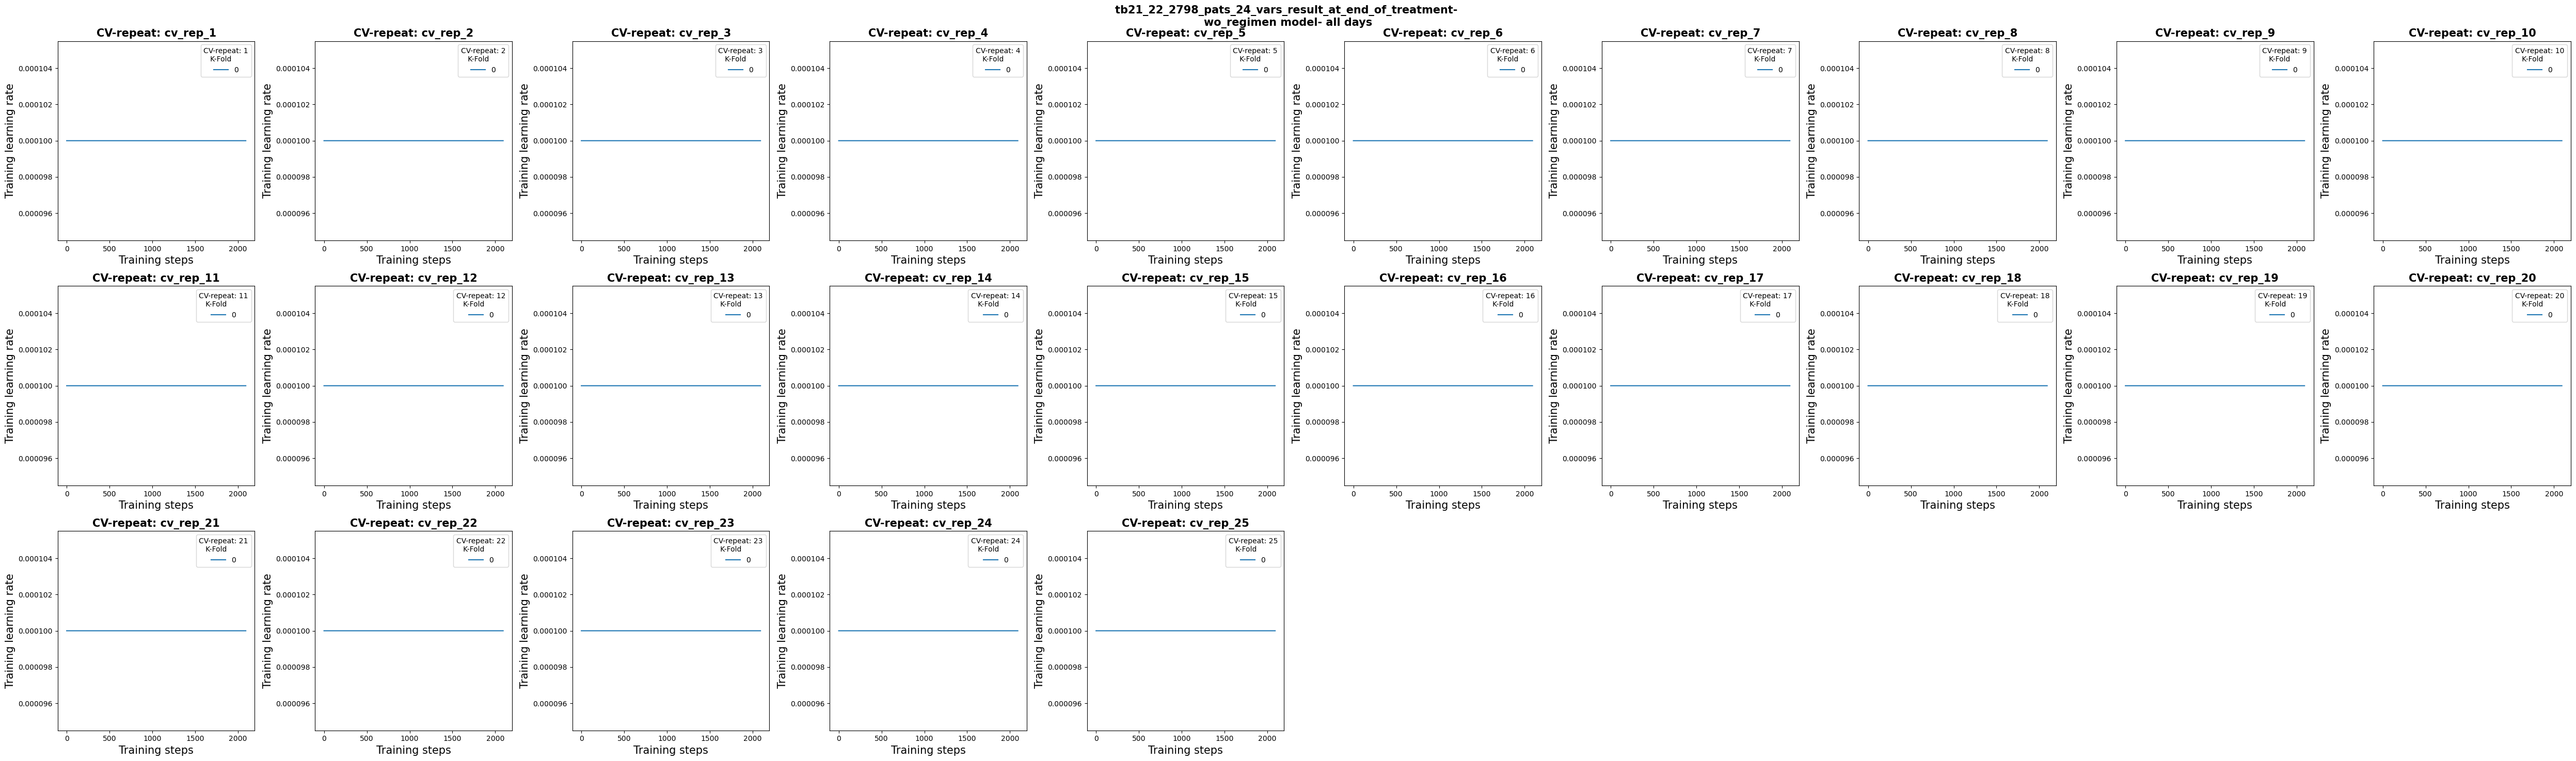

In [51]:
figtitle_size=30
subtitle_size=15
x_tick_size=31
y_tick_size=31
y_label_size=15
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']
for model_complex in model_complexities[2:3]:
    for data_param_key in [*parameters_for_analysis][-2:-1]:

        for period_end_day in period_end_days[-1:]:

            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)     
    
            ncols=10 #num_of_cv_repeats
            #nrows=len([*result_dict])
            nrows=int(np.ceil(num_of_cv_repeats/ncols))#len([*result_dict])
            
            fig=plt.figure(figsize=((ncols)*5,(nrows)*5))
            n=0


            training_data_results=result_dict['train_data_results']              


            for training_method in training_methods[:1]:
            
                melted_df_list=[]
                for cv_rep in [*training_data_results][0:]:          
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    n=n+1

                    
                    loss_dict=training_data_results[cv_rep]['training_learning_rate']

                    if len(loss_dict.keys())>0:
                        # Find the maximum length among the lists
                        max_length=max(len(lst) for lst in loss_dict.values())
                        # Pad the shorter lists with np.nan values
                        padded_loss_dict={key: lst + [np.nan]*(max_length - len(lst)) for key,lst in loss_dict.items()}
    
                        df=pd.DataFrame.from_dict(padded_loss_dict)
                        melted_df=pd.melt(df.reset_index(),id_vars='index',var_name='K-Fold',value_name='Training learning rate')
                        melted_df['CV-repeat']=cv_rep.split('_')[-1]

                    if len(loss_dict.keys())==0:
                        training_loss = training_data_results[cv_rep]['results']['training'][0][0]['training_learning_rate']
                        melted_df = pd.DataFrame({'Training learning rate':training_loss,
                                                 'K-Fold':[0,]*len(training_loss),
                                                 'CV-repeat':[cv_rep.split('_')[-1],]*len(training_loss)})
                        melted_df = melted_df.reset_index()
                        
                    plot_df=melted_df.copy()#pd.concat(melted_df_list,axis=0)
                    if 'no_CV' in cv_rep:
                        plot_df=plot_df.drop(columns=['K-Fold'])
                        sns.lineplot(data=plot_df,y='Training learning rate',x='index',ax=ax,marker='o',markersize=2)
                        ax_title='No CV'

                    if 'no_CV' not in cv_rep:
                        if num_of_cv_repeats==1:
                            sns.lineplot(data=plot_df,y='Training learning rate',x='index',hue='K-Fold',ax=ax,marker='o',markersize=2)
                            ax_title='CV-repeat: '+str(cv_rep) 

                        if num_of_cv_repeats>1:
                            sns.lineplot(data=plot_df,y='Training learning rate',x='index',hue='K-Fold',ax=ax)
                            handles, labels = ax.get_legend_handles_labels()
                            ax.legend(handles=handles, labels=labels, title=f"CV-repeat: " + str(cv_rep.split('_')[-1]) +'\n   K-Fold')
                            ax_title='CV-repeat: '+str(cv_rep)

                    ax.set_title(ax_title,fontsize=subtitle_size,fontweight='bold')
                    ax.set_ylabel('Training learning rate',fontsize=y_label_size)
                    ax.set_xlabel('Training steps',fontsize=y_label_size)
                    #ax.set_xlim(900,)
                    #ax.set_yscale('log')
                    

                    #fig.suptitle('- '.join([ds_name,model_complex+' model']),fontsize=15,fontweight='bold')    
                    fig.suptitle('- '.join([data_param_key,'\n'+model_complex+' model',str(period_end_day)+' days']),fontsize=15,fontweight='bold')  
 
plt.tight_layout() 

# DEPRECATED

## Plot CV results

#### ROC-AUC of all timepoints

dict_keys(['y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'x'])
dict_keys(['y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'x'])
dict_keys(['y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'x'])
dict_keys(['y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'x'])


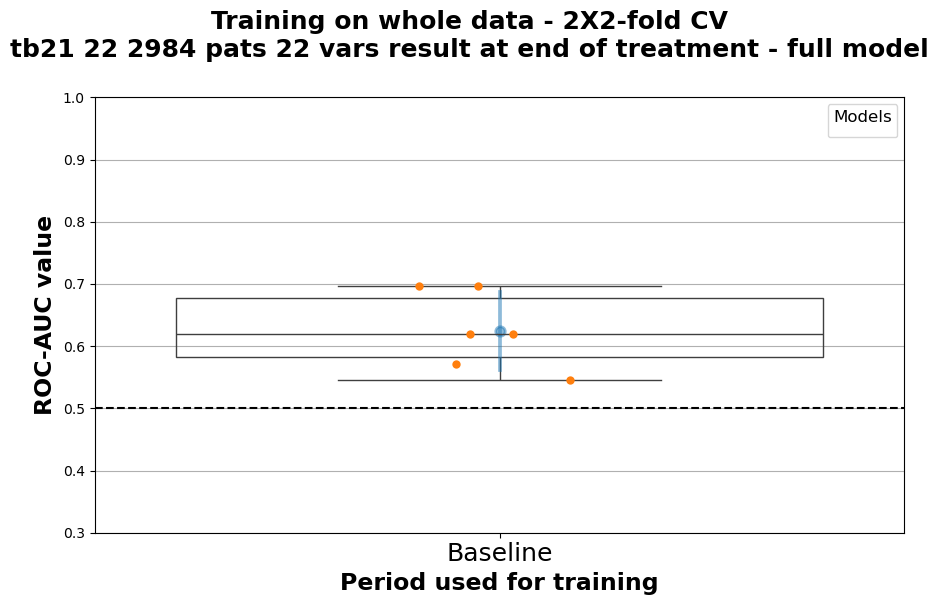

In [34]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
import matplotlib as mpl
from sklearn.metrics import roc_auc_score
import itertools

figtitle_size=20
subplot_title_size=16
#ylabel_size=12
y_label_size=15
text_size=18
legend_title_fontsize=13
scatter_dot_size=10
dot_size=7
x_tick_size=14
y_tick_size=14
figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


model_names=['LSTM']
#train_dataset_types=['raw','log']

color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase','USUBJID':'SubjectID'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


for model_complex in model_complexities[2:3]:
    
    for ds_name in [*parameters_for_analysis][:1]:

        df_list=[]
        for period_end_day in period_end_days[-1:]:
        
        
            #fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)
    
            
            for categorical_map_name in [*result_dict][:1]:
                #categorical_map=categorical_map_dict[categorical_map_name]
                #training_data_results=result_dict[categorical_map_name]['train_data_results']
                training_data_results=result_dict['train_data_results']
    
    
                for training_method in training_methods[:1]:  
    
                    if training_method=='training_on_first_x_days':
                        training_days=training_data_results['training_on_first_x_days']['training_days']
                    
                    cv_results={}
                    #for train_ds_type in train_dataset_types:
                    
                    roc_list,cv_rep_list,period_list=[],[],[]
    
                    #print(training_data_results.keys())[cv_rep]['results'].keys())
                    
                    for cv_rep in [*training_data_results]:
                        k_fold_results=training_data_results[cv_rep]['results']['validation']
                        
                        
                        n=0
                        
                        for k_fold in [*k_fold_results]:
                            print(k_fold_results[k_fold].keys())
    
                            model_name='LSTM'
                            model_name=''
                            actual_y=model_name+'y'
                            #y_train_name=model_name+'_y_with_index'
                            predicted_label=model_name+'predicted_label'
                            predicted_prob=model_name+'predicted_prob'
                            cross_entropy_weights_dict=model_name+'cross_entropy_weights_dict'
                            sample_weights=np.vectorize(k_fold_results[k_fold][cross_entropy_weights_dict].get)(k_fold_results[k_fold][predicted_label])
    
                            y_score  = list(itertools.chain(*[k_fold_results[k_fold][predicted_prob][n] for n in range(len(k_fold_results[k_fold][predicted_prob]))]))
                            auc_score=roc_auc_score(y_true=k_fold_results[k_fold][actual_y],
                                                    y_score=y_score,
                                                    sample_weight=sample_weights,
                                                    average='macro')
    
    
                            roc_list.append(round(auc_score,3))
                            cv_rep_list.append(cv_rep.split('_')[-1])
                            period_list.append(period_end_day)
        
                        cv_results['ROC_AUC_score']=roc_list
                        cv_results['CV-repeat']=cv_rep_list
                        cv_results['period_used_for_training']=period_list
        
                        df=pd.DataFrame.from_dict(cv_results)
                        #df['Training type']=train_ds_type + ' TTP'
                        df_list.append(df)
        
            ## Concatenate datqaframes of different training dataset types (i.e.raw TTP - log TTP)
            plot_df=pd.concat(df_list,axis=0)        
    
    
            metrics=['ROC_AUC_score'][0:]
            ncols=len(metrics)
            nrows=1
            fig=plt.figure(figsize=(nrows*9,ncols*6))
    
            for n,scoring_method in enumerate(metrics[0:]):
                ax=fig.add_subplot(nrows,ncols,n+1)
                sns.boxplot(data=plot_df,
                            y=scoring_method,
                            x='period_used_for_training',
                            ax=ax,boxprops={'facecolor':'none'})
                sns.stripplot(data=plot_df,
                              y=scoring_method,
                              x='period_used_for_training',
                              size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
                sns.pointplot(data=plot_df,
                              y=scoring_method,
                              x='period_used_for_training',
                              errorbar='sd',
                              alpha=0.5,dodge=True)
    
                ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
                
                ## Convert days to months for xticklabels
                xticklabels=[ 'Month 6' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                            else None 
                            for day in period_end_days]
            
                ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                ax.set_ylim(0.3,1) 
            
                # Adjust legend: changing font size and handle size
                h, l = ax.get_legend_handles_labels()
                legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                
                #ax.legend(h,l,frameon=True,framealpha=0.5,
                #                    prop={'weight':'bold','size':legend_fontsize})
                
                ## If no multiple CV repeats, then don't color by the CV-repeats column
                #if len(plot_df['CV-repeat'].unique())==1:
                #    sns.swarmplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,s=dot_size,dodge=False)
                #if len(plot_df['CV-repeat'].unique())>1:
                #    sns.swarmplot(data=plot_df,y=scoring_method,x='Training type',ax=ax,hue='CV-repeat',s=dot_size,dodge=False)
    
                #ax.set_ylabel(scoring_method.replace('_',' '),fontsize=y_label_size,fontweight='bold')
                #ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)
    
                #ax.set_ylim(0,1)
                #ax.set_yticks(np.linspace(0,ax.get_ylim()[1],11))
                #ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],11),2),fontsize=y_tick_size)
                #title=train_data_type.split('_train')[0]+' TTP values'
                #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
                #ax.set_xlabel('CV-repeat',fontsize=y_label_size)
                #ax.set_xlabel(None)
                ax.axhline(0.5,linestyle='--',color='black')
                ax.grid(axis='y',which='both')
                plt.tight_layout
    
        if training_method=='training_on_first_x_days':
            suptitle=training_method.replace('x',str(training_days))
            suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+'\n'+\
                        ds_name.replace('_',' ')+ ' - '+model_complex+' model'
                        
        else:
            suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+\
                        '\n'+ds_name.replace('_',' ') + ' - '+model_complex+' model'
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)        
       
    plt.tight_layout()

In [36]:
k_fold_results[1].keys()

dict_keys(['y', 'y_with_index', 'predicted_label', 'predicted_prob', 'cross_entropy_weights_dict', 'x'])

#### DEPRECATED - ROC-AUC of all timepoints

In [18]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
import matplotlib as mpl
from sklearn.metrics import roc_auc_score

figtitle_size=20
subplot_title_size=16
ylabel_size=12
text_size=18
legend_title_fontsize=13
scatter_dot_size=10
dot_size=7
x_tick_size=14
y_tick_size=14


model_names=['LSTM']
#train_dataset_types=['raw','log']

color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase','USUBJID':'SubjectID'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


for model_complex in model_complexities[2:3]:
    for ds_name in [*parameters_for_analysis][:1]:

        fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname):
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)

        print([*result_dict])
        
        for categorical_map_name in [*result_dict][:1]:
            #categorical_map=categorical_map_dict[categorical_map_name]
            training_data_results=result_dict[categorical_map_name]['train_data_results']

            df_list=[]
            for training_method in training_methods[:1]:  

                if training_method=='training_on_first_x_days':
                    training_days=training_data_results['training_on_first_x_days']['training_days']
                
                cv_results={}
                #for train_ds_type in train_dataset_types:
                
                roc_list,cv_rep_list=[],[]

                for cv_rep in [*training_data_results[training_method]]:
                    k_fold_results=training_data_results[training_method][cv_rep]['results']['validation']
                    
                    n=0
                    
                    for k_fold in [*k_fold_results]:
                        #print(k_fold_results[k_fold].keys())

                        model_name='LSTM'
                        actual_y=model_name+'_y'
                        #y_train_name=model_name+'_y_with_index'
                        predicted_label=model_name+'_predicted_label'
                        predicted_prob=model_name+'_predicted_prob'
                        cross_entropy_weights_dict=model_name+'_cross_entropy_weights_dict'
                        sample_weights=np.vectorize(k_fold_results[k_fold][cross_entropy_weights_dict].get)(k_fold_results[k_fold][predicted_label])


                        auc_score=roc_auc_score(y_true=k_fold_results[k_fold][actual_y],
                                                y_score=np.array(k_fold_results[k_fold][predicted_prob])[:,1],
                                                sample_weight=sample_weights,
                                                average='macro')


                        roc_list.append(round(auc_score,3))
                        cv_rep_list.append(cv_rep.split('_')[-1])

                cv_results['ROC_AUC_score']=roc_list
                cv_results['CV-repeat']=cv_rep_list

                df=pd.DataFrame.from_dict(cv_results)
                #df['Training type']=train_ds_type + ' TTP'
                df_list.append(df)

        ## Concatenate datqaframes of different training dataset types (i.e.raw TTP - log TTP)
        plot_df=pd.concat(df_list,axis=0)        


        metrics=['ROC_AUC_score'][0:]
        ncols=len(metrics)
        nrows=1
        fig=plt.figure(figsize=(nrows*4,ncols*6))

        for n,scoring_method in enumerate(metrics[0:]):
            ax=fig.add_subplot(nrows,ncols,n+1)
            sns.boxplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,boxprops={'facecolor':'none'})
            sns.swarmplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,s=dot_size,dodge=False)
            
            ## If no multiple CV repeats, then don't color by the CV-repeats column
            #if len(plot_df['CV-repeat'].unique())==1:
            #    sns.swarmplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,s=dot_size,dodge=False)
            #if len(plot_df['CV-repeat'].unique())>1:
            #    sns.swarmplot(data=plot_df,y=scoring_method,x='Training type',ax=ax,hue='CV-repeat',s=dot_size,dodge=False)

            ax.set_ylabel(scoring_method.replace('_',' '),fontsize=y_label_size,fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)

            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],11))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],11),2),fontsize=y_tick_size)
            #title=train_data_type.split('_train')[0]+' TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.set_xlabel('CV-repeat',fontsize=y_label_size)
            #ax.set_xlabel(None)
            ax.axhline(0.5,linestyle='--',color='black')
            ax.grid(axis='y',which='both')
            plt.tight_layout

    if training_method=='training_on_first_x_days':
        suptitle=training_method.replace('x',str(training_days))
        suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+'\n'+\
                    ds_name.replace('_',' ')+ ' - '+model_complex+' model'
                    
    else:
        suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+\
                    '\n'+ds_name.replace('_',' ') + ' - '+model_complex+' model'
    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)        
   
plt.tight_layout()

['test_data_results', 'cv_results', 'feat_importances', 'train_data_results', 'lstm_parameters']


KeyError: 'train_data_results'

#### ROC-AUC of per visit

In [ ]:
len(training_data_results['cv_rep_1']['cv_training_ids'])#.keys()#['results']['training'].keys()#[0].keys()#[training_method][cv_rep]['results'].keys()
#result_dict['train_data_results'].keys()

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import matplotlib as mpl
from sklearn.metrics import roc_auc_score
import itertools


figtitle_size=20
subtitle_size=18
x_tick_size=13
y_tick_size=13
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



model_names=['LSTM']
#train_dataset_types=['raw','log']
period_end_days_for_plot=period_end_days[:]

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}


color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase','USUBJID':'SubjectID'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


for model_complex in model_complexities[2:3]:
    for data_param_key in [*parameters_for_analysis][:1]:

        outcome_label=data_param_key.split('vars_')[-1].upper()

        l_all,l_study,l_arm=[],[],[]

        ncols=1 #len([*training_data_results[training_method]])
        nrows=1
        fig,ax=plt.subplots(1,1,figsize=(ncols*10,nrows*4))
        
        for period_end_day in period_end_days[:]:

            #fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)
        

            training_data_results=result_dict['train_data_results']

                
            cv_results={}
            #for train_ds_type in train_dataset_types:
            
            df_list,cv_rep_list=[],[]
            

            roc_scores_all_cv_list,roc_scores_study_cv_list,roc_scores_arm_cv_list=[],[],[]
            
            for cv_rep in [*training_data_results]:
                cv_results[cv_rep.split('_')[-1]]={}
                k_fold_results=training_data_results[cv_rep]['results']['validation']
                roc_list,visit_list=[],[]
                n=0

                roc_scores_all_list,roc_scores_study_list,roc_scores_arm_list=[],[],[]
                
                for k_fold in [*k_fold_results]:
                    #print(k_fold_results[k_fold].keys())

                    model_name='LSTM'
                    actual_y='y'
                    actual_y_with_index='y_with_index'
                    predicted_label='predicted_label'
                    predicted_prob='predicted_prob'
                    cross_entropy_weights_dict='cross_entropy_weights_dict'
                    x_test_name='x'
                    sample_weights=np.vectorize(k_fold_results[k_fold][cross_entropy_weights_dict].get)(k_fold_results[k_fold][predicted_label])


                    predicted_prob=list(chain(*training_data_results[cv_rep]['results']['training'][k_fold]['predicted_prob']))
                    y_with_index=training_data_results[cv_rep]['results']['training'][k_fold]['y_with_index']

                    x_for_test=training_data_results[cv_rep]['results']['training'][k_fold]['x']
                    train_ids=x_for_test['USUBJID'].drop_duplicates()
                    y_with_index_=y_with_index.reset_index().set_index('USUBJID')

                    
                    y_with_index_=y_with_index_.loc[train_ids,:]
                    y_with_index_['predicted_prob']=predicted_prob


                    roc_scores_all = roc_auc_score(y_with_index_[outcome_label].values,y_with_index_['predicted_prob'].values)
                    roc_scores_study = y_with_index_.groupby('STUDYID').apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values)).to_frame()    
                    roc_scores_arm = y_with_index_.groupby(['ARM','STUDYID']).apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values)).to_frame()

                    
                    roc_scores_study['CV_rep']=cv_rep 
                    roc_scores_arm['CV_rep']=cv_rep 

                    #print(roc_scores_study)

                    roc_scores_all_list.append(roc_scores_all)
                    roc_scores_study_list.append(roc_scores_study)
                    roc_scores_arm_list.append(roc_scores_arm)

                
                roc_df_all_cv=pd.DataFrame(data=roc_scores_all_list,columns=['ROC_AUC_score'])
                roc_df_all_cv['CV_rep']=cv_rep
                
                roc_df_study_cv=pd.concat(roc_scores_study_list,axis=0)
                roc_df_study_arm=pd.concat(roc_scores_arm_list,axis=0)

                roc_scores_all_cv_list.append(roc_df_all_cv)
                roc_scores_study_cv_list.append(roc_df_study_cv)
                roc_scores_arm_cv_list.append(roc_df_study_arm)

            roc_all_df=pd.concat(roc_scores_all_cv_list,axis=0)
            roc_study_df=pd.concat(roc_scores_study_cv_list,axis=0)
            roc_arm_df=pd.concat(roc_scores_arm_cv_list,axis=0)

            for df in [roc_all_df,roc_study_df,roc_arm_df]:
                df['inclusion_period']=period_end_day

            l_all.append(roc_all_df)
            l_study.append(roc_study_df)
            l_arm.append(roc_arm_df)

        ## Collect all the ROC-AUC values into dataframes (calucalted over all samples, per study, per arm)
        plot_df=pd.concat(l_all,axis=0)
        plot_df_study=pd.concat(l_study,axis=0)
        plot_df_arm=pd.concat(l_arm,axis=0)

        plot_df['model_name']='LSTM'
        
        ## Plot ROC-AUC calculated over all samples
        sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                  errorbar='sd',alpha=0.5)

        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days_for_plot]
        ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})

        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            #train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: all visits in period\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  


       


        ### =======  PLOT PER-STUDY ROC-AUC VALUES IF MULTIPLE STUDIES WERE IN TRAINING DATASET ======= #####
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLO
        scores_per_study_list=plot_df_study.reset_index()['STUDYID'].unique()
        
        if len(scores_per_study_list)>0:# and plot_split_by_studies==True:

            cv_res_per_study_df=plot_df_study.reset_index().rename(columns={0:'ROC_AUC_score'})
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                plot_df['model_name']='LSTM'

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('inclusion_period')['ROC_AUC_score'].median().reset_index()

                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''

                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.3,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  


        ### =======  PLOT PER-STUDY ROC-AUC VALUES IF MULTIPLE STUDIES WERE IN TRAINING DATASET ======= #####
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0:# and plot_split_by_studies==True:

            cv_res_per_arm_df=plot_df_arm.reset_index().rename(columns={0:'ROC_AUC_score'})
            ncols=2
            num_of_arms=len(cv_res_per_arm_df['ARM'].unique())
            nrows=int(np.ceil(num_of_arms/ncols))
            fig3=plt.figure(figsize=(ncols*10,nrows*5))

            for n,arm in enumerate(cv_res_per_arm_df['ARM'].unique()):
                ax3=fig3.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_arm_df[cv_res_per_arm_df['ARM']==arm]
                plot_df['model_name']='LSTM'

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('inclusion_period')['ROC_AUC_score'].median().reset_index()

                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax3,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''

                studyid=plot_df['STUDYID'].unique()[0]
                ax3.set_title(f'{studyid} -{arm}',fontweight='bold')
                ax3.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax3.set_xlabel(None)
                ax3.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax3.set_ylim(0.3,1) 

                # increase tick width
                ax3.tick_params(width=axis_lw)
                ax3.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax3.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax3.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax3.get_legend_handles_labels()
                legend = ax3.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax3.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig3.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  


In [ ]:
cv_res_per_arm_df
#plot_df_study.reset_index().rename(columns={0:'ROC_AUC_score'})
#roc_arm_df
#roc_df_study_arm
#y_with_index_.groupby('ARM').apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values))
#len(predicted_prob)

#x_for_test['USUBJID'].drop_duplicates()#.unique().shape
#len(train_ids)

### Plot results of training data

In [ ]:
figtitle_size=30
#subtitle_size=20
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for ds_name in [*parameters_for_analysis][:1]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:]:
        train_data_results=result_dict[categorical_map_name]['train_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        for training_method in training_methods[:1]:
            
            plot_dict={key: value for key, value in train_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            
            pred_df=pd.DataFrame.from_dict(plot_dict)

            fig,axes=plt.subplots(1,1,figsize=(len(model_names)*6,8))
            ax=axes
            plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
            model_name_list,metric_name_list,metric_value_list=[],[],[]
            for model_name in model_names:
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'
                print(pred_df[actual_y].value_counts(normalize=False))
                        
                for scoring_method in scoring_methods:
                    scorer=scoring_methods_dict[scoring_method]
                    score_metric_value=scorer(pred_df[actual_y], pred_df[predicted], average='macro')
                    model_name_list.append(model_name)
                    metric_name_list.append(scoring_method)
                    metric_value_list.append(score_metric_value)
                
            plot_df['model_name']=model_name_list
            plot_df['metric_name']=metric_name_list
            plot_df['metric_value']=metric_value_list

            ylim=1.1*(plot_df['metric_value'].max())
            plot_df=plot_df.replace({'RandomForest':'Random\nForest',
                                        'GradientBoost':'Gradient\nBoost',
                                        'LogisticRegression':'Logistic\nRegression',
                                        'DenseNetwork':'Dense\nNetwork',
                                        'ElasticNet':'Elastic\nNet'},regex=True)

            sns.barplot(data=plot_df,x='model_name',y='metric_value',hue='metric_name',ax=ax)
            # Iterate over each bar
            for p in ax.patches:
                # Get the height of the bar
                height = p.get_height()
                
                # Add the y-value on top of the bar
                ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom',fontsize=bar_annot_fontsize)

            ax.set_ylabel('Scoring method value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)
            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],5))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],5),2),fontsize=y_tick_size)
            title='TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.grid(axis='y')
            plt.tight_layout

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)
            #print(weighted_f1)

'''
        
'''                

### Plot confusion matrices of training data

In [ ]:
## Set the figtitle sizes  -> the other fontsizes can be found lower in the code 
figtitle_size=10
subtitle_size=8

from sklearn import metrics

model_names=['LSTM']

categorical_map_dict={'2_categories':{'bins':[-1,42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,1]},
                      '7_categories':{'bins':[-1,1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,1]}}


for model_complex in model_complexities[0:1]:
    for ds_name in [*parameters_for_analysis][0:1]:

        fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname):
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)   
           

        for categorical_map_name in [*result_dict][:]:
            categorical_map=categorical_map_dict[categorical_map_name]
            train_data_results=result_dict[categorical_map_name]['train_data_results']          

                
            for training_method in training_methods[:1]:
                plot_dict={key: value for key, value in train_data_results[training_method].items() \
                            if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
                
                pred_df=pd.DataFrame.from_dict(plot_dict)


                plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
                model_name_list,metric_name_list,metric_value_list=[],[],[]
                
                
                if '2' in categorical_map_name:
                    row_width_fact=7
                    col_height_fact=1.5
                    num_col=2
                    hspace=0
                    wspace=0.2
                    y_label_size=10
                    bar_annot_fontsize=10
                    x_tick_size=8
                    y_tick_size=8
                    num_row=math.ceil(len(model_names)/num_col)
                    fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                    fig.subplots_adjust(hspace=hspace,wspace=wspace)

                else:  
                    row_width_fact=11
                    col_height_fact=2.5
                    num_col=2
                    hspace=0.2
                    wspace=0.1
                    y_label_size=10
                    bar_annot_fontsize=8
                    x_tick_size=7
                    y_tick_size=7
                    num_row=math.ceil(len(model_names)/num_col)
                    fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                    fig.subplots_adjust(hspace=hspace,wspace=wspace)
                    #plt.tight_layout() 
                
                

                #fig,axes=plt.subplots(num_col,math.ceil(len(model_names)/num_col),figsize=(len(model_names)*5,6))
                #for ax,model_name in zip(axes.flatten(),model_names):

                for n,model_name in enumerate(model_names):
                    actual_y=model_name+'_y'
                    predicted=model_name+'_predicted'

                    confusion_matrix=pd.crosstab(pred_df[actual_y], pred_df[predicted], 
                                                rownames=['Actual'], colnames=['Predicted'],margins=True)
                    
                    ## Convert to dataframe and rename columns to label strings from numbers
                    confusion_matrix_=metrics.confusion_matrix(pred_df[actual_y], pred_df[predicted],normalize='true')
                    confusion_matrix_=pd.DataFrame(confusion_matrix_)
                    label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                        categorical_map_dict[categorical_map_name]['labels_str']))

                    confusion_matrix_=confusion_matrix_.rename(columns=label_dict)
                    confusion_matrix_=confusion_matrix_.rename(index=label_dict)

                    ax=fig.add_subplot(num_row,num_col,n+1)
                    sns.heatmap(confusion_matrix_*100,ax=ax,annot=True,cbar=False, cmap='viridis', fmt='.2f',
                                annot_kws={"size":bar_annot_fontsize})
                    
                    ax.set_title(model_name,fontsize=subtitle_size,fontweight='bold')
                    ax.set_ylabel('True label',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel('Predicted label',fontsize=y_label_size,fontweight='bold')
                    ax.set_xticklabels(ax.get_xticklabels(), fontsize=x_tick_size)
                    ax.set_yticklabels(ax.get_yticklabels(), fontsize=y_tick_size)

                ## Add th distri ution of the predicted variable as last subplot
                ax=fig.add_subplot(num_row,num_col,n+2)
                categorical_map_name_key=list(set(['LSTM_y_with_index' for key in \
                                            train_data_results[training_method].keys() if '_y_with_index' in key]))[0] 
                
                plot_df=train_data_results[training_method][categorical_map_name_key]
                plot_df=plot_df.reset_index()
                #plot_df=plot_df.rename(columns=color_by_legend_title)

                label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                        categorical_map_dict[categorical_map_name]['labels_str']))

                plot_df['mb_Time to Detection_RESULT']=plot_df['mb_Time to Detection_RESULT'].replace(label_dict,regex=True)
                if '2' in categorical_map_name:
                    plot_df['mb_Time to Detection_RESULT']=pd.Categorical(plot_df['mb_Time to Detection_RESULT'],['negative','positive'])
                    bar_offset_fact=0.1
                else:
                    bar_offset_fact=0.05  
                histp=sns.histplot(data=plot_df,y='mb_Time to Detection_RESULT',ax=ax,#hue=color_by_legend_title[color_by],
                            alpha=0.4,kde=False,linewidth=None)

                
                # Add count annotations next to the bars
                for p in histp.patches:
                    histp.annotate(f'{int(p.get_width())}', (p.get_width()+ax.get_xlim()[1]*bar_offset_fact, p.get_y()+p.get_height() / 2), 
                                    ha='center', va='center',fontsize=bar_annot_fontsize)

                # Remove x-label ticks on the x-axis
                ax.set_xticks([])                       
                ax.set_xlim(0,int(round(plot_df['mb_Time to Detection_RESULT'].value_counts().max()*1.2)))
                ax.set_xlabel('True labels',fontsize=y_label_size,fontweight='bold')
                #ax.set_ylabel('Count',fontsize=ylabel_size,fontweight='bold')
                # Remove y-axis ticks and labels

                # Set y-axis tick positions and labels
                ax.set_ylabel('') 
                ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                
                for label in ax.get_yticklabels():
                    label.set_rotation(90)
                    label.set_va('center')
                #ax.set_title('Label distribution',fontsize=y_label_size,fontweight='bold')
                
                # Remove the frame (border) around the plot
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['left'].set_visible(False)

                if training_method=='training_on_first_x_days':
                        suptitle=training_method.replace('x',str(training_days))
                        suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                                ds_name.replace('_',' ') + ' - '+ categorical_map_name
                                
                else:
                    suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1) 

### UMAP of training data with prediction error 

In [ ]:
import umap

figtitle_size=20
subtitle_size=15
x_tick_size=31
y_tick_size=31
y_label_size=15
bar_annot_fontsize=15
dot_size=6

## Load pat IDS with information which study phase they belong to
pat_id_df=pd.read_csv('../data/patients_in_analysis.csv',index_col=0)

temporal_data_names=['ae_','cmind_','cmdos_','cmday_','mh']

model_names=['LSTM']

train_dataset_types=['raw','log']
#train_dataset_types=['log']
training_methods=['training_on_whole_data']
data_split_random_state=44

color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


## Dictionary for the conversion of TTP values to labels
categorical_map_dict={'2_categories':{'bins':[float('-inf'),42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,2]},
                      '6_categories':{'bins':[float('-inf'),1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,2]}}

for ds_name in [*parameters_for_analysis][1:2]:
#for ds_name in [[*parameters_for_analysis][i] for i in (2,5,12)]:
    
    ## Load the preprocessed + imputed dataset
    data=pd.read_csv('../data/'+ds_name+'_preproc_data.csv',index_col=0,low_memory=False)  

    training_days=parameters_for_analysis[ds_name]['training_days']
    fname='../data/'+ds_name+'_LSTM_regr_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)
    

    training_data_results=result_dict[ds_name]['train_data_results']
    #test_data_results=result_dict[ds_name]['test_data_results']
    #training_days=training_data_results['training_on_first_x_days']['training_days']

    
    for training_method in training_methods[:1]:
        
        for categorical_map_name in [*categorical_map_dict][:1]:    

            ## Extract predicted and actual values saved during training and create a dataframe out of them
            plot_dict={key: value for key, value in training_data_results[training_method].items() \
                    if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            pred_df=pd.DataFrame.from_dict(plot_dict)

            ## Check if data is min-max standardised -> revert standardisation 
            if pred_df['LSTM_raw_y'].values.max()<=1:
                min_val=0
                max_value=1/(24*3600)+42
                for ds_type,max_val in zip(train_dataset_types,[max_value,np.log10(max_value)]):
                    pred_df.loc[:,pred_df.columns.str.contains(ds_type)]=max_value * pred_df.loc[:,pred_df.columns.str.contains(ds_type)]

            ## If no min-max standardisation convert only log values back
            elif pred_df['LSTM_raw_y'].values.max()>1:
                pred_df.loc[:,pred_df.columns.str.contains('log_')]=10**pred_df.loc[:,pred_df.columns.str.contains('log_')]

            ## Convert numerical TTP values to categorical labels
            categorical_map=categorical_map_dict[categorical_map_name]
            pred_df_cat=pred_df.apply(pd.cut,bins=categorical_map['bins'],labels=categorical_map['labels'])
            
            ## PLotting parameters
            num_col=1
            num_row=len(train_ds_type)
            row_width_fact=3
            col_height_fact=15
            #fig=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            #fig2=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            #fig3=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            
            for n,train_ds_type in enumerate(train_dataset_types):
                actual_y='_'.join(['LSTM',train_ds_type,'y'])
                predicted='_'.join(['LSTM',train_ds_type,'predicted'])
                x_train='_'.join(['LSTM',train_ds_type,'x'])

                # Add new column with information about the result of prediction (FN,FP,TN,TP)
                pred_df_cat[train_ds_type+'_result']=np.where((pred_df_cat[actual_y]==0)&(pred_df_cat[predicted]==0),'TN',
                                                        np.where((pred_df_cat[actual_y]==1)&(pred_df_cat[predicted]==1),'TP',
                                                        np.where((pred_df_cat[actual_y]==1)&(pred_df_cat[predicted]==0),'FN',
                                                        np.where((pred_df_cat[actual_y]==0)&(pred_df_cat[predicted]==1),'FP', 'unknown'))))

                ## Add columns of pred_df_cat to the y_with_index
                model_name='LSTM_'+train_ds_type
                actual_y_with_index=model_name+'_y_with_index'
                y_with_index=training_data_results[training_method][actual_y_with_index]
                y_with_index[pred_df_cat.columns.tolist()]=pred_df_cat.values
                y_res_df=y_with_index.reset_index()
            
                X_train=training_data_results[training_method][x_train]

                ## Check for patients whose timepoints were all predicted correctly
                result_check=y_res_df.groupby('USUBJID')[train_ds_type+'_result'].apply(lambda x: all(x.isin(['TP', 'TN'])))
                pats_with_corr_preds=result_check[result_check].index

                ## Extract percentage of correctly predicted TTp values for each patient
                #  i.e. 7 TTPs are TP/TN out of 10 TTP -> percentage=7/10
                corr_pred_perc=y_res_df.groupby('USUBJID')[train_ds_type+'_result'].apply(lambda x: len(x[x.isin(['TP', 'TN'])])/len(x))

                '''
                ## Plot TTP values of patients whose TTP values were ALL correctly predicted 
                ax=fig.add_subplot(num_row,num_col,n+1)
                sns.lineplot(data=y_res_df[y_res_df['USUBJID'].isin(pats_with_corr_preds)],x='DAY',
                             y='mb_Time to Detection_STD_NUM_RESULT',hue='USUBJID',ax=ax,marker='o')
                #ax.set_title(train_ds_type+' TTP values')      
                ax.set_ylabel(train_ds_type+' TTP values',fontsize=y_label_size)     
                ax.set_xlabel('Study day',fontsize=y_label_size)  
                ax.get_legend().remove()    


                ## Plot TTP values of patients where at least one visit's TTP was incorrectly predicted 
                ax2=fig2.add_subplot(num_row,num_col,n+1) 
                sns.lineplot(data=y_res_df[~y_res_df['USUBJID'].isin(pats_with_corr_preds)],x='DAY',
                             y='mb_Time to Detection_STD_NUM_RESULT',hue='USUBJID',ax=ax2,marker='o')
                #ax.set_title(train_ds_type+' TTP values')      
                ax2.set_ylabel(train_ds_type+' TTP values',fontsize=y_label_size)     
                ax2.set_xlabel('Study day',fontsize=y_label_size)  
                ax2.get_legend().remove()
                
                '''
                ### PLOT UMAPS OF TRAINING DATA ### 

                ## Extract variables from X_train_slid_wind in order to plot UMAP
                #  If not raise error to create them    
                if training_method=='training_on_first_x_days':
                    fn_x='_'.join([ds_name,str(training_days),'train_days','LSTM_slid_window_X_train_data'])+'.csv.gz'
                    
                if training_method=='training_on_whole_data':
                    fn_x='_'.join([ds_name,'whole_data','LSTM_slid_window_X_train_data'])+'.csv.gz'
            
                fname_x=os.path.join('../data',fn_x)
                X_train_slid_wind=pd.read_csv(fname_x,index_col=0,nrows=0,low_memory=False)
                X_train_=X_train.loc[:,X_train.columns.isin(X_train_slid_wind.columns)]
                X_train_=X_train_.loc[:,~X_train_.columns.str.startswith(tuple(temporal_data_names))]


                ## Perform UMAP dimensionality reduction
                umap_reducer=umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
                umap_result=umap_reducer.fit_transform(X_train_.drop(columns=['USUBJID']))
                y_res_df[['UMAP1', 'UMAP2']]=umap_result


                ## Add columns indicating points of patients with all correct predictions
                y_res_df['all_pred_correct']=np.nan
                y_res_df.loc[y_res_df['USUBJID'].isin(pats_with_corr_preds),'all_pred_correct']='yes'
                y_res_df.loc[~y_res_df['USUBJID'].isin(pats_with_corr_preds),'all_pred_correct']='no'

                ## Add percentage of correctly predicted TTP values per patient as a new column
                d=pd.Series(corr_pred_perc.values,index=corr_pred_perc.index).to_dict()
                y_res_df[train_ds_type+ '_correct_pred_perc']=y_res_df.loc[:,'USUBJID'].map(d)

                ## Add error of TTP prediction as a column
                y_predicted=training_data_results[training_method][predicted]
                y_res_df[train_ds_type+'_predicted']=y_predicted
                y_res_df[train_ds_type+'_abs_pred_error']=abs(y_res_df['mb_Time to Detection_STD_NUM_RESULT']-y_res_df[train_ds_type+'_predicted'])

                ## Rename some columns for better readability
                y_res_df[train_ds_type+' TTP']=y_res_df['mb_Time to Detection_STD_NUM_RESULT']
                y_res_df['log Study Day']=np.log10(y_res_df['DAY'])


                
                ## PLOT UMAP COLORED BY PREDICTION RESULTS
                vars_for_coloring=['all_pred_correct',train_ds_type+'_result',train_ds_type+'_correct_pred_perc',
                                    train_ds_type+'_abs_pred_error']

                num_col=2
                num_row=math.ceil(len(vars_for_coloring)/num_col)
                row_width_fact=8
                col_height_fact=6
                #fig3,ax3=plt.subplots(num_row,num_col,figsize=(num_row*row_width_fact,num_col*col_height_fact))
                fig3=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
                
                for l,var in enumerate(vars_for_coloring[:]):
                    ax3=fig3.add_subplot(num_row,num_col,l+1) 
                    sns.scatterplot(data=y_res_df,x='UMAP1', y='UMAP2',hue=var,ax=ax3,s=dot_size)
                    ax3.set_title(var+' UMAP',fontsize=subtitle_size) 
                
        

                if training_method=='training_on_first_x_days':
                    suptitle=ds_name.replace('_',' ')+'\n'+training_method_fig_title[training_method] +\
                            ' '+ str(training_days)+' - Predicting TTP on days '+str(prediction_duration[0])+ ' - '+str(prediction_duration[-1]) 
                            
                else:
                    suptitle=ds_name.replace('_',' ')+'\n '+ 'Patients with only correct predictions'     
                    suptitle2=ds_name.replace('_',' ')+'\n '+ 'Patients with incorrent predcictions' 
                    suptitle3=ds_name.replace('_',' ')+'\n '+ 'Training data UMAP'                                     
                    
                
                #fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.98)
                #fig2.suptitle(suptitle2,fontsize=figtitle_size,fontweight='bold',y=0.98)
                fig3.suptitle(suptitle3,fontsize=figtitle_size,fontweight='bold',y=0.98)          
                

            ## PLOT UMAP COLORED BY OTHER VARIABLES
            num_col=2
            num_row=math.ceil(len(train_dataset_types)/num_col)
            row_width_fact=14
            col_height_fact=3

            vars_for_coloring=['DAY',train_ds_type+' TTP']

            fig4=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            for l,var in enumerate(vars_for_coloring[:]):
                ax4=fig4.add_subplot(num_row,num_col,l+1) 
                sns.scatterplot(data=y_res_df,x='UMAP1', y='UMAP2',hue=var,ax=ax4,s=dot_size)
                ax4.set_title(var+' UMAP')   

            suptitle4=ds_name.replace('_',' ')
            fig4.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.98)

plt.tight_layout() 


            
                

## Testing

#### ROC-AUC of all timepoints

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
import matplotlib as mpl
from sklearn.metrics import roc_auc_score
import itertools
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

figtitle_size=20
subplot_title_size=16
#ylabel_size=12
y_label_size=15
text_size=18
legend_title_fontsize=13
scatter_dot_size=10
dot_size=7
x_tick_size=14
y_tick_size=14
figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


model_names=['LSTM']
#train_dataset_types=['raw','log']


suptitle_dict={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB+ OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB+ OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMoxTB'}


for model_complex in model_complexities[2:3]:
    
    for data_param_key in [*parameters_for_analysis][:2]:

        df_list=[]
        for period_end_day in period_end_days[:]:
        
        
            #fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_training_results.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)
    
            
            for categorical_map_name in [*result_dict][:1]:
                #categorical_map=categorical_map_dict[categorical_map_name]
                #training_data_results=result_dict[categorical_map_name]['train_data_results']
                test_data_results=result_dict['test_data_results']
    
    
                #for training_method in training_methods[:1]:  
    
                #if training_method=='training_on_first_x_days':
                #    training_days=training_data_results['training_on_first_x_days']['training_days']
                
                cv_results={}
                #for train_ds_type in train_dataset_types:
                
                roc_list,cv_rep_list,period_list=[],[],[]

                #print(training_data_results.keys())[cv_rep]['results'].keys())
                
                for cv_rep in [*test_data_results]:
                    k_fold_results=test_data_results[cv_rep]['results'][0]
                    
                    
                    n=0
                    
                    #for k_fold in [*k_fold_results]:
                        #print(k_fold_results[k_fold].keys())
                    '''
                    model_name='LSTM'
                    model_name=''
                    actual_y=model_name+'y'
                    #y_train_name=model_name+'_y_with_index'
                    predicted_label=model_name+'predicted_label'
                    predicted_prob=model_name+'predicted_prob'
                    cross_entropy_weights_dict=model_name+'cross_entropy_weights_dict'
                    sample_weights=np.vectorize(k_fold_results[cross_entropy_weights_dict].get)(k_fold_results[predicted_label])

                    y_score  = list(itertools.chain(*[k_fold_results[predicted_prob][n] for n in range(len(k_fold_results[predicted_prob]))]))
                    auc_score=roc_auc_score(y_true=k_fold_results[actual_y],
                                            y_score=y_score,
                                            sample_weight=sample_weights,
                                            average='macro')
                    '''
                    auc_score =  k_fold_results['roc_auc']


                    roc_list.append(round(auc_score,3))
                    cv_rep_list.append(cv_rep.split('_')[-1])
                    period_list.append(period_end_day)

                cv_results['ROC_AUC_score']=roc_list
                cv_results['CV-repeat']=cv_rep_list
                cv_results['period_used_for_training']=period_list

                df=pd.DataFrame.from_dict(cv_results)
                #df['Training type']=train_ds_type + ' TTP'
                df_list.append(df)
    
        ## Concatenate datqaframes of different training dataset types (i.e.raw TTP - log TTP)
        plot_df=pd.concat(df_list,axis=0)        


        metrics=['ROC_AUC_score'][0:]
        ncols=len(metrics)
        nrows=1
        fig=plt.figure(figsize=(nrows*8,ncols*4))

        for n,scoring_method in enumerate(metrics[0:]):
            ax=fig.add_subplot(nrows,ncols,n+1)
            sns.boxplot(data=plot_df,
                        y=scoring_method,
                        x='period_used_for_training',
                        legend=False,
                        ax=ax,boxprops={'facecolor':'none'})
            sns.stripplot(data=plot_df,
                          y=scoring_method,
                          color='orange',
                          x='period_used_for_training',
                          size=6, jitter=0.1, alpha=1, dodge=True,legend=True)
            sns.pointplot(data=plot_df,
                          y=scoring_method,
                          x='period_used_for_training',
                          legend=False,
                          color='orange',
                          errorbar='sd',
                          alpha=0.5,dodge=True)

            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
            
            ## Convert days to months for xticklabels
            xticklabels=[ 'Month 6' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                            else None 
                            for day in period_end_days]
        
            ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.3,1) 
        
            # Adjust legend: changing font size and handle size
            #h, l = ax.get_legend_handles_labels()
            #legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

            legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                    for l, c in zip(['LSTM'],['orange'])]
            
            ax.legend(handles=legend_handles, 
                      frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})




            
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)

            ax.yaxis.grid(True) 
        
            #plt.tight_layout
    
            if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
            
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
    
                
                train_ds_type='Baseline vars - all visits in period'
                #print('train_ds_type',train_ds_type)
                train_ds_type=train_ds_type.replace(' ',r'\ ')
                train_ds_type = rf"$\bf{{{train_ds_type}}}$"
    
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
                suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names} "
          
            else:   
                suptitle=f"ROC-AUC of CV - {data_param_key}" 
                
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)        
   
#plt.tight_layout()

In [32]:
h

[]

### Plot results of testing data

In [ ]:
figtitle_size=30
#subtitle_size=20
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for ds_name in [*parameters_for_analysis][:3]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:1]:
        test_data_results=result_dict[categorical_map_name]['test_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        for training_method in training_methods[:1]:
            
            plot_dict={key: value for key, value in test_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_X','_model','training_loss_dict'])}
            print(plot_dict.keys())
            pred_df=pd.DataFrame.from_dict(plot_dict)

            fig,axes=plt.subplots(1,1,figsize=(len(model_names)*6,8))
            ax=axes
            plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
            model_name_list,metric_name_list,metric_value_list=[],[],[]
            for model_name in model_names:
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'
                print(pred_df[actual_y].value_counts(normalize=False))
                        
                for scoring_method in scoring_methods:
                    scorer=scoring_methods_dict[scoring_method]
                    score_metric_value=scorer(pred_df[actual_y], pred_df[predicted], average='macro')
                    model_name_list.append(model_name)
                    metric_name_list.append(scoring_method)
                    metric_value_list.append(score_metric_value)
                
            plot_df['model_name']=model_name_list
            plot_df['metric_name']=metric_name_list
            plot_df['metric_value']=metric_value_list

            ylim=1.1*(plot_df['metric_value'].max())
            plot_df=plot_df.replace({'RandomForest':'Random\nForest',
                                        'GradientBoost':'Gradient\nBoost',
                                        'LogisticRegression':'Logistic\nRegression',
                                        'DenseNetwork':'Dense\nNetwork',
                                        'ElasticNet':'Elastic\nNet'},regex=True)

            sns.barplot(data=plot_df,x='model_name',y='metric_value',hue='metric_name',ax=ax)
            # Iterate over each bar
            for p in ax.patches:
                # Get the height of the bar
                height = p.get_height()
                
                # Add the y-value on top of the bar
                ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom',fontsize=bar_annot_fontsize)

            ax.set_ylabel('Scoring method value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)
            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],5))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],5),2),fontsize=y_tick_size)
            title='TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.grid(axis='y')
            plt.tight_layout

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)
            #print(weighted_f1)

'''
        
'''                

### Plot confusion matrices of testing data

In [ ]:
## Set the figtitle sizes  -> the other fontsizes can be found lower in the code 
figtitle_size=10
subtitle_size=8


from sklearn import metrics

model_names=['LSTM']

categorical_map_dict={'2_categories':{'bins':[-1,42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,1]},
                      '7_categories':{'bins':[-1,1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,1]}}

for ds_name in [*parameters_for_analysis][1:2]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:]:
        test_data_results=result_dict[categorical_map_name]['test_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        
        for training_method in training_methods[:1]:
            print(test_data_results[training_method].keys())
            plot_dict={key: value for key, value in test_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            
            pred_df=pd.DataFrame.from_dict(plot_dict)
            
            if '2' in categorical_map_name:
                row_width_fact=7
                col_height_fact=1.5
                num_col=2
                hspace=0
                wspace=0.2
                y_label_size=10
                bar_annot_fontsize=10
                x_tick_size=8
                y_tick_size=8
                num_row=math.ceil(len(model_names)/num_col)
                fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                fig.subplots_adjust(hspace=hspace,wspace=wspace)

            else:  
                row_width_fact=11
                col_height_fact=2.5
                num_col=2
                hspace=0.2
                wspace=0.1
                y_label_size=10
                bar_annot_fontsize=8
                x_tick_size=7
                y_tick_size=7
                num_row=math.ceil(len(model_names)/num_col)
                fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                fig.subplots_adjust(hspace=hspace,wspace=wspace)
                #plt.tight_layout() 
            
            

            #fig,axes=plt.subplots(num_col,math.ceil(len(model_names)/num_col),figsize=(len(model_names)*5,6))
            #for ax,model_name in zip(axes.flatten(),model_names):

            for n,model_name in enumerate(model_names):
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'

                confusion_matrix=pd.crosstab(pred_df[actual_y], pred_df[predicted], 
                                               rownames=['Actual'], colnames=['Predicted'],margins=True)
                
                ## Convert to dataframe and rename columns to label strings from numbers
                confusion_matrix_=metrics.confusion_matrix(pred_df[actual_y], pred_df[predicted],normalize='true')
                confusion_matrix_=pd.DataFrame(confusion_matrix_)
                label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                    categorical_map_dict[categorical_map_name]['labels_str']))

                confusion_matrix_=confusion_matrix_.rename(columns=label_dict)
                confusion_matrix_=confusion_matrix_.rename(index=label_dict)

                ax=fig.add_subplot(num_row,num_col,n+1)
                sns.heatmap(confusion_matrix_*100,ax=ax,annot=True,cbar=False, cmap='viridis', fmt='.2f',
                            annot_kws={"size":bar_annot_fontsize})
                
                ax.set_title(model_name,fontsize=subtitle_size,fontweight='bold')
                ax.set_ylabel('True label',fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel('Predicted label',fontsize=y_label_size,fontweight='bold')
                ax.set_xticklabels(ax.get_xticklabels(), fontsize=x_tick_size)
                ax.set_yticklabels(ax.get_yticklabels(), fontsize=y_tick_size)

            ## Add th distri ution of the predicted variable as last subplot
            ax=fig.add_subplot(num_row,num_col,n+2)
            categorical_map_name_key=list(set(['LSTM_y_with_index' for key in \
                                        test_data_results[training_method].keys() if '_y_with_index' in key]))[0] 
            
            plot_df=test_data_results[training_method][categorical_map_name_key]
            plot_df=plot_df.reset_index()
            #plot_df=plot_df.rename(columns=color_by_legend_title)

            label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                    categorical_map_dict[categorical_map_name]['labels_str']))

            plot_df['mb_Time to Detection_RESULT']=plot_df['mb_Time to Detection_RESULT'].replace(label_dict,regex=True)
            if '2' in categorical_map_name:
                plot_df['mb_Time to Detection_RESULT']=pd.Categorical(plot_df['mb_Time to Detection_RESULT'],['negative','positive'])
                bar_offset_fact=0.1
            else:
                bar_offset_fact=0.05  
            histp=sns.histplot(data=plot_df,y='mb_Time to Detection_RESULT',ax=ax,#hue=color_by_legend_title[color_by],
                         alpha=0.4,kde=False,linewidth=None)

            
            # Add count annotations next to the bars
            for p in histp.patches:
                histp.annotate(f'{int(p.get_width())}', (p.get_width()+ax.get_xlim()[1]*bar_offset_fact, p.get_y()+p.get_height() / 2), 
                                ha='center', va='center',fontsize=bar_annot_fontsize)

            # Remove x-label ticks on the x-axis
            ax.set_xticks([])                       
            ax.set_xlim(0,int(round(plot_df['mb_Time to Detection_RESULT'].value_counts().max()*1.2)))
            ax.set_xlabel('True labels',fontsize=y_label_size,fontweight='bold')
            #ax.set_ylabel('Count',fontsize=ylabel_size,fontweight='bold')
            # Remove y-axis ticks and labels

            # Set y-axis tick positions and labels
            ax.set_ylabel('') 
            ax.tick_params(axis='y', labelsize=y_label_size*0.8)
            
            for label in ax.get_yticklabels():
                label.set_rotation(90)
                label.set_va('center')
            #ax.set_title('Label distribution',fontsize=y_label_size,fontweight='bold')
            
            # Remove the frame (border) around the plot
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1) 